# AURORA-RKD for mRI Radar–IMU Exercise Recognition

## Adaptive Uncertainty-Calibrated Reliability-Oriented Robust Aggregated Knowledge Distillation

AURORA-RKD is a candidate novel integrated framework designed to maximise clean recognition, unseen-subject stability, radar-corruption robustness, calibration, and modality-reliability adaptation.

It does not assume that one large loss combination is automatically superior. It trains a diverse radar-only candidate library and uses validation-only selection or ensembling so standard KD remains available as a safety anchor.

### Main components

- Monotonic sensor-quality radar–IMU teacher
- Multi-resolution radar student with TCN, multi-kernel and attention branches
- Teacher calibration before knowledge distillation
- Adaptive KD, Radar AugMix, worst-view training and group-DRO
- Multiple student families and random seeds
- Non-negative validation-optimised radar-only ensemble
- Scalar temperature scaling, selective prediction and conformal sets
- Equal-budget ablations, grouped-subject evaluation and significance tests
- Automatic comparison against the best results from the earlier notebooks

## Scientific limitation

No notebook can guarantee that every unseen-test metric will exceed all earlier experiments before it is run. “Fully novel” also cannot be proved by code alone; it requires a systematic literature review.

This notebook reports **NOT YET** instead of manufacturing a positive claim whenever a requirement is not empirically demonstrated.

In [38]:
from dataclasses import dataclass, asdict
from pathlib import Path

@dataclass
class CFG:
    DATA_ROOT: str | None = None
    WORK_DIR: str = "/kaggle/working/aurora_rkd_mri"
    PROTOCOL: str = "P2_10"
    SEQ_LEN: int = 96
    MIN_SEGMENT_FRACTION: float = 0.001
    NUMERIC_LABEL_MODE: str = "auto"
    EXTRA_BACKGROUND_NUMERIC_IDS: tuple = (-1,)
    MIN_TOTAL_MANIFEST_SEGMENTS: int = 50
    MIN_SUBJECTS_PER_CLASS: int = 3
    MAX_SEGMENTS_PER_CLASS_PER_SUBJECT: int | None = None

    TEST_SUBJECT_FRACTION: float = 0.20
    VAL_SUBJECT_FRACTION_OF_REMAINDER: float = 0.25
    SPLIT_SEED: int = 2026
    SPLIT_SEARCH_ATTEMPTS: int = 50000

    BATCH_SIZE: int = 20
    NUM_WORKERS: int = 2
    CACHE_SUBJECTS_PER_WORKER: int = 3
    USE_WEIGHTED_SAMPLER: bool = False
    STAT_MAX_FRAMES_PER_SUBJECT: int = 4000

    EMBED_DIM: int = 128
    TCN_CHANNELS: tuple = (128, 128, 128, 128)
    TCN_DILATIONS: tuple = (1, 2, 4, 8)
    ATTENTION_HEADS: int = 4
    DROPOUT: float = 0.22
    COSINE_SCALE: float = 16.0

    LEARNING_RATE: float = 3e-4
    SSL_LEARNING_RATE: float = 4e-4
    WEIGHT_DECAY: float = 1e-4
    LABEL_SMOOTHING: float = 0.03
    PATIENCE: int = 6
    GRAD_CLIP: float = 5.0
    AMP: bool = True

    RUN_SSL: bool = True
    SSL_EPOCHS: int = 10
    SSL_MASK_PROB: float = 0.30
    SSL_TEMPERATURE: float = 0.15

    TEACHER_EPOCHS: int = 24
    QUALITY_WEIGHT: float = 0.75
    GATE_TARGET_WEIGHT: float = 0.70
    GATE_DIRECTION_WEIGHT: float = 0.55
    GATE_MARGIN: float = 0.14
    GATE_QUALITY_STRENGTH: float = 2.25
    GATE_CONTEXT_LIMIT: float = 0.35
    EXPERT_WEIGHT: float = 0.30
    CORRUPT_TEACHER_WEIGHT: float = 0.65
    TEACHER_CONSISTENCY_WEIGHT: float = 0.12
    QUALITY_TARGET_TEMPERATURE: float = 0.55

    STUDENT_EPOCHS: int = 20
    STUDENT_SEEDS: tuple = (2026, 2027, 2028)
    STUDENT_FAMILIES: tuple = (
        "compact_linear",
        "hybrid_linear",
        "hybrid_cosine",
    )
    TRAINING_MODES: tuple = (
        "standard_kd",
        "adaptive_kd",
        "robust_kd",
        "robust_group_kd",
    )

    KD_TEMPERATURE: float = 4.0
    KD_WEIGHT: float = 0.90
    ADAPTIVE_KD_MIN: float = 0.10
    ADAPTIVE_KD_MAX: float = 1.25

    ROBUST_WEIGHT: float = 0.55
    ROBUST_KD_WEIGHT: float = 0.20
    CONSISTENCY_WEIGHT: float = 0.16
    AUGMIX_WEIGHT: float = 0.20
    MIN_CORRUPTION_SEVERITY: float = 0.08
    MAX_CORRUPTION_SEVERITY: float = 0.55
    CORRUPTION_WARMUP_FRACTION: float = 0.35

    GROUP_DRO_TEMPERATURE: float = 4.0
    GROUP_DRO_WEIGHT: float = 0.30
    SUPCON_WEIGHT: float = 0.06
    SUPCON_TEMPERATURE: float = 0.12

    USE_SWA: bool = True
    SWA_START_FRACTION: float = 0.65
    SWA_LR: float = 8e-5

    MAX_ENSEMBLE_CANDIDATES: int = 8
    ENSEMBLE_SEARCH_DRAWS: int = 5000
    CALIBRATION_BINS: int = 10
    CONFORMAL_ALPHA: float = 0.10

    CLEAN_F1_TOLERANCE: float = 0.005
    ROBUST_F1_TOLERANCE: float = 0.005
    ECE_TOLERANCE: float = 0.015

    BOOTSTRAP_SAMPLES: int = 2000
    PERMUTATION_SAMPLES: int = 5000
    RUN_ROBUSTNESS: bool = True
    RUN_JOURNAL_CV: bool = True
    CV_FOLDS: int = 5
    CV_SEEDS: tuple = (101, 202, 303)
    CV_EPOCHS: int = 10

    REQUIRE_GPU: bool = True
    QUICK_RUN: bool = False
    SEED: int = 2026

cfg = CFG()

if cfg.QUICK_RUN:
    cfg.SSL_EPOCHS = 2
    cfg.TEACHER_EPOCHS = 2
    cfg.STUDENT_EPOCHS = 2
    cfg.STUDENT_SEEDS = (2026,)
    cfg.STUDENT_FAMILIES = ("compact_linear", "hybrid_linear")
    cfg.TRAINING_MODES = ("standard_kd", "robust_kd")
    cfg.ENSEMBLE_SEARCH_DRAWS = 200
    cfg.BOOTSTRAP_SAMPLES = 200
    cfg.PERMUTATION_SAMPLES = 200
    cfg.CV_EPOCHS = 2
    cfg.CV_SEEDS = (101,)

Path(cfg.WORK_DIR).mkdir(parents=True, exist_ok=True)
print(asdict(cfg))
print(
    "Planned primary candidates:",
    len(cfg.STUDENT_SEEDS)
    * len(cfg.STUDENT_FAMILIES)
    * len(cfg.TRAINING_MODES),
)

{'DATA_ROOT': None, 'WORK_DIR': '/kaggle/working/aurora_rkd_mri', 'PROTOCOL': 'P2_10', 'SEQ_LEN': 96, 'MIN_SEGMENT_FRACTION': 0.001, 'NUMERIC_LABEL_MODE': 'auto', 'EXTRA_BACKGROUND_NUMERIC_IDS': (-1,), 'MIN_TOTAL_MANIFEST_SEGMENTS': 50, 'MIN_SUBJECTS_PER_CLASS': 3, 'MAX_SEGMENTS_PER_CLASS_PER_SUBJECT': None, 'TEST_SUBJECT_FRACTION': 0.2, 'VAL_SUBJECT_FRACTION_OF_REMAINDER': 0.25, 'SPLIT_SEED': 2026, 'SPLIT_SEARCH_ATTEMPTS': 50000, 'BATCH_SIZE': 20, 'NUM_WORKERS': 2, 'CACHE_SUBJECTS_PER_WORKER': 3, 'USE_WEIGHTED_SAMPLER': False, 'STAT_MAX_FRAMES_PER_SUBJECT': 4000, 'EMBED_DIM': 128, 'TCN_CHANNELS': (128, 128, 128, 128), 'TCN_DILATIONS': (1, 2, 4, 8), 'ATTENTION_HEADS': 4, 'DROPOUT': 0.22, 'COSINE_SCALE': 16.0, 'LEARNING_RATE': 0.0003, 'SSL_LEARNING_RATE': 0.0004, 'WEIGHT_DECAY': 0.0001, 'LABEL_SMOOTHING': 0.03, 'PATIENCE': 6, 'GRAD_CLIP': 5.0, 'AMP': True, 'RUN_SSL': True, 'SSL_EPOCHS': 10, 'SSL_MASK_PROB': 0.3, 'SSL_TEMPERATURE': 0.15, 'TEACHER_EPOCHS': 24, 'QUALITY_WEIGHT': 0.75, 'GAT

In [2]:
# ============================================================
# Imports and automatic Tesla P100-compatible PyTorch setup
# ============================================================

import os
import gc
import re
import json
import copy
import math
import pickle
import random
import shutil
import warnings
import signal
import subprocess
import sys
import time

from pathlib import Path
from collections import Counter, defaultdict, OrderedDict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    log_loss,
)
from sklearn.model_selection import GroupShuffleSplit


# ------------------------------------------------------------
# Import PyTorch before using any CUDA operation
# ------------------------------------------------------------

import torch


# ------------------------------------------------------------
# P100 compatibility configuration
# ------------------------------------------------------------

P100_TORCH_VERSION = "2.8.0"
P100_TORCHVISION_VERSION = "0.23.0"
P100_TORCHAUDIO_VERSION = "2.8.0"

P100_WHEEL_INDEX = (
    "https://download.pytorch.org/whl/cu126"
)

INSTALL_MARKER = Path(
    "/kaggle/working/.rtpd_p100_cu126_install_attempted"
)


def install_p100_compatible_pytorch():
    """
    Replace the incompatible CUDA 12.8 PyTorch build with the
    official CUDA 12.6 build containing sm_60 support.

    A complete kernel restart is mandatory after installation.
    """

    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--force-reinstall",
        "--no-cache-dir",
        f"torch=={P100_TORCH_VERSION}",
        f"torchvision=={P100_TORCHVISION_VERSION}",
        f"torchaudio=={P100_TORCHAUDIO_VERSION}",
        "--index-url",
        P100_WHEEL_INDEX,
    ]

    print("\n" + "=" * 80)
    print("INSTALLING TESLA P100-COMPATIBLE PYTORCH")
    print("=" * 80)

    print(
        "\nCurrent PyTorch build does not contain "
        "the sm_60 kernels required by the Tesla P100."
    )

    print("\nInstallation command:")
    print(" ".join(command))

    print(
        "\nThis can take several minutes because the CUDA-enabled "
        "PyTorch packages are large."
    )

    completed = subprocess.run(
        command,
        stdout=None,
        stderr=None,
        check=False,
    )

    if completed.returncode != 0:
        raise RuntimeError(
            "The P100-compatible PyTorch installation failed.\n\n"
            "Check the following:\n"
            "1. Kaggle Internet is enabled.\n"
            "2. The notebook session has enough available disk space.\n"
            "3. Restart the Kaggle session before trying again."
        )

    INSTALL_MARKER.write_text(
        json.dumps({
            "installed_at": time.time(),
            "torch": P100_TORCH_VERSION,
            "torchvision": P100_TORCHVISION_VERSION,
            "torchaudio": P100_TORCHAUDIO_VERSION,
            "cuda": "12.6",
        }),
        encoding="utf-8",
    )

    print("\nInstallation completed successfully.")
    print(
        "The current Python process still has the previous PyTorch "
        "libraries loaded, so it must restart now."
    )
    print(
        "\nAfter Kaggle reconnects, select Run All or rerun the "
        "notebook from the first cell."
    )

    # Flush output before terminating the current Python process.
    sys.stdout.flush()
    sys.stderr.flush()

    # A hard process restart is required after replacing torch.
    os.kill(
        os.getpid(),
        signal.SIGKILL,
    )


def inspect_cuda_compatibility():
    """
    Return details about the attached GPU and PyTorch build without
    launching a CUDA computation kernel.
    """

    information = {
        "cuda_available": torch.cuda.is_available(),
        "torch_version": torch.__version__,
        "torch_cuda_version": torch.version.cuda,
        "gpu_name": None,
        "gpu_capability": None,
        "required_architecture": None,
        "compiled_architectures": [],
        "architecture_supported": False,
    }

    if not information["cuda_available"]:
        return information

    information["gpu_name"] = (
        torch.cuda.get_device_name(0)
    )

    information["gpu_capability"] = (
        torch.cuda.get_device_capability(0)
    )

    major, minor = information["gpu_capability"]

    information["required_architecture"] = (
        f"sm_{major}{minor}"
    )

    try:
        information["compiled_architectures"] = (
            torch.cuda.get_arch_list()
        )
    except Exception:
        information["compiled_architectures"] = []

    information["architecture_supported"] = (
        information["required_architecture"]
        in information["compiled_architectures"]
    )

    return information


# ------------------------------------------------------------
# Inspect before creating any CUDA tensors
# ------------------------------------------------------------

cuda_information = inspect_cuda_compatibility()

print("Current PyTorch:", cuda_information["torch_version"])
print(
    "Current PyTorch CUDA build:",
    cuda_information["torch_cuda_version"],
)
print(
    "CUDA available:",
    cuda_information["cuda_available"],
)


if not cuda_information["cuda_available"]:
    raise RuntimeError(
        "CUDA is not currently available.\n\n"
        "In Kaggle:\n"
        "1. Open Notebook Settings.\n"
        "2. Select GPU as the accelerator.\n"
        "3. Save the setting.\n"
        "4. Restart the session.\n"
        "5. Run the notebook again."
    )


print(
    "Detected GPU:",
    cuda_information["gpu_name"],
)

print(
    "GPU capability:",
    cuda_information["gpu_capability"],
)

print(
    "Required architecture:",
    cuda_information["required_architecture"],
)

print(
    "Architectures compiled into PyTorch:",
    cuda_information["compiled_architectures"],
)


# ------------------------------------------------------------
# Install a compatible build before launching any CUDA kernel
# ------------------------------------------------------------

if not cuda_information["architecture_supported"]:

    if INSTALL_MARKER.exists():
        marker_information = INSTALL_MARKER.read_text(
            encoding="utf-8"
        )

        raise RuntimeError(
            "A P100-compatible PyTorch installation was already attempted, "
            "but the current Python process is still using the incompatible "
            "build.\n\n"
            "Restart the complete Kaggle session, not only the current cell, "
            "and then run the notebook from the beginning.\n\n"
            f"Install marker: {marker_information}"
        )

    install_p100_compatible_pytorch()


# The marker is no longer needed once a compatible build is active.
INSTALL_MARKER.unlink(
    missing_ok=True
)


# ------------------------------------------------------------
# Import PyTorch modules after compatibility is confirmed
# ------------------------------------------------------------

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)


warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

def seed_everything(seed=2026):
    random.seed(seed)
    np.random.seed(seed)

    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.enabled = True
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False


seed_everything(
    cfg.SEED
)


# ------------------------------------------------------------
# GPU-only device selection
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda:0"
)

torch.cuda.set_device(0)


if cfg.REQUIRE_GPU and DEVICE.type != "cuda":
    raise RuntimeError(
        "A CUDA GPU is required because "
        "cfg.REQUIRE_GPU=True."
    )


# ------------------------------------------------------------
# Real P100 CUDA kernel test
# ------------------------------------------------------------

print("\nRunning CUDA convolution smoke test...")

try:
    probe = torch.randn(
        2,
        5,
        14,
        14,
        device=DEVICE,
    )

    probe_layer = nn.Conv2d(
        in_channels=5,
        out_channels=8,
        kernel_size=3,
        padding=1,
    ).to(DEVICE)

    with torch.inference_mode():
        probe_output = probe_layer(
            probe
        )

    # Force asynchronous CUDA errors to be raised here.
    torch.cuda.synchronize()

except Exception as error:
    raise RuntimeError(
        "The installed PyTorch build reports support for the P100, "
        "but the CUDA convolution test failed.\n\n"
        "Restart the complete Kaggle session and rerun the notebook "
        "from the beginning."
    ) from error


print(
    "CUDA convolution test output:",
    tuple(probe_output.shape),
)


del (
    probe,
    probe_layer,
    probe_output,
)

gc.collect()
torch.cuda.empty_cache()


# ------------------------------------------------------------
# Final environment summary
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("TESLA P100 ENVIRONMENT READY")
print("=" * 80)

print(
    "PyTorch:",
    torch.__version__,
)

print(
    "PyTorch CUDA build:",
    torch.version.cuda,
)

print(
    "Selected device:",
    DEVICE,
)

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

print(
    "Capability:",
    torch.cuda.get_device_capability(0),
)

print(
    "Compiled CUDA architectures:",
    torch.cuda.get_arch_list(),
)

print(
    "Allocated GPU memory:",
    round(
        torch.cuda.memory_allocated(0)
        / 1024**2,
        2,
    ),
    "MB",
)

print(
    "\nTesla P100 CUDA convolution smoke test passed."
)

Current PyTorch: 2.8.0+cu126
Current PyTorch CUDA build: 12.6
CUDA available: True
Detected GPU: Tesla P100-PCIE-16GB
GPU capability: (6, 0)
Required architecture: sm_60
Architectures compiled into PyTorch: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']

Running CUDA convolution smoke test...
CUDA convolution test output: (2, 8, 14, 14)

TESLA P100 ENVIRONMENT READY
PyTorch: 2.8.0+cu126
PyTorch CUDA build: 12.6
Selected device: cuda:0
GPU: Tesla P100-PCIE-16GB
Capability: (6, 0)
Compiled CUDA architectures: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
Allocated GPU memory: 0.0 MB

Tesla P100 CUDA convolution smoke test passed.


In [3]:
from pathlib import Path

def looks_like_mri_root(path: Path) -> bool:
    return (
        path.exists()
        and path.is_dir()
        and (path / "features" / "radar").exists()
        and (path / "features" / "imu").exists()
        and (path / "aligned_data").exists()
        and (path / "raw_data").exists()
    )

def discover_mri_root(search_roots=None) -> Path | None:
    if cfg.DATA_ROOT is not None:
        configured = Path(cfg.DATA_ROOT)
        if looks_like_mri_root(configured):
            print("Using configured DATA_ROOT:", configured)
            return configured
        raise FileNotFoundError(
            f"Configured DATA_ROOT is not valid: {configured}\n"
            "It must directly contain features/, aligned_data/, and raw_data/."
        )

    exact_candidates = [
        Path("/kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release"),
        Path("/kaggle/input/dataset-mri/dataset_release"),
        Path("/kaggle/input/dataset-mri"),
    ]

    for candidate in exact_candidates:
        if looks_like_mri_root(candidate):
            print("Found mRI root:", candidate)
            return candidate

    search_roots = search_roots or [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
    ]

    for base in search_roots:
        if not base.exists():
            continue
        for features_dir in base.rglob("features"):
            candidate = features_dir.parent
            if looks_like_mri_root(candidate):
                print("Automatically discovered mRI root:", candidate)
                return candidate

    return None

DATA_ROOT = discover_mri_root()

if DATA_ROOT is None:
    print("Could not locate the mRI root. Shallow Kaggle input tree:")
    base = Path("/kaggle/input")
    if base.exists():
        for path in sorted(base.rglob("*")):
            try:
                rel = path.relative_to(base)
                if len(rel.parts) <= 5:
                    print("  " * (len(rel.parts) - 1) + rel.name + ("/" if path.is_dir() else ""))
            except Exception:
                pass

    raise FileNotFoundError(
        "The extracted mRI dataset could not be located. "
        "Set cfg.DATA_ROOT to the directory that directly contains "
        "aligned_data/, features/, model/, and raw_data/."
    )

RADAR_DIR = DATA_ROOT / "features" / "radar"
IMU_DIR = DATA_ROOT / "features" / "imu"
POSE_LABEL_DIR = DATA_ROOT / "aligned_data" / "pose_labels"
RAW_VIDEO_LABEL_DIR = DATA_ROOT / "raw_data" / "videolabels"

print("\nDataset root:", DATA_ROOT)
print("Radar features:", RADAR_DIR)
print("IMU features:", IMU_DIR)
print("Pose labels:", POSE_LABEL_DIR)
print("Raw video labels:", RAW_VIDEO_LABEL_DIR)

Found mRI root: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release

Dataset root: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release
Radar features: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/radar
IMU features: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/imu
Pose labels: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/aligned_data/pose_labels
Raw video labels: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/raw_data/videolabels


In [4]:
P1_CLASS_NAMES = [
    "left upper-limb extension",
    "right upper-limb extension",
    "both upper-limb extension",
    "left front lunge",
    "right front lunge",
    "squat",
    "left side lunge",
    "right side lunge",
    "left limb extension",
    "right limb extension",
    "free-form stretching/relaxing",
    "walking",
]
P2_CLASS_NAMES = P1_CLASS_NAMES[:10]
CLASS_NAMES = P2_CLASS_NAMES if cfg.PROTOCOL == "P2_10" else P1_CLASS_NAMES
NUM_CLASSES = len(CLASS_NAMES)

def normalise_text(x):
    x = str(x).strip().lower().replace("_", " ").replace("-", " ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    return re.sub(r"\s+", " ", x).strip()

ALIASES = {
    "left upper limb extension": 0,
    "left upper limbs extension": 0,
    "right upper limb extension": 1,
    "right upper limbs extension": 1,
    "both upper limb extension": 2,
    "both upper limbs extension": 2,
    "left front lunge": 3,
    "left front lung": 3,
    "right front lunge": 4,
    "right front lung": 4,
    "squat": 5,
    "left side lunge": 6,
    "left side lung": 6,
    "right side lunge": 7,
    "right side lung": 7,
    "left limb extension": 8,
    "left lower limb extension": 8,
    "right limb extension": 9,
    "right lower limb extension": 9,
    "free form stretching relaxing": 10,
    "free form stretch relax": 10,
    "stretching relaxing": 10,
    "relaxing stretching": 10,
    "walking": 11,
    "walk": 11,
}
BACKGROUND_ALIASES = {
    "", "none", "nan", "background", "bg", "transition", "idle",
    "t pose", "tpose", "calibration", "unknown", "other"
}

print(f"Protocol: {cfg.PROTOCOL} | classes: {NUM_CLASSES}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{i:02d}: {name}")

Protocol: P2_10 | classes: 10
00: left upper-limb extension
01: right upper-limb extension
02: both upper-limb extension
03: left front lunge
04: right front lunge
05: squat
06: left side lunge
07: right side lunge
08: left limb extension
09: right limb extension


In [5]:
def safe_pickle_load(path):
    with open(path, "rb") as handle:
        return pickle.load(handle)

def load_any(path):
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".npy":
        return np.load(path, mmap_mode="r")
    if suffix in {".pt", ".pth"}:
        return torch.load(path, map_location="cpu", weights_only=False)
    if suffix in {".cpl", ".pkl", ".pickle"}:
        return safe_pickle_load(path)
    if suffix == ".json":
        with open(path, "r", encoding="utf-8") as handle:
            return json.load(handle)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".txt", ".tsv"}:
        try:
            return pd.read_csv(path, sep=None, engine="python")
        except Exception:
            return path.read_text(errors="ignore")

    raise ValueError(f"Unsupported file: {path}")

def summarise_object(obj, depth=0, max_depth=3):
    indent = "  " * depth
    if depth > max_depth:
        return f"{indent}..."

    if isinstance(obj, dict):
        lines = [f"{indent}dict(keys={list(obj.keys())[:30]})"]
        for key, value in list(obj.items())[:8]:
            lines.append(
                f"{indent}- {key!r}: "
                f"{summarise_object(value, depth + 1, max_depth)}"
            )
        return "\n".join(lines)

    if isinstance(obj, pd.DataFrame):
        return f"{indent}DataFrame(shape={obj.shape}, columns={list(obj.columns)})"

    if torch.is_tensor(obj):
        preview = obj.reshape(-1)[:5].detach().cpu().tolist() if obj.numel() else []
        return (
            f"{indent}Tensor(shape={tuple(obj.shape)}, dtype={obj.dtype}, "
            f"preview={preview})"
        )

    if isinstance(obj, np.ndarray):
        preview = obj.reshape(-1)[:5].tolist() if obj.size else []
        return (
            f"{indent}ndarray(shape={obj.shape}, dtype={obj.dtype}, "
            f"preview={preview})"
        )

    if isinstance(obj, (list, tuple)):
        first = summarise_object(obj[0], depth + 1, max_depth) if obj else "empty"
        return f"{indent}{type(obj).__name__}(len={len(obj)}, first=\n{first})"

    return f"{indent}{type(obj).__name__}: {str(obj)[:300]}"

def extract_subject_id(path) -> str:
    text = str(path).lower()

    patterns = [
        r"subject[\s_\-]*0*(\d+)",
        r"subj(?:ect)?[\s_\-]*0*(\d+)",
        r"participant[\s_\-]*0*(\d+)",
        r"(?:^|[/_\-])s0*(\d+)(?:[/_\-.]|$)",
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return f"subject{int(match.group(1)):02d}"

    numbers = re.findall(r"(?<!\d)(\d{1,2})(?!\d)", Path(path).stem)
    if numbers:
        return f"subject{int(numbers[-1]):02d}"

    return Path(path).parent.name.lower().replace(" ", "_")

def choose_subject_file_map(paths, modality_name):
    grouped = defaultdict(list)
    for path in paths:
        grouped[extract_subject_id(path)].append(Path(path))

    selected = {}
    for subject, candidates in sorted(grouped.items()):
        candidates = sorted(candidates, key=lambda p: (len(str(p)), str(p)))
        selected[subject] = candidates[0]
        if len(candidates) > 1:
            print(
                f"Warning: {modality_name} has {len(candidates)} files for {subject}; "
                f"using {candidates[0]}"
            )
    return selected

def collect_files():
    radar_files = sorted(RADAR_DIR.rglob("*featuremap.npy"))
    if not radar_files:
        radar_files = sorted(RADAR_DIR.rglob("*.npy"))

    imu_files = sorted(IMU_DIR.rglob("acc_ori.pt"))
    if not imu_files:
        imu_files = sorted(IMU_DIR.rglob("*.pt"))

    pose_label_files = []
    if POSE_LABEL_DIR.exists():
        for extension in ("*.cpl", "*.pkl", "*.pickle", "*.json", "*.npy"):
            pose_label_files.extend(POSE_LABEL_DIR.rglob(extension))

    raw_label_files = []
    if RAW_VIDEO_LABEL_DIR.exists():
        for extension in (
            "*.csv", "*.txt", "*.tsv", "*.json",
            "*.npy", "*.cpl", "*.pkl", "*.pickle"
        ):
            raw_label_files.extend(RAW_VIDEO_LABEL_DIR.rglob(extension))

    return (
        sorted(set(radar_files)),
        sorted(set(imu_files)),
        sorted(set(pose_label_files)),
        sorted(set(raw_label_files)),
    )

radar_files, imu_files, pose_label_files, raw_label_files = collect_files()

radar_by_subject = choose_subject_file_map(radar_files, "radar")
imu_by_subject = choose_subject_file_map(imu_files, "IMU")
pose_label_by_subject = choose_subject_file_map(pose_label_files, "pose-label")
raw_label_by_subject = choose_subject_file_map(raw_label_files, "raw-label")

label_by_subject = dict(raw_label_by_subject)
label_by_subject.update(pose_label_by_subject)

common_subjects = sorted(
    set(radar_by_subject)
    & set(imu_by_subject)
    & set(label_by_subject)
)

print("Radar files:", len(radar_files))
print("IMU files:", len(imu_files))
print("Pose-label files:", len(pose_label_files))
print("Raw video-label files:", len(raw_label_files))
print("Matched subjects:", len(common_subjects))
print(common_subjects)

if not common_subjects:
    print("Radar subject keys:", sorted(radar_by_subject))
    print("IMU subject keys:", sorted(imu_by_subject))
    print("Label subject keys:", sorted(label_by_subject))
    raise RuntimeError(
        "No subjects matched across radar, IMU, and labels. "
        "Inspect filenames and update extract_subject_id()."
    )

sample_subject = common_subjects[0]
sample_radar = load_any(radar_by_subject[sample_subject])
sample_imu = load_any(imu_by_subject[sample_subject])
sample_label_obj = load_any(label_by_subject[sample_subject])

print("\nSample subject:", sample_subject)
print("Radar file:", radar_by_subject[sample_subject])
print("IMU file:", imu_by_subject[sample_subject])
print("Label file:", label_by_subject[sample_subject])
print("\nRadar object:\n", summarise_object(sample_radar))
print("\nIMU object:\n", summarise_object(sample_imu))
print("\nLabel object:\n", summarise_object(sample_label_obj))

Radar files: 20
IMU files: 20
Pose-label files: 20
Raw video-label files: 20
Matched subjects: 20
['subject01', 'subject02', 'subject03', 'subject04', 'subject05', 'subject06', 'subject07', 'subject08', 'subject09', 'subject10', 'subject11', 'subject12', 'subject13', 'subject14', 'subject15', 'subject16', 'subject17', 'subject18', 'subject19', 'subject20']

Sample subject: subject01
Radar file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/radar/subject1_featuremap.npy
IMU file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/features/imu/subject1/acc_ori.pt
Label file: /kaggle/input/datasets/hrithikmajumdar/dataset-mri/dataset_release/dataset_release/aligned_data/pose_labels/subject1_all_labels.cpl

Radar object:
 ndarray(shape=(6384, 14, 14, 5), dtype=float64, preview=[-0.86035, 2.582, 0.41699, 0.0, -0.6087622791159407])

IMU object:
 Tensor(shape=(6384, 6, 12), dtype=torch.float32, preview=[-0.010256187

## Annotation-coordinate correction

The release includes action boundaries expressed as timestamps. When those are
absolute wall/Unix timestamps, they must first be shifted to recording-relative
coordinates. Otherwise, a 30–60 second action divided by a timestamp near
`1.6e9` or `1.6e12` appears to have almost zero duration and is rejected.

The parser now detects this condition, subtracts the first annotation timestamp,
and prints the resulting duration-fraction audit.

In [6]:
START_NAMES = {
    "start", "begin", "onset", "start frame", "start time",
    "startframe", "starttime", "start index", "start idx"
}
END_NAMES = {
    "end", "stop", "offset", "end frame", "end time",
    "endframe", "endtime", "end index", "end idx"
}
LABEL_NAMES = {
    "label", "action", "activity", "class", "name", "value",
    "action label", "activity label", "class label"
}

def labels_equal(left, right):
    try:
        if pd.isna(left) and pd.isna(right):
            return True
    except Exception:
        pass
    try:
        return bool(left == right)
    except Exception:
        return False

def is_number(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return not pd.isna(value)
    if isinstance(value, str):
        try:
            float(value.strip())
            return True
        except Exception:
            return False
    return False

def is_scalar_label(value):
    return isinstance(
        value,
        (str, int, float, np.integer, np.floating, bool, np.bool_)
    )

def get_video_label_object(label_object):
    if isinstance(label_object, dict):
        for key, value in label_object.items():
            if normalise_text(key) in {
                "video label", "video labels", "videolabel",
                "action label", "action labels", "activity labels"
            }:
                return value
    return label_object

def finalise_segment_scale(segments, explicit_scale=None):
    """
    Clean, deduplicate, and convert interval coordinates to a proportional
    recording-relative system.

    Important:
    mRI annotations may use absolute wall/Unix timestamps. Dividing an action
    duration directly by a Unix timestamp makes every action fraction nearly
    zero. When coordinates look absolute, this function subtracts the first
    annotation timestamp before calculating the scale.
    """
    clean = []

    for segment in segments:
        try:
            start = float(segment["start"])
            end = float(segment["end"])
        except Exception:
            continue

        if not np.isfinite(start) or not np.isfinite(end) or end <= start:
            continue

        clean.append({
            "raw_label": segment["raw_label"],
            "start": start,
            "end": end,
            "scale": segment.get("scale"),
            "source": segment.get("source", "unknown"),
        })

    if not clean:
        return []

    minimum_start = min(item["start"] for item in clean)
    maximum_end = max(item["end"] for item in clean)

    if explicit_scale is not None:
        try:
            explicit_scale = float(explicit_scale)
            if np.isfinite(explicit_scale):
                maximum_end = max(maximum_end, explicit_scale)
        except Exception:
            pass

    raw_span = max(maximum_end - minimum_start, 1e-9)
    absolute_reference = max(abs(maximum_end), 1.0)
    relative_span_ratio = raw_span / absolute_reference

    # Detect wall/Unix-like coordinates. Examples:
    # seconds:      ~1.6e9
    # milliseconds: ~1.6e12
    # microseconds: ~1.6e15
    #
    # A large coordinate with a duration that is tiny relative to the
    # coordinate magnitude is almost certainly an absolute timestamp.
    absolute_like = (
        abs(minimum_start) >= 1e6
        and relative_span_ratio < 0.25
    ) or (
        abs(minimum_start) > 1000.0 * raw_span
    )

    origin = minimum_start if absolute_like else 0.0
    scale = maximum_end - origin

    if scale <= 0 or not np.isfinite(scale):
        raise ValueError(
            f"Invalid annotation scale after normalization: "
            f"origin={origin}, maximum_end={maximum_end}, scale={scale}"
        )

    normalised = []

    for item in clean:
        shifted_start = item["start"] - origin
        shifted_end = item["end"] - origin

        shifted_start = max(0.0, shifted_start)
        shifted_end = min(scale, shifted_end)

        if shifted_end <= shifted_start:
            continue

        normalised.append({
            "raw_label": item["raw_label"],
            "start": shifted_start,
            "end": shifted_end,
            "scale": scale,
            "source": item["source"],
            "coordinate_origin": origin,
            "absolute_timestamp_detected": absolute_like,
        })

    deduplicated = {}

    for item in normalised:
        key = (
            str(item["raw_label"]),
            round(item["start"], 8),
            round(item["end"], 8),
        )
        deduplicated[key] = item

    output = sorted(
        deduplicated.values(),
        key=lambda item: (
            item["start"],
            item["end"],
            str(item["raw_label"]),
        ),
    )

    if output:
        durations = [
            (item["end"] - item["start"]) / item["scale"]
            for item in output
        ]

        print(
            "Annotation coordinate audit:",
            {
                "intervals": len(output),
                "absolute_timestamp_detected": absolute_like,
                "origin": origin,
                "scale": scale,
                "minimum_duration_fraction": float(min(durations)),
                "median_duration_fraction": float(np.median(durations)),
                "maximum_duration_fraction": float(max(durations)),
            },
        )

    return output


def framewise_labels_to_segments(labels, positions=None, source="framewise"):
    labels = list(labels)
    if not labels:
        return []

    if positions is None:
        positions = np.arange(len(labels), dtype=np.float64)
    else:
        positions = np.asarray(positions, dtype=np.float64)

    if len(positions) != len(labels):
        raise ValueError(
            f"Positions length {len(positions)} != labels length {len(labels)}"
        )

    order = np.argsort(positions)
    positions = positions[order]
    labels = [labels[index] for index in order]

    if len(positions) > 1:
        steps = np.diff(positions)
        steps = steps[steps > 0]
        step = float(np.median(steps)) if len(steps) else 1.0
    else:
        step = 1.0

    total_scale = float(positions[-1] + step)
    segments = []
    run_start = 0
    current = labels[0]

    for index in range(1, len(labels)):
        if not labels_equal(labels[index], current):
            segments.append({
                "raw_label": current,
                "start": float(positions[run_start]),
                "end": float(positions[index]),
                "scale": total_scale,
                "source": source,
            })
            run_start = index
            current = labels[index]

    segments.append({
        "raw_label": current,
        "start": float(positions[run_start]),
        "end": total_scale,
        "scale": total_scale,
        "source": source,
    })

    return finalise_segment_scale(segments, explicit_scale=total_scale)

def find_named_key(mapping, candidate_names):
    normalised = {normalise_text(key): key for key in mapping.keys()}
    return next(
        (
            original
            for cleaned, original in normalised.items()
            if cleaned in candidate_names
        ),
        None,
    )

def parse_interval_record(record, inherited_label=None, source="interval_record"):
    if not isinstance(record, dict):
        return None

    start_key = find_named_key(record, START_NAMES)
    end_key = find_named_key(record, END_NAMES)
    label_key = find_named_key(record, LABEL_NAMES)

    if start_key is None or end_key is None:
        return None

    label = record[label_key] if label_key is not None else inherited_label
    if label is None:
        return None

    try:
        start = float(record[start_key])
        end = float(record[end_key])
    except Exception:
        return None

    if end <= start:
        return None

    return {
        "raw_label": label,
        "start": start,
        "end": end,
        "scale": None,
        "source": source,
    }

def interval_pairs_for_label(raw_label, value, source="label_intervals"):
    segments = []

    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()

    if isinstance(value, dict):
        start_key = find_named_key(value, START_NAMES)
        end_key = find_named_key(value, END_NAMES)

        if start_key is not None and end_key is not None:
            starts = value[start_key]
            ends = value[end_key]

            starts = [starts] if np.isscalar(starts) else list(starts)
            ends = [ends] if np.isscalar(ends) else list(ends)

            for start, end in zip(starts, ends):
                if is_number(start) and is_number(end) and float(end) > float(start):
                    segments.append({
                        "raw_label": raw_label,
                        "start": float(start),
                        "end": float(end),
                        "scale": None,
                        "source": source,
                    })
            return segments

        for nested in value.values():
            segments.extend(interval_pairs_for_label(raw_label, nested, source))
        return segments

    if isinstance(value, (list, tuple, np.ndarray)):
        array = np.asarray(value, dtype=object)

        if (
            array.ndim == 1
            and len(array) >= 2
            and is_number(array[0])
            and is_number(array[1])
        ):
            start, end = float(array[0]), float(array[1])
            if end > start:
                segments.append({
                    "raw_label": raw_label,
                    "start": start,
                    "end": end,
                    "scale": None,
                    "source": source,
                })
            return segments

        if array.ndim == 2 and array.shape[1] >= 2:
            for row in array:
                if is_number(row[0]) and is_number(row[1]):
                    start, end = float(row[0]), float(row[1])
                    if end > start:
                        segments.append({
                            "raw_label": raw_label,
                            "start": start,
                            "end": end,
                            "scale": None,
                            "source": source,
                        })
            return segments

        for nested in list(value):
            segments.extend(interval_pairs_for_label(raw_label, nested, source))

    return segments

def parse_interval_matrix(array, source="interval_matrix"):
    array = np.asarray(array, dtype=object)
    if array.ndim != 2 or array.shape[1] < 3:
        return []

    layouts = [(0, 1, 2), (2, 0, 1)]
    candidates = []

    for label_col, start_col, end_col in layouts:
        parsed = []
        for row in array:
            if (
                is_number(row[start_col])
                and is_number(row[end_col])
                and float(row[end_col]) > float(row[start_col])
            ):
                parsed.append({
                    "raw_label": row[label_col],
                    "start": float(row[start_col]),
                    "end": float(row[end_col]),
                    "scale": None,
                    "source": source,
                })

        unique_labels = len({str(item["raw_label"]) for item in parsed})
        score = len(parsed) + (10 if 1 <= unique_labels <= 20 else 0)
        candidates.append((score, parsed))

    return max(candidates, key=lambda item: item[0])[1] if candidates else []

def extract_video_label_segments(label_object):
    video_label = get_video_label_object(label_object)

    if torch.is_tensor(video_label):
        video_label = video_label.detach().cpu().numpy()

    if isinstance(video_label, pd.DataFrame):
        records = []
        for row in video_label.to_dict("records"):
            parsed = parse_interval_record(row, source="dataframe_interval")
            if parsed is not None:
                records.append(parsed)
        if records:
            return finalise_segment_scale(records)

        if video_label.shape[1] == 1:
            return framewise_labels_to_segments(
                video_label.iloc[:, 0].tolist(),
                source="dataframe_framewise",
            )

        video_label = video_label.to_numpy(dtype=object)

    if isinstance(video_label, dict):
        label_key = find_named_key(video_label, LABEL_NAMES)
        start_key = find_named_key(video_label, START_NAMES)
        end_key = find_named_key(video_label, END_NAMES)

        if label_key is not None and start_key is not None and end_key is not None:
            labels = video_label[label_key]
            starts = video_label[start_key]
            ends = video_label[end_key]
            segments = []
            for label, start, end in zip(labels, starts, ends):
                if is_number(start) and is_number(end) and float(end) > float(start):
                    segments.append({
                        "raw_label": label,
                        "start": float(start),
                        "end": float(end),
                        "scale": None,
                        "source": "parallel_arrays",
                    })
            if segments:
                return finalise_segment_scale(segments)

        if video_label and all(is_number(key) for key in video_label.keys()):
            if all(is_scalar_label(value) for value in video_label.values()):
                ordered = sorted(video_label.items(), key=lambda item: float(item[0]))
                return framewise_labels_to_segments(
                    labels=[value for _, value in ordered],
                    positions=[float(key) for key, _ in ordered],
                    source="dictionary_framewise",
                )

        interval_records = []
        for key, value in video_label.items():
            parsed = parse_interval_record(
                value,
                inherited_label=key,
                source="dictionary_interval_record",
            )
            if parsed is not None:
                interval_records.append(parsed)
        if interval_records:
            return finalise_segment_scale(interval_records)

        labelled_intervals = []
        for raw_label, value in video_label.items():
            labelled_intervals.extend(
                interval_pairs_for_label(
                    raw_label,
                    value,
                    source="label_to_intervals",
                )
            )
        if labelled_intervals:
            return finalise_segment_scale(labelled_intervals)

        recursive_segments = []
        for value in video_label.values():
            if isinstance(value, (dict, list, tuple, np.ndarray, pd.DataFrame)):
                try:
                    recursive_segments.extend(extract_video_label_segments(value))
                except Exception:
                    pass
        if recursive_segments:
            return finalise_segment_scale(recursive_segments)

        raise ValueError(
            "Unrecognised video_label dictionary schema. "
            f"Example keys: {list(video_label.keys())[:20]}"
        )

    if isinstance(video_label, (list, tuple)):
        if len(video_label) == 0:
            return []

        if all(is_scalar_label(value) for value in video_label):
            return framewise_labels_to_segments(
                video_label,
                source="list_framewise",
            )

        interval_records = []
        for item in video_label:
            parsed = parse_interval_record(
                item,
                source="list_interval_record",
            )
            if parsed is not None:
                interval_records.append(parsed)
        if interval_records:
            return finalise_segment_scale(interval_records)

        array = np.asarray(video_label, dtype=object)
        parsed_matrix = parse_interval_matrix(array, source="list_interval_matrix")
        if parsed_matrix:
            return finalise_segment_scale(parsed_matrix)

        recursive_segments = []
        for item in video_label:
            if isinstance(item, (dict, list, tuple, np.ndarray, pd.DataFrame)):
                try:
                    recursive_segments.extend(extract_video_label_segments(item))
                except Exception:
                    pass
        if recursive_segments:
            return finalise_segment_scale(recursive_segments)

    if isinstance(video_label, np.ndarray):
        if video_label.ndim == 0:
            return []

        if video_label.ndim == 1:
            return framewise_labels_to_segments(
                video_label.tolist(),
                source="array_framewise",
            )

        if video_label.ndim == 2:
            if 1 in video_label.shape:
                return framewise_labels_to_segments(
                    video_label.reshape(-1).tolist(),
                    source="array_framewise",
                )

            if video_label.shape[1] == 2:
                first_numeric = all(is_number(value) for value in video_label[:, 0])
                second_numeric = all(is_number(value) for value in video_label[:, 1])

                if first_numeric and not second_numeric:
                    return framewise_labels_to_segments(
                        labels=video_label[:, 1].tolist(),
                        positions=[float(value) for value in video_label[:, 0]],
                        source="array_time_label",
                    )
                if second_numeric and not first_numeric:
                    return framewise_labels_to_segments(
                        labels=video_label[:, 0].tolist(),
                        positions=[float(value) for value in video_label[:, 1]],
                        source="array_label_time",
                    )

            parsed = parse_interval_matrix(video_label, source="array_interval_matrix")
            if parsed:
                return finalise_segment_scale(parsed)

    raise ValueError(
        f"Unsupported video_label structure: {type(video_label)}"
    )

sample_segments = extract_video_label_segments(sample_label_obj)
print("Parsed sample intervals:", len(sample_segments))
display(pd.DataFrame(sample_segments).head(30))

if len(sample_segments) <= 1:
    print(
        "Warning: only one interval was parsed for the sample subject. "
        "Review the printed label-object schema before continuing."
    )

Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6481.0, 'minimum_duration_fraction': 0.006326184230828576, 'median_duration_fraction': 0.0793087486498997, 'maximum_duration_fraction': 0.11124826415676593}
Parsed sample intervals: 13


,raw_label,start,end,scale,source,coordinate_origin,absolute_timestamp_detected
0,T pose,98.0,139.0,6481.0,label_to_intervals,0.0,False
1,pose_1,169.0,640.0,6481.0,label_to_intervals,0.0,False
2,pose_2,640.0,1122.0,6481.0,label_to_intervals,0.0,False
3,pose_3,1122.0,1661.0,6481.0,label_to_intervals,0.0,False
4,pose_4,1661.0,2173.0,6481.0,label_to_intervals,0.0,False
5,pose_5,2173.0,2692.0,6481.0,label_to_intervals,0.0,False
6,pose_6,2692.0,3206.0,6481.0,label_to_intervals,0.0,False
7,pose_7,3206.0,3723.0,6481.0,label_to_intervals,0.0,False
8,pose_8,3723.0,4253.0,6481.0,label_to_intervals,0.0,False
9,pose_9,4253.0,4744.0,6481.0,label_to_intervals,0.0,False


In [7]:
def maybe_numeric(value):
    if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
        return float(value)
    if isinstance(value, str):
        try:
            return float(value.strip())
        except Exception:
            return None
    return None

all_raw_segments = {}
parse_failures = {}
label_duration = defaultdict(float)
label_occurrences = Counter()

for subject in common_subjects:
    try:
        label_object = load_any(label_by_subject[subject])
        segments = extract_video_label_segments(label_object)
        all_raw_segments[subject] = segments

        for segment in segments:
            scale = float(segment.get("scale") or max(segment["end"], 1.0))
            duration = max(
                0.0,
                float(segment["end"]) - float(segment["start"])
            ) / max(scale, 1e-9)

            label_duration[segment["raw_label"]] += duration
            label_occurrences[segment["raw_label"]] += 1

        print(f"{subject}: {len(segments)} raw intervals")

    except Exception as error:
        parse_failures[subject] = repr(error)
        print(f"{subject}: PARSE FAILED -> {error}")

if parse_failures:
    print("\nParse failures:")
    for subject, error in parse_failures.items():
        print(subject, error)

total_raw_intervals = sum(len(items) for items in all_raw_segments.values())
print("\nTotal raw intervals:", total_raw_intervals)

raw_label_table = pd.DataFrame([
    {
        "raw_label": raw_label,
        "normalised": normalise_text(raw_label),
        "occurrences": label_occurrences[raw_label],
        "duration_fraction": duration,
        "numeric_value": maybe_numeric(raw_label),
    }
    for raw_label, duration in label_duration.items()
]).sort_values(["numeric_value", "raw_label"], na_position="last")

display(raw_label_table)

numeric_values = sorted({
    int(value)
    for value in raw_label_table["numeric_value"].dropna().tolist()
    if float(value).is_integer()
})

NUMERIC_TO_CANONICAL = {}
BACKGROUND_NUMERIC = set(int(x) for x in cfg.EXTRA_BACKGROUND_NUMERIC_IDS)

def configure_numeric_mapping(mode, values):
    values = set(values)
    mapping = {}
    background = set(BACKGROUND_NUMERIC)

    if mode == "zero_background":
        background.add(0)
        mapping = {value: value - 1 for value in range(1, 13)}
    elif mode == "one_based":
        mapping = {value: value - 1 for value in range(1, 13)}
    elif mode == "direct":
        mapping = {value: value for value in range(12)}
    elif mode == "auto":
        if set(range(13)).issubset(values):
            background.add(0)
            mapping = {value: value - 1 for value in range(1, 13)}
        elif set(range(1, 13)).issubset(values):
            mapping = {value: value - 1 for value in range(1, 13)}
        elif set(range(12)).issubset(values):
            mapping = {value: value for value in range(12)}
        elif values and min(values) >= 1 and max(values) <= 12:
            mapping = {value: value - 1 for value in values}
        elif values and min(values) >= 0 and max(values) <= 11:
            mapping = {value: value for value in values}
        else:
            print(
                "Warning: numeric label scheme is ambiguous. "
                "Set cfg.NUMERIC_LABEL_MODE manually if mapping diagnostics look wrong."
            )
            non_background = sorted(value for value in values if value not in background)
            mapping = {
                value: index
                for index, value in enumerate(non_background[:12])
            }
    else:
        raise ValueError(
            "NUMERIC_LABEL_MODE must be auto, direct, one_based, or zero_background."
        )

    return mapping, background

NUMERIC_TO_CANONICAL, BACKGROUND_NUMERIC = configure_numeric_mapping(
    cfg.NUMERIC_LABEL_MODE,
    numeric_values,
)

print("Numeric values found:", numeric_values)
print("Numeric mapping:", NUMERIC_TO_CANONICAL)
print("Numeric background IDs:", sorted(BACKGROUND_NUMERIC))

def map_raw_label(raw_label):
    numeric = maybe_numeric(raw_label)

    if numeric is not None and float(numeric).is_integer():
        numeric = int(numeric)
        if numeric in BACKGROUND_NUMERIC:
            return None
        canonical = NUMERIC_TO_CANONICAL.get(numeric)
        if canonical is None or canonical >= NUM_CLASSES:
            return None
        return canonical

    text = normalise_text(raw_label)
    if text in BACKGROUND_ALIASES:
        return None

    canonical = ALIASES.get(text)

    if canonical is None:
        matches = {
            class_id
            for alias, class_id in ALIASES.items()
            if alias and (alias in text or text in alias)
        }
        canonical = next(iter(matches)) if len(matches) == 1 else None

    if canonical is None or canonical >= NUM_CLASSES:
        return None

    return canonical

mapping_diagnostic = pd.DataFrame([
    {
        "raw_label": raw_label,
        "normalised": normalise_text(raw_label),
        "mapped_class_id": map_raw_label(raw_label),
        "mapped_class_name": (
            CLASS_NAMES[map_raw_label(raw_label)]
            if map_raw_label(raw_label) is not None
            else "IGNORED"
        ),
        "occurrences": label_occurrences[raw_label],
        "duration_fraction": label_duration[raw_label],
    }
    for raw_label in label_duration.keys()
]).sort_values(["mapped_class_id", "raw_label"], na_position="last")

display(mapping_diagnostic)
mapping_diagnostic.to_csv(
    Path(cfg.WORK_DIR) / "label_mapping_diagnostic.csv",
    index=False,
)

Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6481.0, 'minimum_duration_fraction': 0.006326184230828576, 'median_duration_fraction': 0.0793087486498997, 'maximum_duration_fraction': 0.11124826415676593}
subject01: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 7193.0, 'minimum_duration_fraction': 0.005282913944112331, 'median_duration_fraction': 0.07562908383150285, 'maximum_duration_fraction': 0.10843875990546364}
subject02: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 7039.0, 'minimum_duration_fraction': 0.0056826253729222904, 'median_duration_fraction': 0.07998295212388123, 'maximum_duration_fraction': 0.08992754652649525}
subject03: 13 raw intervals
Annotation coordinate audit: {'intervals': 13, 'absolute_timestamp_detected': False, 'origin': 0.0, 'scale': 6930.0

,raw_label,normalised,occurrences,duration_fraction,numeric_value
0,T pose,t pose,20,0.105875,None
13,T pose 2,t pose 2,13,0.036090,None
11,free_form,free form,20,1.639437,None
1,pose_1,pose 1,20,1.539689,None
10,pose_10,pose 10,20,1.585161,None
2,pose_2,pose 2,20,1.566915,None
3,pose_3,pose 3,20,1.569462,None
4,pose_4,pose 4,20,1.532832,None
5,pose_5,pose 5,20,1.586671,None
6,pose_6,pose 6,20,1.579234,None


Numeric values found: []
Numeric mapping: {}
Numeric background IDs: [-1]


,raw_label,normalised,mapped_class_id,mapped_class_name,occurrences,duration_fraction
0,T pose,t pose,None,IGNORED,20,0.105875
13,T pose 2,t pose 2,None,IGNORED,13,0.036090
11,free_form,free form,None,IGNORED,20,1.639437
1,pose_1,pose 1,None,IGNORED,20,1.539689
10,pose_10,pose 10,None,IGNORED,20,1.585161
2,pose_2,pose 2,None,IGNORED,20,1.566915
3,pose_3,pose 3,None,IGNORED,20,1.569462
4,pose_4,pose 4,None,IGNORED,20,1.532832
5,pose_5,pose 5,None,IGNORED,20,1.586671
6,pose_6,pose 6,None,IGNORED,20,1.579234


In [8]:
# ============================================================
# Build manifest with mRI-specific label mapping
# ============================================================

import re
from collections import Counter
from pathlib import Path

# ------------------------------------------------------------
# mRI label mapping
# ------------------------------------------------------------
#
# pose_1  -> left upper-limb extension
# pose_2  -> right upper-limb extension
# pose_3  -> both upper-limb extension
# pose_4  -> left front lunge
# pose_5  -> right front lunge
# pose_6  -> squat
# pose_7  -> left side lunge
# pose_8  -> right side lunge
# pose_9  -> left limb extension
# pose_10 -> right limb extension
#
# P1 additionally contains:
# free_form -> class 10
# walk      -> class 11
#
# T pose and T pose 2 are calibration/background intervals.


def normalise_mri_label(label):
    """
    Convert labels such as:
        pose_1    -> pose 1
        free_form -> free form
        T pose 2  -> t pose 2
    """
    text = str(label).strip().lower()
    text = text.replace("_", " ").replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


BACKGROUND_MRI_LABELS = {
    "",
    "none",
    "nan",
    "background",
    "bg",
    "idle",
    "transition",
    "calibration",
    "t pose",
    "t pose 1",
    "t pose 2",
    "tpose",
    "tpose 1",
    "tpose 2",
}


def map_mri_label(raw_label):
    """
    Return:
        class_id, status

    status is one of:
        mapped
        background
        protocol_excluded
        unmapped
    """

    text = normalise_mri_label(raw_label)

    # --------------------------------------------------------
    # Calibration/background
    # --------------------------------------------------------
    if text in BACKGROUND_MRI_LABELS:
        return None, "background"

    # --------------------------------------------------------
    # pose_1 ... pose_10
    # --------------------------------------------------------
    pose_match = re.fullmatch(
        r"pose\s*0*(10|[1-9])",
        text,
    )

    if pose_match:
        pose_number = int(pose_match.group(1))
        class_id = pose_number - 1

        if 0 <= class_id < NUM_CLASSES:
            return class_id, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # P1-only free-form class
    # --------------------------------------------------------
    if text in {
        "free form",
        "freeform",
        "free form stretching",
        "free form stretching relaxing",
        "stretching relaxing",
    }:
        if NUM_CLASSES > 10:
            return 10, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # P1-only walking class
    # --------------------------------------------------------
    if text in {
        "walk",
        "walking",
        "straight line walk",
        "straight line walking",
    }:
        if NUM_CLASSES > 11:
            return 11, "mapped"

        return None, "protocol_excluded"

    # --------------------------------------------------------
    # Fall back to the earlier descriptive-name mapper
    # --------------------------------------------------------
    existing_mapper = globals().get("map_raw_label")

    if callable(existing_mapper):
        try:
            mapped_id = existing_mapper(raw_label)

            if mapped_id is not None:
                mapped_id = int(mapped_id)

                if 0 <= mapped_id < NUM_CLASSES:
                    return mapped_id, "mapped"

                return None, "protocol_excluded"

        except Exception:
            pass

    return None, "unmapped"


# ------------------------------------------------------------
# Verify the mapping before building the manifest
# ------------------------------------------------------------

mapping_preview_labels = [
    "T pose",
    "pose_1",
    "pose_2",
    "pose_3",
    "pose_4",
    "pose_5",
    "pose_6",
    "pose_7",
    "pose_8",
    "pose_9",
    "pose_10",
    "free_form",
    "walk",
    "T pose 2",
]

mapping_preview = []

for raw_label in mapping_preview_labels:
    class_id, status = map_mri_label(raw_label)

    mapping_preview.append({
        "raw_label": raw_label,
        "normalised_label": normalise_mri_label(raw_label),
        "status": status,
        "class_id": class_id,
        "class_name": (
            CLASS_NAMES[class_id]
            if class_id is not None
            else None
        ),
    })

print("mRI label-mapping preview:")
display(pd.DataFrame(mapping_preview))


# ------------------------------------------------------------
# Build manifest
# ------------------------------------------------------------

manifest_rows = []

rejection_counts = Counter()
background_label_counts = Counter()
protocol_excluded_counts = Counter()
unmapped_label_counts = Counter()

short_segment_examples = []
valid_fraction_examples = []

for subject in common_subjects:
    segments = all_raw_segments.get(subject, [])

    rejection_counts["subjects_seen"] += 1
    rejection_counts["raw_segments_seen"] += len(segments)

    per_class_counter = Counter()

    for segment_index, segment in enumerate(segments):
        raw_label = segment.get("raw_label")

        class_id, label_status = map_mri_label(
            raw_label
        )

        # ----------------------------------------------------
        # Ignore calibration/background intervals
        # ----------------------------------------------------
        if label_status == "background":
            rejection_counts["background_or_calibration"] += 1
            background_label_counts[
                repr(raw_label)
            ] += 1
            continue

        # ----------------------------------------------------
        # Ignore P1-only classes when running P2_10
        # ----------------------------------------------------
        if label_status == "protocol_excluded":
            rejection_counts["excluded_by_protocol"] += 1
            protocol_excluded_counts[
                repr(raw_label)
            ] += 1
            continue

        # ----------------------------------------------------
        # Truly unknown label
        # ----------------------------------------------------
        if label_status == "unmapped":
            rejection_counts["unmapped_label"] += 1
            unmapped_label_counts[
                repr(raw_label)
            ] += 1
            continue

        if class_id is None:
            rejection_counts["unexpected_null_class"] += 1
            continue

        # ----------------------------------------------------
        # Read interval coordinates
        # ----------------------------------------------------
        try:
            start_value = float(
                segment["start"]
            )

            end_value = float(
                segment["end"]
            )

            scale = float(
                segment.get("scale")
                or max(end_value, 1.0)
            )

        except Exception:
            rejection_counts[
                "invalid_numeric_boundary"
            ] += 1
            continue

        if (
            not np.isfinite(start_value)
            or not np.isfinite(end_value)
        ):
            rejection_counts[
                "non_finite_boundary"
            ] += 1
            continue

        if (
            not np.isfinite(scale)
            or scale <= 0
        ):
            rejection_counts["invalid_scale"] += 1
            continue

        # ----------------------------------------------------
        # Convert to proportional recording coordinates
        # ----------------------------------------------------
        start_fraction = float(
            np.clip(
                start_value / scale,
                0.0,
                1.0,
            )
        )

        end_fraction = float(
            np.clip(
                end_value / scale,
                0.0,
                1.0,
            )
        )

        duration_fraction = (
            end_fraction
            - start_fraction
        )

        if end_fraction <= start_fraction:
            rejection_counts[
                "non_positive_interval"
            ] += 1
            continue

        # ----------------------------------------------------
        # Remove implausibly short segments
        # ----------------------------------------------------
        if (
            duration_fraction
            < cfg.MIN_SEGMENT_FRACTION
        ):
            rejection_counts[
                "below_minimum_fraction"
            ] += 1

            if len(short_segment_examples) < 20:
                short_segment_examples.append({
                    "subject": subject,
                    "raw_label": repr(raw_label),
                    "class_id": class_id,
                    "class_name": CLASS_NAMES[class_id],
                    "start": start_value,
                    "end": end_value,
                    "scale": scale,
                    "duration_fraction": (
                        duration_fraction
                    ),
                    "absolute_timestamp_detected": (
                        segment.get(
                            "absolute_timestamp_detected"
                        )
                    ),
                    "coordinate_origin": (
                        segment.get(
                            "coordinate_origin"
                        )
                    ),
                })

            continue

        # ----------------------------------------------------
        # Optional per-subject/class limit
        # ----------------------------------------------------
        if (
            cfg.MAX_SEGMENTS_PER_CLASS_PER_SUBJECT
            is not None
            and per_class_counter[class_id]
            >= cfg.MAX_SEGMENTS_PER_CLASS_PER_SUBJECT
        ):
            rejection_counts[
                "class_subject_cap"
            ] += 1
            continue

        rejection_counts["accepted"] += 1

        if len(valid_fraction_examples) < 20:
            valid_fraction_examples.append({
                "subject": subject,
                "raw_label": repr(raw_label),
                "class_id": class_id,
                "class_name": (
                    CLASS_NAMES[class_id]
                ),
                "start_fraction": (
                    start_fraction
                ),
                "end_fraction": (
                    end_fraction
                ),
                "duration_fraction": (
                    duration_fraction
                ),
            })

        manifest_rows.append({
            "sample_id": (
                f"{subject}_"
                f"{segment_index:05d}"
            ),
            "subject": subject,
            "class_id": class_id,
            "class_name": (
                CLASS_NAMES[class_id]
            ),
            "start_frac": start_fraction,
            "end_frac": end_fraction,
            "duration_frac": (
                duration_fraction
            ),
            "source_start": start_value,
            "source_end": end_value,
            "source_scale": scale,
            "coordinate_origin": (
                segment.get(
                    "coordinate_origin",
                    0.0,
                )
            ),
            "absolute_timestamp_detected": (
                segment.get(
                    "absolute_timestamp_detected",
                    False,
                )
            ),
            "raw_label": str(raw_label),
            "normalised_raw_label": (
                normalise_mri_label(
                    raw_label
                )
            ),
            "label_source": (
                segment.get(
                    "source",
                    "unknown",
                )
            ),
            "radar_path": str(
                radar_by_subject[subject]
            ),
            "imu_path": str(
                imu_by_subject[subject]
            ),
            "label_path": str(
                label_by_subject[subject]
            ),
        })

        per_class_counter[
            class_id
        ] += 1


# ------------------------------------------------------------
# Manifest-construction audit
# ------------------------------------------------------------

print("\nManifest construction audit:")

rejection_table = pd.DataFrame(
    sorted(
        rejection_counts.items()
    ),
    columns=[
        "stage",
        "count",
    ],
)

display(rejection_table)


if background_label_counts:
    print(
        "\nIgnored calibration/background labels:"
    )

    display(
        pd.DataFrame(
            background_label_counts.most_common(),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if protocol_excluded_counts:
    print(
        "\nLabels excluded by the selected protocol:"
    )

    display(
        pd.DataFrame(
            protocol_excluded_counts.most_common(),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if unmapped_label_counts:
    print(
        "\nUnrecognised labels that still require mapping:"
    )

    display(
        pd.DataFrame(
            unmapped_label_counts.most_common(30),
            columns=[
                "raw_label",
                "count",
            ],
        )
    )


if short_segment_examples:
    print(
        "\nExamples rejected as too short:"
    )

    display(
        pd.DataFrame(
            short_segment_examples
        )
    )


if valid_fraction_examples:
    print(
        "\nExamples accepted into the manifest:"
    )

    display(
        pd.DataFrame(
            valid_fraction_examples
        )
    )


# ------------------------------------------------------------
# Construct DataFrame
# ------------------------------------------------------------

manifest = pd.DataFrame(
    manifest_rows
)


if manifest.empty:
    raise RuntimeError(
        "No usable action segments were created. "
        "Review the manifest audit above. "
        "The mRI pose labels are now mapped explicitly, "
        "so any remaining failure is likely caused by "
        "interval coordinates or filtering."
    )


# ------------------------------------------------------------
# Complete-manifest statistics
# ------------------------------------------------------------

class_counts_complete = (
    manifest["class_id"]
    .value_counts()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)


class_subject_counts = (
    manifest
    .groupby("class_id")["subject"]
    .nunique()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0,
    )
    .sort_index()
)


complete_audit = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "class_name": CLASS_NAMES,
    "segments": (
        class_counts_complete.values
    ),
    "subjects": (
        class_subject_counts.values
    ),
})


print(
    "\nTotal manifest segments:",
    len(manifest),
)

print(
    "Manifest subjects:",
    manifest["subject"].nunique(),
)

display(
    complete_audit
)


subject_class_table = pd.crosstab(
    manifest["subject"],
    manifest["class_id"],
).reindex(
    columns=range(NUM_CLASSES),
    fill_value=0,
)


subject_class_table.columns = [
    (
        f"{class_id}: "
        f"{CLASS_NAMES[class_id]}"
    )
    for class_id
    in subject_class_table.columns
]


display(
    subject_class_table
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

missing_classes = (
    class_counts_complete[
        class_counts_complete == 0
    ]
    .index
    .tolist()
)


insufficient_subject_classes = (
    class_subject_counts[
        class_subject_counts
        < cfg.MIN_SUBJECTS_PER_CLASS
    ]
    .index
    .tolist()
)


if missing_classes:
    missing_details = {
        class_id: CLASS_NAMES[class_id]
        for class_id in missing_classes
    }

    raise RuntimeError(
        "The complete manifest is missing classes: "
        f"{missing_details}."
    )


if (
    len(manifest)
    < cfg.MIN_TOTAL_MANIFEST_SEGMENTS
):
    raise RuntimeError(
        f"Only {len(manifest)} manifest segments "
        "were extracted. "
        f"At least "
        f"{cfg.MIN_TOTAL_MANIFEST_SEGMENTS} "
        "are required."
    )


if insufficient_subject_classes:
    details = {
        class_id: {
            "class_name": CLASS_NAMES[
                class_id
            ],
            "subjects": int(
                class_subject_counts.loc[
                    class_id
                ]
            ),
        }
        for class_id
        in insufficient_subject_classes
    }

    raise RuntimeError(
        "Some classes occur in too few subjects "
        "for subject-independent evaluation: "
        f"{details}."
    )


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

manifest.to_csv(
    Path(cfg.WORK_DIR)
    / "full_manifest.csv",
    index=False,
)


subject_class_table.to_csv(
    Path(cfg.WORK_DIR)
    / "subject_class_distribution.csv"
)


complete_audit.to_csv(
    Path(cfg.WORK_DIR)
    / "complete_manifest_audit.csv",
    index=False,
)


print(
    "\nManifest integrity checks passed."
)

mRI label-mapping preview:


,raw_label,normalised_label,status,class_id,class_name
0,T pose,t pose,background,NaN,None
1,pose_1,pose 1,mapped,0.0,left upper-limb extension
2,pose_2,pose 2,mapped,1.0,right upper-limb extension
3,pose_3,pose 3,mapped,2.0,both upper-limb extension
4,pose_4,pose 4,mapped,3.0,left front lunge
5,pose_5,pose 5,mapped,4.0,right front lunge
6,pose_6,pose 6,mapped,5.0,squat
7,pose_7,pose 7,mapped,6.0,left side lunge
8,pose_8,pose 8,mapped,7.0,right side lunge
9,pose_9,pose 9,mapped,8.0,left limb extension



Manifest construction audit:


,stage,count
0,accepted,200
1,background_or_calibration,33
2,excluded_by_protocol,40
3,raw_segments_seen,273
4,subjects_seen,20



Ignored calibration/background labels:


...

,subject,raw_label,class_id,class_name,start_fraction,end_fraction,duration_fraction
0,subject01,'pose_1',0,left upper-limb extension,0.026076,0.098750,0.072674
1,subject01,'pose_2',1,right upper-limb extension,0.098750,0.173121,0.074371
2,subject01,'pose_3',2,both upper-limb extension,0.173121,0.256288,0.083166
3,subject01,'pose_4',3,left front lunge,0.256288,0.335288,0.079000
4,subject01,'pose_5',4,right front lunge,0.335288,0.415368,0.080080
5,subject01,'pose_6',5,squat,0.415368,0.494677,0.079309
6,subject01,'pose_7',6,left side lunge,0.494677,0.574448,0.079772
7,subject01,'pose_8',7,right side lunge,0.574448,0.656226,0.081778
8,subject01,'pose_9',8,left limb extension,0.656226,0.731986,0.075760
9,subject01,'pose_10',9,right limb extension,0.731986,0.818084,0.086098



Total manifest segments: 200
Manifest subjects: 20


,class_id,class_name,segments,subjects
0,0,left upper-limb extension,20,20
1,1,right upper-limb extension,20,20
2,2,both upper-limb extension,20,20
3,3,left front lunge,20,20
4,4,right front lunge,20,20
5,5,squat,20,20
6,6,left side lunge,20,20
7,7,right side lunge,20,20
8,8,left limb extension,20,20
9,9,right limb extension,20,20


,0: left upper-limb extension,1: right upper-limb extension,2: both upper-limb extension,3: left front lunge,4: right front lunge,5: squat,6: left side lunge,7: right side lunge,8: left limb extension,9: right limb extension
subject,,,,,,,,,,
subject01,1,1,1,1,1,1,1,1,1,1
subject02,1,1,1,1,1,1,1,1,1,1
subject03,1,1,1,1,1,1,1,1,1,1
subject04,1,1,1,1,1,1,1,1,1,1
subject05,1,1,1,1,1,1,1,1,1,1
subject06,1,1,1,1,1,1,1,1,1,1
subject07,1,1,1,1,1,1,1,1,1,1
subject08,1,1,1,1,1,1,1,1,1,1
subject09,1,1,1,1,1,1,1,1,1,1



Manifest integrity checks passed.


In [9]:
def unwrap_imu_tensor(obj):
    if isinstance(obj, dict):
        for key in ["acc_ori", "data", "features", "x", "imu"]:
            if key in obj and (
                torch.is_tensor(obj[key])
                or isinstance(obj[key], np.ndarray)
            ):
                obj = obj[key]
                break
        else:
            values = [
                value
                for value in obj.values()
                if torch.is_tensor(value) or isinstance(value, np.ndarray)
            ]
            if not values:
                raise TypeError("No tensor-like IMU value found.")
            obj = values[0]

    if torch.is_tensor(obj):
        obj = obj.detach().cpu().numpy()

    return np.asarray(obj)

def canonicalise_imu_shape(array):
    array = np.asarray(array)

    if array.ndim == 3 and array.shape[1:] == (6, 12):
        return array
    if array.ndim == 3 and array.shape[:2] == (6, 12):
        return np.moveaxis(array, -1, 0)
    if array.ndim == 2 and array.shape[1] == 72:
        return array.reshape(array.shape[0], 6, 12)
    if array.ndim == 2 and array.shape[0] == 72:
        return array.T.reshape(array.shape[1], 6, 12)

    raise ValueError(f"Unexpected IMU shape: {array.shape}")

def canonicalise_radar_shape(array):
    array = np.asarray(array)

    if array.ndim != 4:
        raise ValueError(f"Unexpected radar shape: {array.shape}")
    if array.shape[-1] == 5:
        return array
    if array.shape[1] == 5:
        return np.moveaxis(array, 1, -1)

    raise ValueError(
        f"Could not identify five radar channels in shape {array.shape}"
    )

audit_rows = []

for subject in common_subjects:
    radar = canonicalise_radar_shape(
        np.load(radar_by_subject[subject], mmap_mode="r")
    )
    imu = canonicalise_imu_shape(
        unwrap_imu_tensor(load_any(imu_by_subject[subject]))
    )

    audit_rows.append({
        "subject": subject,
        "radar_frames": int(radar.shape[0]),
        "radar_shape": str(tuple(radar.shape)),
        "imu_frames": int(imu.shape[0]),
        "imu_shape": str(tuple(imu.shape)),
        "manifest_segments": int(
            (manifest["subject"] == subject).sum()
        ),
        "manifest_classes": int(
            manifest.loc[
                manifest["subject"] == subject,
                "class_id"
            ].nunique()
        ),
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

audit_df.to_csv(
    Path(cfg.WORK_DIR) / "dataset_audit.csv",
    index=False,
)

if (audit_df["manifest_segments"] <= 1).any():
    print(
        "Warning: one or more subjects have at most one parsed action segment. "
        "Inspect those subjects before relying on the results."
    )

,subject,radar_frames,radar_shape,imu_frames,imu_shape,manifest_segments,manifest_classes
0,subject01,6384,"(6384, 14, 14, 5)",6384,"(6384, 6, 12)",10,10
1,subject02,7150,"(7150, 14, 14, 5)",7150,"(7150, 6, 12)",10,10
2,subject03,6982,"(6982, 14, 14, 5)",6982,"(6982, 6, 12)",10,10
3,subject04,6893,"(6893, 14, 14, 5)",6893,"(6893, 6, 12)",10,10
4,subject05,7219,"(7219, 14, 14, 5)",7219,"(7219, 6, 12)",10,10
5,subject06,6906,"(6906, 14, 14, 5)",6906,"(6906, 6, 12)",10,10
6,subject07,6743,"(6743, 14, 14, 5)",6743,"(6743, 6, 12)",10,10
7,subject08,6817,"(6817, 14, 14, 5)",6817,"(6817, 6, 12)",10,10
8,subject09,6704,"(6704, 14, 14, 5)",6704,"(6704, 6, 12)",10,10
9,subject10,6911,"(6911, 14, 14, 5)",6911,"(6911, 6, 12)",10,10


In [10]:
def counts_for_subjects(frame, selected_subjects):
    return (
        frame.loc[
            frame["subject"].isin(selected_subjects),
            "class_id"
        ]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )

def find_coverage_aware_split(
    frame,
    seed,
    max_attempts,
    test_fraction,
    val_fraction_of_remainder,
):
    subjects = np.array(sorted(frame["subject"].unique()))
    number_of_subjects = len(subjects)

    if number_of_subjects < 5:
        raise RuntimeError(
            f"Only {number_of_subjects} subjects are available. "
            "At least five are required."
        )

    number_test = max(1, int(round(number_of_subjects * test_fraction)))
    number_remaining = number_of_subjects - number_test
    number_val = max(
        1,
        int(round(number_remaining * val_fraction_of_remainder))
    )
    number_train = number_of_subjects - number_test - number_val

    if number_train < 1:
        raise RuntimeError("The requested fractions leave no training subjects.")

    print(
        f"Searching for {number_train} train, {number_val} validation, "
        f"and {number_test} test subjects."
    )

    global_distribution = (
        frame["class_id"]
        .value_counts(normalize=True)
        .reindex(range(NUM_CLASSES), fill_value=0)
        .values
    )

    rng = np.random.default_rng(seed)
    best = None
    best_score = np.inf

    for attempt in range(max_attempts):
        shuffled = rng.permutation(subjects)

        test_subjects = shuffled[:number_test]
        val_subjects = shuffled[
            number_test:number_test + number_val
        ]
        train_subjects = shuffled[
            number_test + number_val:
        ]

        train_counts = counts_for_subjects(frame, train_subjects)
        val_counts = counts_for_subjects(frame, val_subjects)
        test_counts = counts_for_subjects(frame, test_subjects)

        missing_train = int((train_counts == 0).sum())
        missing_val = int((val_counts == 0).sum())
        missing_test = int((test_counts == 0).sum())

        def distribution_distance(counts):
            if counts.sum() == 0:
                return np.inf
            return float(
                np.abs(counts.values / counts.sum() - global_distribution).sum()
            )

        score = (
            1_000_000 * missing_train
            + 100_000 * missing_val
            + 100_000 * missing_test
            + distribution_distance(train_counts)
            + distribution_distance(val_counts)
            + distribution_distance(test_counts)
        )

        candidate = {
            "train_subjects": train_subjects,
            "val_subjects": val_subjects,
            "test_subjects": test_subjects,
            "train_counts": train_counts,
            "val_counts": val_counts,
            "test_counts": test_counts,
            "attempt": attempt + 1,
            "score": score,
        }

        if score < best_score:
            best_score = score
            best = candidate

        if missing_train == 0 and missing_val == 0 and missing_test == 0:
            print(f"Full-coverage split found after {attempt + 1} attempts.")
            return candidate

    raise RuntimeError(
        "No subject-independent split with complete class coverage was found "
        f"after {max_attempts} attempts. Best split had missing counts: "
        f"train={(best['train_counts'] == 0).sum()}, "
        f"validation={(best['val_counts'] == 0).sum()}, "
        f"test={(best['test_counts'] == 0).sum()}. "
        "Inspect subject_class_distribution.csv."
    )

split_result = find_coverage_aware_split(
    frame=manifest,
    seed=cfg.SPLIT_SEED,
    max_attempts=cfg.SPLIT_SEARCH_ATTEMPTS,
    test_fraction=cfg.TEST_SUBJECT_FRACTION,
    val_fraction_of_remainder=cfg.VAL_SUBJECT_FRACTION_OF_REMAINDER,
)

train_subjects = np.array(split_result["train_subjects"])
val_subjects = np.array(split_result["val_subjects"])
test_subjects = np.array(split_result["test_subjects"])

split_map = {subject: "train" for subject in train_subjects}
split_map.update({subject: "val" for subject in val_subjects})
split_map.update({subject: "test" for subject in test_subjects})

manifest["split"] = manifest["subject"].map(split_map)

train_df = manifest.loc[
    manifest["split"] == "train"
].reset_index(drop=True)

val_df = manifest.loc[
    manifest["split"] == "val"
].reset_index(drop=True)

test_df = manifest.loc[
    manifest["split"] == "test"
].reset_index(drop=True)

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

print("\nTrain subjects:", sorted(train_subjects.tolist()))
print("Validation subjects:", sorted(val_subjects.tolist()))
print("Test subjects:", sorted(test_subjects.tolist()))
print(
    "Samples:",
    {
        "train": len(train_df),
        "validation": len(val_df),
        "test": len(test_df),
    },
)

split_audit_rows = []

for split_name, split_frame in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    counts = (
        split_frame["class_id"]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )

    for class_id in range(NUM_CLASSES):
        split_audit_rows.append({
            "split": split_name,
            "class_id": class_id,
            "class_name": CLASS_NAMES[class_id],
            "segments": int(counts.loc[class_id]),
            "subjects": int(
                split_frame.loc[
                    split_frame["class_id"] == class_id,
                    "subject"
                ].nunique()
            ),
        })

split_audit = pd.DataFrame(split_audit_rows)
display(split_audit)

if (split_audit["segments"] == 0).any():
    raise RuntimeError(
        "A split is missing at least one class despite the coverage search."
    )

manifest.to_csv(
    Path(cfg.WORK_DIR) / "manifest_with_splits.csv",
    index=False,
)
split_audit.to_csv(
    Path(cfg.WORK_DIR) / "split_class_audit.csv",
    index=False,
)

Searching for 12 train, 4 validation, and 4 test subjects.
Full-coverage split found after 1 attempts.

Train subjects: ['subject03', 'subject04', 'subject05', 'subject06', 'subject08', 'subject09', 'subject11', 'subject12', 'subject13', 'subject17', 'subject18', 'subject20']
Validation subjects: ['subject02', 'subject07', 'subject14', 'subject16']
Test subjects: ['subject01', 'subject10', 'subject15', 'subject19']
Samples: {'train': 120, 'validation': 40, 'test': 40}


,split,class_id,class_name,segments,subjects
0,train,0,left upper-limb extension,12,12
1,train,1,right upper-limb extension,12,12
2,train,2,both upper-limb extension,12,12
3,train,3,left front lunge,12,12
4,train,4,right front lunge,12,12
5,train,5,squat,12,12
6,train,6,left side lunge,12,12
7,train,7,right side lunge,12,12
8,train,8,left limb extension,12,12
9,train,9,right limb extension,12,12


In [11]:
def compute_training_stats(subject_list):
    radar_sum = np.zeros(5, dtype=np.float64)
    radar_sumsq = np.zeros(5, dtype=np.float64)
    radar_count = 0

    imu_sum = np.zeros(72, dtype=np.float64)
    imu_sumsq = np.zeros(72, dtype=np.float64)
    imu_count = 0

    for subject in subject_list:
        radar = canonicalise_radar_shape(np.load(radar_by_subject[subject], mmap_mode="r"))
        n = radar.shape[0]
        if n > cfg.STAT_MAX_FRAMES_PER_SUBJECT:
            idx = np.linspace(0, n - 1, cfg.STAT_MAX_FRAMES_PER_SUBJECT).astype(int)
            radar_sample = np.asarray(radar[idx], dtype=np.float32)
        else:
            radar_sample = np.asarray(radar, dtype=np.float32)
        flat_r = radar_sample.reshape(-1, 5).astype(np.float64)
        radar_sum += flat_r.sum(axis=0)
        radar_sumsq += np.square(flat_r).sum(axis=0)
        radar_count += flat_r.shape[0]

        imu = canonicalise_imu_shape(unwrap_imu_tensor(load_any(imu_by_subject[subject])))
        n_i = imu.shape[0]
        if n_i > cfg.STAT_MAX_FRAMES_PER_SUBJECT:
            idx_i = np.linspace(0, n_i - 1, cfg.STAT_MAX_FRAMES_PER_SUBJECT).astype(int)
            imu_sample = imu[idx_i]
        else:
            imu_sample = imu
        flat_i = imu_sample.reshape(-1, 72).astype(np.float64)
        imu_sum += flat_i.sum(axis=0)
        imu_sumsq += np.square(flat_i).sum(axis=0)
        imu_count += flat_i.shape[0]

    radar_mean = radar_sum / radar_count
    radar_var = np.maximum(radar_sumsq / radar_count - radar_mean**2, 1e-8)
    imu_mean = imu_sum / imu_count
    imu_var = np.maximum(imu_sumsq / imu_count - imu_mean**2, 1e-8)

    return {
        "radar_mean": radar_mean.astype(np.float32),
        "radar_std": np.sqrt(radar_var).astype(np.float32),
        "imu_mean": imu_mean.astype(np.float32),
        "imu_std": np.sqrt(imu_var).astype(np.float32),
    }

stats = compute_training_stats(train_subjects)
print("Radar mean:", stats["radar_mean"])
print("Radar std:", stats["radar_std"])
np.savez(Path(cfg.WORK_DIR) / "normalisation_stats.npz", **stats)

Radar mean: [-3.9595038e-02  1.0351279e+00  4.3106000e-03 -1.7172944e-04
 -2.7271398e-04]
Radar std: [0.59321713 1.1836222  0.55033183 0.33115694 0.68407977]


In [12]:
def temporal_resample_np(array, target_length):
    array = np.asarray(array, dtype=np.float32)

    if array.shape[0] == target_length:
        return array
    if array.shape[0] < 2:
        return np.repeat(array, target_length, axis=0)

    flattened = torch.from_numpy(
        array.reshape(array.shape[0], -1).T
    ).unsqueeze(0)

    resized = F.interpolate(
        flattened,
        size=target_length,
        mode="linear",
        align_corners=False,
    )

    return (
        resized.squeeze(0)
        .T.numpy()
        .reshape((target_length,) + array.shape[1:])
    )

class MRISegmentDataset(Dataset):
    def __init__(self, frame, stats, sequence_length, cache_size=3):
        self.frame = frame.reset_index(drop=True).copy()
        self.sequence_length = sequence_length

        self.radar_mean = stats["radar_mean"].reshape(1, 1, 1, 5)
        self.radar_std = np.maximum(
            stats["radar_std"].reshape(1, 1, 1, 5),
            1e-6,
        )

        self.imu_mean = stats["imu_mean"].reshape(1, 72)
        self.imu_std = np.maximum(
            stats["imu_std"].reshape(1, 72),
            1e-6,
        )

        self.cache_size = cache_size
        self._cache = OrderedDict()

    def __len__(self):
        return len(self.frame)

    def _load_subject(self, radar_path, imu_path):
        key = (radar_path, imu_path)

        if key in self._cache:
            self._cache.move_to_end(key)
            return self._cache[key]

        radar = canonicalise_radar_shape(
            np.load(radar_path, mmap_mode="r")
        )

        imu = canonicalise_imu_shape(
            unwrap_imu_tensor(load_any(imu_path))
        )

        self._cache[key] = (radar, imu)
        self._cache.move_to_end(key)

        while len(self._cache) > self.cache_size:
            self._cache.popitem(last=False)

        return radar, imu

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        radar_full, imu_full = self._load_subject(
            row.radar_path,
            row.imu_path,
        )

        radar_start = int(round(row.start_frac * len(radar_full)))
        radar_end = int(round(row.end_frac * len(radar_full)))
        imu_start = int(round(row.start_frac * len(imu_full)))
        imu_end = int(round(row.end_frac * len(imu_full)))

        radar_start = min(max(radar_start, 0), len(radar_full) - 1)
        radar_end = min(max(radar_end, radar_start + 1), len(radar_full))
        imu_start = min(max(imu_start, 0), len(imu_full) - 1)
        imu_end = min(max(imu_end, imu_start + 1), len(imu_full))

        radar = np.asarray(
            radar_full[radar_start:radar_end],
            dtype=np.float32,
        )

        imu = np.asarray(
            imu_full[imu_start:imu_end],
            dtype=np.float32,
        ).reshape(-1, 72)

        if radar.shape[0] == 0 or imu.shape[0] == 0:
            raise RuntimeError(
                f"Empty modality slice for {row.sample_id}: "
                f"radar={radar.shape}, imu={imu.shape}"
            )

        radar = temporal_resample_np(
            radar,
            self.sequence_length,
        )

        imu = temporal_resample_np(
            imu,
            self.sequence_length,
        )

        radar = np.nan_to_num(
            (radar - self.radar_mean) / self.radar_std,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        imu = np.nan_to_num(
            (imu - self.imu_mean) / self.imu_std,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        return {
            "radar": torch.from_numpy(radar).float(),
            "imu": torch.from_numpy(imu).float(),
            "label": torch.tensor(
                int(row.class_id),
                dtype=torch.long,
            ),
            "subject": row.subject,
            "sample_id": row.sample_id,
        }

train_dataset = MRISegmentDataset(
    train_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

val_dataset = MRISegmentDataset(
    val_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

test_dataset = MRISegmentDataset(
    test_df,
    stats,
    cfg.SEQ_LEN,
    cfg.CACHE_SUBJECTS_PER_WORKER,
)

class_counts = (
    train_df["class_id"]
    .value_counts()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .sort_index()
)

if (class_counts == 0).any():
    raise RuntimeError(
        "Training split is missing classes "
        f"{class_counts[class_counts == 0].index.tolist()}."
    )

class_weights_np = (
    len(train_df)
    / (NUM_CLASSES * class_counts.values.astype(np.float64))
)

class_weights = torch.tensor(
    class_weights_np,
    dtype=torch.float32,
    device=DEVICE,
)

print(
    "Training class weights:",
    dict(zip(CLASS_NAMES, class_weights_np.round(3))),
)

sampler = None
shuffle = True

if cfg.USE_WEIGHTED_SAMPLER:
    weight_map = dict(zip(range(NUM_CLASSES), class_weights_np))
    sample_weights = train_df["class_id"].map(weight_map).values

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(
            sample_weights,
            dtype=torch.double,
        ),
        num_samples=len(sample_weights),
        replacement=True,
    )

    shuffle = False

pin_memory = DEVICE.type == "cuda"
persistent_workers = cfg.NUM_WORKERS > 0

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    sampler=sampler,
    shuffle=shuffle,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    drop_last=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
)

batch = next(iter(train_loader))

print("Radar batch:", tuple(batch["radar"].shape))
print("IMU batch:", tuple(batch["imu"].shape))
print("Labels:", tuple(batch["label"].shape))
print("Label IDs in batch:", sorted(batch["label"].unique().tolist()))

Training class weights: {'left upper-limb extension': np.float64(1.0), 'right upper-limb extension': np.float64(1.0), 'both upper-limb extension': np.float64(1.0), 'left front lunge': np.float64(1.0), 'right front lunge': np.float64(1.0), 'squat': np.float64(1.0), 'left side lunge': np.float64(1.0), 'right side lunge': np.float64(1.0), 'left limb extension': np.float64(1.0), 'right limb extension': np.float64(1.0)}
Radar batch: (20, 96, 14, 14, 5)
IMU batch: (20, 96, 72)
Labels: (20,)
Label IDs in batch: [0, 1, 2, 3, 4, 5, 6, 7, 9]


# 1. Multi-resolution radar architecture and monotonic-quality teacher

The AURORA radar encoder uses a frame CNN followed by three temporal experts: a dilated TCN, multi-kernel depthwise convolutions, and lightweight self-attention. A learned router combines the branches per sequence.

In [13]:
class ResidualTemporalBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dilation, dropout):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv1d(in_dim, out_dim, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_dim, out_dim, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.skip = nn.Identity() if in_dim == out_dim else nn.Conv1d(in_dim, out_dim, 1)
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(self.main(x) + self.skip(x))


class DilatedTCNBranch(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        layers = []
        current = input_dim
        for output_dim, dilation in zip(cfg.TCN_CHANNELS, cfg.TCN_DILATIONS):
            layers.append(
                ResidualTemporalBlock(
                    current,
                    output_dim,
                    dilation,
                    cfg.DROPOUT,
                )
            )
            current = output_dim
        self.network = nn.Sequential(*layers)
        self.output_dim = current

    def forward(self, tokens):
        return self.network(tokens.transpose(1, 2)).transpose(1, 2)


class MultiKernelTemporalBranch(nn.Module):
    def __init__(self, dim):
        super().__init__()
        kernels = (3, 7, 15)
        self.paths = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(dim, dim, kernel, padding=kernel // 2, groups=dim),
                nn.Conv1d(dim, dim, 1),
                nn.BatchNorm1d(dim),
                nn.GELU(),
                nn.Dropout(cfg.DROPOUT),
            )
            for kernel in kernels
        ])
        self.fusion = nn.Sequential(
            nn.Conv1d(dim * len(kernels), dim, 1),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
        )

    def forward(self, tokens):
        x = tokens.transpose(1, 2)
        fused = self.fusion(torch.cat([path(x) for path in self.paths], dim=1))
        return (fused + x).transpose(1, 2)


class AttentionTemporalBranch(nn.Module):
    def __init__(self, dim):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=cfg.ATTENTION_HEADS,
            dim_feedforward=dim * 2,
            dropout=cfg.DROPOUT,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=1)
        self.norm = nn.LayerNorm(dim)

    def forward(self, tokens):
        return self.norm(self.encoder(tokens) + tokens)


class TemporalAttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1),
        )

    def forward(self, tokens):
        weights = torch.softmax(self.score(tokens).squeeze(-1), dim=1)
        pooled = torch.sum(tokens * weights.unsqueeze(-1), dim=1)
        return pooled, weights


class RadarFrameEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(5, 24, 3, padding=1),
            nn.BatchNorm2d(24),
            nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(24, 48, 3, padding=1),
            nn.BatchNorm2d(48),
            nn.GELU(),
            nn.Conv2d(48, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.projection = nn.Sequential(
            nn.Linear(64, cfg.EMBED_DIM),
            nn.LayerNorm(cfg.EMBED_DIM),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
        )

    def forward(self, radar):
        if radar.ndim != 5 or radar.shape[-1] != 5:
            raise ValueError(f"Expected radar [B,T,H,W,5], got {tuple(radar.shape)}")
        b, t, h, w, c = radar.shape
        frames = (
            radar.permute(0, 1, 4, 2, 3)
            .contiguous()
            .reshape(b * t, c, h, w)
        )
        frame_features = self.cnn(frames).flatten(1)
        return self.projection(frame_features).reshape(b, t, -1)


class MultiResolutionRadarEncoder(nn.Module):
    def __init__(self, family="hybrid"):
        super().__init__()
        self.family = family
        self.frame_encoder = RadarFrameEncoder()
        self.tcn = DilatedTCNBranch(cfg.EMBED_DIM)
        self.output_dim = self.tcn.output_dim
        self.multi_kernel = MultiKernelTemporalBranch(self.output_dim)
        self.attention = AttentionTemporalBranch(self.output_dim)
        self.router = nn.Sequential(
            nn.LayerNorm(self.output_dim),
            nn.Linear(self.output_dim, self.output_dim // 2),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(self.output_dim // 2, 3),
        )
        self.output_norm = nn.LayerNorm(self.output_dim)

    def forward(self, radar):
        frame_tokens = self.frame_encoder(radar)
        tcn_tokens = self.tcn(frame_tokens)

        if self.family == "compact":
            router = torch.ones(
                radar.shape[0], 1,
                device=radar.device,
                dtype=tcn_tokens.dtype,
            )
            return self.output_norm(tcn_tokens), router

        kernel_tokens = self.multi_kernel(tcn_tokens)
        attention_tokens = self.attention(tcn_tokens)
        router = torch.softmax(
            self.router(tcn_tokens.mean(dim=1)).float(),
            dim=-1,
        ).to(tcn_tokens.dtype)

        stacked = torch.stack(
            [tcn_tokens, kernel_tokens, attention_tokens],
            dim=2,
        )
        fused = torch.sum(stacked * router[:, None, :, None], dim=2)
        return self.output_norm(fused + tcn_tokens), router


class IMUEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(72, cfg.EMBED_DIM),
            nn.LayerNorm(cfg.EMBED_DIM),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
        )
        self.tcn = DilatedTCNBranch(cfg.EMBED_DIM)
        self.attention = AttentionTemporalBranch(self.tcn.output_dim)
        self.output_dim = self.tcn.output_dim

    def forward(self, imu):
        if imu.ndim != 3 or imu.shape[-1] != 72:
            raise ValueError(f"Expected IMU [B,T,72], got {tuple(imu.shape)}")
        return self.attention(self.tcn(self.input_projection(imu)))


class CosineClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, scale):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(num_classes, input_dim))
        self.scale = nn.Parameter(torch.tensor(float(scale)))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, features):
        features = F.normalize(features, dim=-1)
        weights = F.normalize(self.weight, dim=-1)
        return self.scale.clamp(1.0, 30.0) * features @ weights.T


class RadarStudent(nn.Module):
    def __init__(self, num_classes, family_name):
        super().__init__()
        encoder_family = "compact" if family_name.startswith("compact") else "hybrid"
        self.family_name = family_name
        self.encoder = MultiResolutionRadarEncoder(encoder_family)
        dim = self.encoder.output_dim
        self.pool = TemporalAttentionPool(dim)

        if family_name.endswith("cosine"):
            self.classifier = CosineClassifier(dim, num_classes, cfg.COSINE_SCALE)
        else:
            self.classifier = nn.Sequential(
                nn.LayerNorm(dim),
                nn.Dropout(cfg.DROPOUT),
                nn.Linear(dim, num_classes),
            )

    def forward(self, radar):
        tokens, router = self.encoder(radar)
        pooled, temporal_attention = self.pool(tokens)
        return {
            "logits": self.classifier(pooled),
            "tokens": tokens,
            "pooled": pooled,
            "router": router,
            "temporal_attention": temporal_attention,
        }


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [14]:
def radar_quality_descriptors(radar):
    x = radar.float()
    zero_fraction = (x.abs() < 1e-7).float().mean(dim=(1, 2, 3, 4))
    mean_absolute = x.abs().mean(dim=(1, 2, 3, 4))
    global_std = x.std(dim=(1, 2, 3, 4), unbiased=False)
    temporal_change = (x[:, 1:] - x[:, :-1]).abs().mean(dim=(1, 2, 3, 4))
    spatial_variance = x.var(dim=(2, 3), unbiased=False).mean(dim=(1, 2))
    channel_energy = x.pow(2).mean(dim=(1, 2, 3))
    minimum_channel_energy = channel_energy.min(dim=-1).values
    active_channel_fraction = (channel_energy > 1e-5).float().mean(dim=-1)

    return torch.stack(
        [
            zero_fraction,
            mean_absolute,
            global_std,
            temporal_change,
            spatial_variance,
            minimum_channel_energy,
            active_channel_fraction,
            torch.log1p(mean_absolute),
        ],
        dim=-1,
    )


def imu_quality_descriptors(imu):
    x = imu.float()
    zero_fraction = (x.abs() < 1e-7).float().mean(dim=(1, 2))
    mean_absolute = x.abs().mean(dim=(1, 2))
    global_std = x.std(dim=(1, 2), unbiased=False)
    temporal_change = (x[:, 1:] - x[:, :-1]).abs().mean(dim=(1, 2))

    sensor_energy = (
        x.reshape(x.shape[0], x.shape[1], 6, 12)
        .pow(2)
        .mean(dim=(1, 3))
    )

    return torch.stack(
        [
            zero_fraction,
            mean_absolute,
            global_std,
            temporal_change,
            sensor_energy.min(dim=-1).values,
            (sensor_energy > 1e-5).float().mean(dim=-1),
            sensor_energy.std(dim=-1, unbiased=False),
            torch.log1p(mean_absolute),
        ],
        dim=-1,
    )


class QualityEstimator(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.LayerNorm(feature_dim + 8),
            nn.Linear(feature_dim + 8, feature_dim // 2),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(feature_dim // 2, 1),
        )

    def forward(self, features, descriptors):
        quality = torch.sigmoid(
            self.network(torch.cat([features, descriptors], dim=-1))
        ).squeeze(-1)
        quality = quality * (1.0 - descriptors[:, 0]).clamp(0.0, 1.0)
        return quality.clamp(1e-4, 1.0)


class MonotonicQualityGate(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.context = nn.Sequential(
            nn.LayerNorm(feature_dim * 4),
            nn.Linear(feature_dim * 4, feature_dim),
            nn.GELU(),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(feature_dim, 2),
            nn.Tanh(),
        )
        self.raw_quality_scale = nn.Parameter(torch.zeros(2))

    def forward(
        self,
        radar_features,
        imu_features,
        radar_logits,
        imu_logits,
        radar_quality,
        imu_quality,
    ):
        radar_confidence = torch.softmax(radar_logits.float(), dim=-1).max(dim=-1).values
        imu_confidence = torch.softmax(imu_logits.float(), dim=-1).max(dim=-1).values

        confidence_logits = torch.stack(
            [
                torch.logit(radar_confidence.clamp(1e-4, 1.0 - 1e-4)),
                torch.logit(imu_confidence.clamp(1e-4, 1.0 - 1e-4)),
            ],
            dim=-1,
        )

        context_input = torch.cat(
            [
                radar_features,
                imu_features,
                torch.abs(radar_features - imu_features),
                radar_features * imu_features,
            ],
            dim=-1,
        )
        context = cfg.GATE_CONTEXT_LIMIT * self.context(context_input)
        quality = torch.stack([radar_quality, imu_quality], dim=-1)
        positive_scale = F.softplus(self.raw_quality_scale) + cfg.GATE_QUALITY_STRENGTH

        gate_logits = (
            confidence_logits
            + positive_scale * quality.clamp_min(1e-4).log()
            + context.float()
        )
        gate_logits = gate_logits.masked_fill(quality <= 1e-3, -1e4)
        return torch.softmax(gate_logits, dim=-1), gate_logits


class AURORATeacher(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.radar_encoder = MultiResolutionRadarEncoder("hybrid")
        self.imu_encoder = IMUEncoder()
        dim = self.radar_encoder.output_dim

        self.radar_pool = TemporalAttentionPool(dim)
        self.imu_pool = TemporalAttentionPool(dim)
        self.radar_expert = nn.Sequential(
            nn.LayerNorm(dim), nn.Dropout(cfg.DROPOUT), nn.Linear(dim, num_classes)
        )
        self.imu_expert = nn.Sequential(
            nn.LayerNorm(dim), nn.Dropout(cfg.DROPOUT), nn.Linear(dim, num_classes)
        )
        self.radar_quality = QualityEstimator(dim)
        self.imu_quality = QualityEstimator(dim)
        self.cross_attention = nn.MultiheadAttention(
            dim,
            cfg.ATTENTION_HEADS,
            dropout=cfg.DROPOUT,
            batch_first=True,
        )
        self.gate = MonotonicQualityGate(dim)
        self.fused_refiner = DilatedTCNBranch(dim)
        self.fused_pool = TemporalAttentionPool(dim)
        self.fused_classifier = nn.Sequential(
            nn.LayerNorm(dim), nn.Dropout(cfg.DROPOUT), nn.Linear(dim, num_classes)
        )

    def forward(self, radar, imu):
        radar_tokens, radar_router = self.radar_encoder(radar)
        imu_tokens = self.imu_encoder(imu)
        aligned_imu, cross_attention = self.cross_attention(
            query=radar_tokens,
            key=imu_tokens,
            value=imu_tokens,
            need_weights=True,
            average_attn_weights=True,
        )

        radar_pooled, radar_attention = self.radar_pool(radar_tokens)
        imu_pooled, imu_attention = self.imu_pool(aligned_imu)
        radar_logits = self.radar_expert(radar_pooled)
        imu_logits = self.imu_expert(imu_pooled)

        radar_quality = self.radar_quality(
            radar_pooled,
            radar_quality_descriptors(radar),
        )
        imu_quality = self.imu_quality(
            imu_pooled,
            imu_quality_descriptors(imu),
        )

        gate, gate_logits = self.gate(
            radar_pooled,
            imu_pooled,
            radar_logits,
            imu_logits,
            radar_quality,
            imu_quality,
        )

        fused_tokens = (
            gate[:, None, 0:1] * radar_tokens
            + gate[:, None, 1:2] * aligned_imu
        )
        fused_tokens = self.fused_refiner(fused_tokens)
        fused_pooled, fused_attention = self.fused_pool(fused_tokens)
        fused_logits = self.fused_classifier(fused_pooled)
        expert_logits = gate[:, 0:1] * radar_logits + gate[:, 1:2] * imu_logits

        return {
            "logits": 0.65 * fused_logits + 0.35 * expert_logits,
            "fused_logits": fused_logits,
            "expert_logits": expert_logits,
            "radar_logits": radar_logits,
            "imu_logits": imu_logits,
            "radar_quality": radar_quality,
            "imu_quality": imu_quality,
            "gate": gate,
            "gate_logits": gate_logits,
            "radar_tokens": radar_tokens,
            "imu_tokens": aligned_imu,
            "fused_tokens": fused_tokens,
            "radar_pooled": radar_pooled,
            "imu_pooled": imu_pooled,
            "pooled": fused_pooled,
            "radar_router": radar_router,
            "cross_attention": cross_attention,
            "radar_attention": radar_attention,
            "imu_attention": imu_attention,
            "fused_attention": fused_attention,
        }

In [15]:
teacher_probe = AURORATeacher(NUM_CLASSES).to(DEVICE)
radar_probe = batch["radar"][:2].to(DEVICE)
imu_probe = batch["imu"][:2].to(DEVICE)

teacher_probe.eval()
with torch.inference_mode():
    teacher_output = teacher_probe(radar_probe, imu_probe)

print("Teacher logits:", tuple(teacher_output["logits"].shape))
print("Gate:", tuple(teacher_output["gate"].shape))
print("Teacher parameters:", f"{count_trainable_parameters(teacher_probe):,}")

for family in cfg.STUDENT_FAMILIES:
    model = RadarStudent(NUM_CLASSES, family).to(DEVICE)
    model.eval()
    with torch.inference_mode():
        output = model(radar_probe)
    print(
        family,
        tuple(output["logits"].shape),
        tuple(output["router"].shape),
        f"{count_trainable_parameters(model):,}",
    )
    del model

del teacher_probe, radar_probe, imu_probe, teacher_output
gc.collect()
torch.cuda.empty_cache()
print("Architecture smoke test passed.")

Teacher logits: (2, 10)
Gate: (2, 2)
Teacher parameters: 1,805,978
compact_linear (2, 10) (2, 1) 699,614
hybrid_linear (2, 10) (2, 3) 699,614
hybrid_cosine (2, 10) (2, 3) 699,349
Architecture smoke test passed.


# 2. Corruption policies and radar AugMix

In [16]:
RADAR_CORRUPTIONS = (
    "frame_mask",
    "temporal_block",
    "spatial_mask",
    "channel_drop",
    "gaussian",
    "amplitude",
    "temporal_roll",
)

IMU_CORRUPTIONS = (
    "frame_mask",
    "temporal_block",
    "sensor_drop",
    "gaussian",
    "amplitude",
)


def corruption_severity(epoch, epochs):
    progress = (epoch - 1) / max(epochs - 1, 1)
    warmup = min(progress / max(cfg.CORRUPTION_WARMUP_FRACTION, 1e-6), 1.0)
    return (
        cfg.MIN_CORRUPTION_SEVERITY
        + warmup
        * (cfg.MAX_CORRUPTION_SEVERITY - cfg.MIN_CORRUPTION_SEVERITY)
    )


def corrupt_radar(radar, severity, forced_kind=None):
    corrupted = radar.clone()
    b, t, h, w, c = radar.shape
    quality = torch.ones(b, device=radar.device, dtype=torch.float32)
    kinds = []

    for index in range(b):
        kind = forced_kind or random.choice(RADAR_CORRUPTIONS)
        kinds.append(kind)

        if kind == "frame_mask":
            count = max(1, int(round(t * severity)))
            selected = torch.randperm(t, device=radar.device)[:count]
            corrupted[index, selected] = 0.0
            quality[index] = 1.0 - count / t

        elif kind == "temporal_block":
            count = max(1, int(round(t * severity)))
            start = random.randint(0, max(t - count, 0))
            corrupted[index, start:start + count] = 0.0
            quality[index] = 1.0 - count / t

        elif kind == "spatial_mask":
            box_h = max(1, int(round(h * math.sqrt(severity))))
            box_w = max(1, int(round(w * math.sqrt(severity))))
            top = random.randint(0, max(h - box_h, 0))
            left = random.randint(0, max(w - box_w, 0))
            corrupted[index, :, top:top + box_h, left:left + box_w, :] = 0.0
            quality[index] = 1.0 - box_h * box_w / (h * w)

        elif kind == "channel_drop":
            number = max(1, min(c, int(math.ceil(c * severity))))
            selected = torch.randperm(c, device=radar.device)[:number]
            corrupted[index, :, :, :, selected] = 0.0
            quality[index] = 1.0 - number / c

        elif kind == "gaussian":
            sigma = 0.04 + 0.55 * severity
            corrupted[index] += sigma * torch.randn_like(corrupted[index])
            quality[index] = math.exp(-1.5 * sigma)

        elif kind == "amplitude":
            scale = max(0.0, 1.0 - severity)
            corrupted[index] *= scale
            quality[index] = scale

        elif kind == "temporal_roll":
            maximum = max(1, int(round(t * 0.25 * severity)))
            shift = random.randint(-maximum, maximum)
            corrupted[index] = torch.roll(corrupted[index], shifts=shift, dims=0)
            quality[index] = max(0.2, 1.0 - abs(shift) / max(t * 0.25, 1))

        else:
            raise ValueError(f"Unknown radar corruption: {kind}")

    return corrupted, quality.clamp(0.0, 1.0), kinds


def corrupt_imu(imu, severity, forced_kind=None):
    corrupted = imu.clone()
    b, t, _ = imu.shape
    quality = torch.ones(b, device=imu.device, dtype=torch.float32)
    kinds = []

    for index in range(b):
        kind = forced_kind or random.choice(IMU_CORRUPTIONS)
        kinds.append(kind)

        if kind == "frame_mask":
            count = max(1, int(round(t * severity)))
            selected = torch.randperm(t, device=imu.device)[:count]
            corrupted[index, selected] = 0.0
            quality[index] = 1.0 - count / t

        elif kind == "temporal_block":
            count = max(1, int(round(t * severity)))
            start = random.randint(0, max(t - count, 0))
            corrupted[index, start:start + count] = 0.0
            quality[index] = 1.0 - count / t

        elif kind == "sensor_drop":
            number = max(1, min(6, int(math.ceil(6 * severity))))
            selected = torch.randperm(6, device=imu.device)[:number]
            for sensor in selected:
                start = int(sensor.item()) * 12
                corrupted[index, :, start:start + 12] = 0.0
            quality[index] = 1.0 - number / 6

        elif kind == "gaussian":
            sigma = 0.04 + 0.65 * severity
            corrupted[index] += sigma * torch.randn_like(corrupted[index])
            quality[index] = math.exp(-1.5 * sigma)

        elif kind == "amplitude":
            scale = max(0.0, 1.0 - severity)
            corrupted[index] *= scale
            quality[index] = scale

        else:
            raise ValueError(f"Unknown IMU corruption: {kind}")

    return corrupted, quality.clamp(0.0, 1.0), kinds


def radar_augmix(radar, severity):
    views = [corrupt_radar(radar, severity)[0] for _ in range(3)]
    b = radar.shape[0]
    weights = torch.distributions.Dirichlet(
        torch.ones(3, device=radar.device)
    ).sample((b,))
    mixture = sum(
        weights[:, index, None, None, None, None] * view
        for index, view in enumerate(views)
    )
    blend = torch.distributions.Beta(
        torch.tensor(1.0, device=radar.device),
        torch.tensor(1.0, device=radar.device),
    ).sample((b,))
    return (
        (1.0 - blend[:, None, None, None, None]) * radar
        + blend[:, None, None, None, None] * mixture
    )


def js_divergence(first_logits, second_logits):
    first = torch.softmax(first_logits.float(), dim=-1)
    second = torch.softmax(second_logits.float(), dim=-1)
    mean = 0.5 * (first + second)
    return 0.5 * (
        F.kl_div(mean.clamp_min(1e-8).log(), first, reduction="none").sum(dim=-1)
        + F.kl_div(mean.clamp_min(1e-8).log(), second, reduction="none").sum(dim=-1)
    )

# 3. Radar self-supervised pretraining

The shared radar encoder is pretrained with masked frame-statistic reconstruction and FP32-stable contrastive learning.

In [17]:
def make_grad_scaler():
    enabled = cfg.AMP and DEVICE.type == "cuda"
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_context():
    if cfg.AMP and DEVICE.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def radar_frame_statistics(radar):
    return torch.cat(
        [
            radar.mean(dim=(2, 3)),
            radar.std(dim=(2, 3), unbiased=False),
        ],
        dim=-1,
    )


def augment_radar_for_ssl(radar):
    augmented = radar.clone()
    b, t, h, w, _ = radar.shape

    temporal_mask = torch.rand(b, t, device=radar.device) < cfg.SSL_MASK_PROB
    for index in range(b):
        if not temporal_mask[index].any():
            temporal_mask[index, torch.randint(t, (1,), device=radar.device)] = True

    augmented = augmented.masked_fill(
        temporal_mask[:, :, None, None, None],
        0.0,
    )
    spatial_mask = (
        torch.rand(b, t, h, w, 1, device=radar.device) < 0.08
    )
    augmented = augmented.masked_fill(spatial_mask, 0.0)
    augmented *= torch.empty(
        b, 1, 1, 1, 1, device=radar.device
    ).uniform_(0.88, 1.12)
    augmented += 0.03 * torch.randn_like(augmented)
    return augmented, temporal_mask


def stable_nt_xent(first, second, temperature):
    with torch.autocast(device_type=DEVICE.type, enabled=False):
        first = F.normalize(first.float(), dim=-1)
        second = F.normalize(second.float(), dim=-1)
        number = first.shape[0]
        if number < 2:
            raise RuntimeError("NT-Xent requires at least two samples.")

        representations = torch.cat([first, second], dim=0)
        similarity = representations @ representations.T / float(temperature)
        diagonal = torch.eye(
            2 * number,
            device=similarity.device,
            dtype=torch.bool,
        )
        similarity = similarity.masked_fill(
            diagonal,
            torch.finfo(similarity.dtype).min,
        )
        positive_indices = torch.cat(
            [
                torch.arange(number, 2 * number, device=similarity.device),
                torch.arange(0, number, device=similarity.device),
            ]
        )
        return F.cross_entropy(similarity, positive_indices)


class RadarSSLModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.frame_encoder = RadarFrameEncoder()
        self.temporal = DilatedTCNBranch(cfg.EMBED_DIM)
        dim = self.temporal.output_dim
        self.pool = TemporalAttentionPool(dim)
        self.projection = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, 96),
        )
        self.reconstruction = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim // 2),
            nn.GELU(),
            nn.Linear(dim // 2, 10),
        )

    def forward(self, radar):
        tokens = self.temporal(self.frame_encoder(radar))
        pooled, _ = self.pool(tokens)
        return {
            "tokens": tokens,
            "projection": self.projection(pooled),
            "reconstruction": self.reconstruction(tokens),
        }


def pretrain_radar_ssl(model, loader, epochs):
    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.SSL_LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=max(epochs, 1),
    )
    scaler = make_grad_scaler()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        totals = defaultdict(float)
        seen = 0

        for batch_data in loader:
            radar = batch_data["radar"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            target = radar_frame_statistics(radar).detach()
            first_view, first_mask = augment_radar_for_ssl(radar)
            second_view, second_mask = augment_radar_for_ssl(radar)

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                first_output = model(first_view)
                second_output = model(second_view)
                first_error = F.smooth_l1_loss(
                    first_output["reconstruction"],
                    target,
                    reduction="none",
                ).mean(dim=-1)
                second_error = F.smooth_l1_loss(
                    second_output["reconstruction"],
                    target,
                    reduction="none",
                ).mean(dim=-1)
                reconstruction = 0.5 * (
                    first_error[first_mask].mean()
                    + second_error[second_mask].mean()
                )

            contrastive = stable_nt_xent(
                first_output["projection"],
                second_output["projection"],
                cfg.SSL_TEMPERATURE,
            )
            loss = reconstruction.float() + 0.35 * contrastive

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = radar.shape[0]
            seen += batch_size
            totals["loss"] += float(loss.detach()) * batch_size
            totals["reconstruction"] += float(reconstruction.detach()) * batch_size
            totals["contrastive"] += float(contrastive.detach()) * batch_size

        scheduler.step()
        row = {
            "epoch": epoch,
            **{key: value / max(seen, 1) for key, value in totals.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)
        print(
            f"SSL {epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"recon={row['reconstruction']:.4f} | "
            f"contrast={row['contrastive']:.4f}"
        )

    return pd.DataFrame(history)

In [18]:
ssl_model = RadarSSLModel().to(DEVICE)
ssl_history = pd.DataFrame()

if cfg.RUN_SSL:
    ssl_history = pretrain_radar_ssl(
        ssl_model,
        train_loader,
        cfg.SSL_EPOCHS,
    )
    ssl_history.to_csv(
        Path(cfg.WORK_DIR) / "ssl_history.csv",
        index=False,
    )
    torch.save(
        ssl_model.state_dict(),
        Path(cfg.WORK_DIR) / "ssl_model.pt",
    )
else:
    print("SSL skipped.")

SSL 01/10 | loss=1.1327 | recon=0.1272 | contrast=2.8727
SSL 02/10 | loss=0.7503 | recon=0.0846 | contrast=1.9019
SSL 03/10 | loss=0.6196 | recon=0.0674 | contrast=1.5777
SSL 04/10 | loss=0.5008 | recon=0.0624 | contrast=1.2526
SSL 05/10 | loss=0.4446 | recon=0.0587 | contrast=1.1026
SSL 06/10 | loss=0.3961 | recon=0.0565 | contrast=0.9702
SSL 07/10 | loss=0.3589 | recon=0.0534 | contrast=0.8727
SSL 08/10 | loss=0.3300 | recon=0.0553 | contrast=0.7849
SSL 09/10 | loss=0.3443 | recon=0.0533 | contrast=0.8316
SSL 10/10 | loss=0.3413 | recon=0.0533 | contrast=0.8230


# 4. Metrics, calibration and prediction utilities

In [19]:
def class_weights_for_frame(frame, device):
    counts = (
        frame["class_id"]
        .value_counts()
        .reindex(range(NUM_CLASSES), fill_value=0)
        .sort_index()
    )
    if (counts == 0).any():
        raise RuntimeError(
            f"Training split missing classes: {counts[counts == 0].index.tolist()}"
        )
    values = len(frame) / (NUM_CLASSES * counts.values.astype(np.float32))
    return torch.tensor(values, dtype=torch.float32, device=device)


def metric_dictionary(labels, predictions):
    return {
        "accuracy": accuracy_score(labels, predictions),
        "balanced_accuracy": balanced_accuracy_score(labels, predictions),
        "macro_f1": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            labels,
            predictions,
            average="weighted",
            zero_division=0,
        ),
    }


def expected_calibration_error(probabilities, labels, bins=None):
    bins = bins or cfg.CALIBRATION_BINS
    confidence = probabilities.max(axis=1)
    predictions = probabilities.argmax(axis=1)
    correctness = predictions == labels
    edges = np.linspace(0.0, 1.0, bins + 1)
    error = 0.0
    rows = []

    for lower, upper in zip(edges[:-1], edges[1:]):
        mask = (
            (confidence >= lower)
            & (confidence <= upper if upper == 1.0 else confidence < upper)
        )
        if not mask.any():
            continue
        accuracy = correctness[mask].mean()
        mean_confidence = confidence[mask].mean()
        fraction = mask.mean()
        error += fraction * abs(accuracy - mean_confidence)
        rows.append({
            "lower": lower,
            "upper": upper,
            "count": int(mask.sum()),
            "accuracy": float(accuracy),
            "confidence": float(mean_confidence),
        })

    return float(error), pd.DataFrame(rows)


def multiclass_brier(probabilities, labels):
    one_hot = np.eye(NUM_CLASSES)[labels]
    return float(np.mean(np.sum((probabilities - one_hot) ** 2, axis=1)))


class ScalarTemperature(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.zeros(1))

    @property
    def temperature(self):
        return self.log_temperature.exp().clamp(0.05, 20.0)

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, logits, labels):
        logits_tensor = torch.tensor(
            logits,
            dtype=torch.float32,
            device=DEVICE,
        )
        labels_tensor = torch.tensor(
            labels,
            dtype=torch.long,
            device=DEVICE,
        )
        optimizer = torch.optim.LBFGS(
            [self.log_temperature],
            lr=0.10,
            max_iter=100,
            line_search_fn="strong_wolfe",
        )

        def closure():
            optimizer.zero_grad()
            loss = F.cross_entropy(self(logits_tensor), labels_tensor)
            loss.backward()
            return loss

        optimizer.step(closure)
        return float(self.temperature.detach().cpu())


def probabilities_from_logits(logits, temperature=1.0):
    tensor = torch.tensor(logits, dtype=torch.float32)
    return torch.softmax(tensor / float(temperature), dim=-1).numpy()


@torch.inference_mode()
def predict_student_model(model, loader, corruption=None, seed=2026):
    model.eval()
    logits_list = []
    labels_list = []
    pooled_list = []
    router_list = []
    sample_ids = []
    subjects = []

    previous_python = random.getstate()
    previous_torch = torch.random.get_rng_state()
    previous_cuda = (
        torch.cuda.get_rng_state_all()
        if DEVICE.type == "cuda"
        else None
    )

    random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    for batch_data in loader:
        radar = batch_data["radar"].to(
            DEVICE,
            non_blocking=DEVICE.type == "cuda",
        )
        if corruption is not None:
            radar, _, _ = corrupt_radar(
                radar,
                float(corruption[1]),
                forced_kind=corruption[0],
            )

        output = model(radar)
        logits_list.append(output["logits"].detach().cpu())
        labels_list.append(batch_data["label"].cpu())
        pooled_list.append(output["pooled"].detach().cpu())
        router_list.append(output["router"].detach().cpu())
        sample_ids.extend(batch_data["sample_id"])
        subjects.extend(batch_data["subject"])

    random.setstate(previous_python)
    torch.random.set_rng_state(previous_torch)
    if DEVICE.type == "cuda" and previous_cuda is not None:
        torch.cuda.set_rng_state_all(previous_cuda)

    logits = torch.cat(logits_list).numpy()
    labels = torch.cat(labels_list).numpy()

    return {
        "logits": logits,
        "y_true": labels,
        "y_pred": logits.argmax(axis=1),
        "pooled": torch.cat(pooled_list).numpy(),
        "router": torch.cat(router_list).numpy(),
        "sample_ids": np.asarray(sample_ids),
        "subjects": np.asarray(subjects),
    }


@torch.inference_mode()
def predict_teacher_model(
    model,
    loader,
    radar_corruption=None,
    imu_corruption=None,
    seed=2026,
):
    model.eval()
    collected = defaultdict(list)
    sample_ids = []
    subjects = []

    previous_python = random.getstate()
    previous_torch = torch.random.get_rng_state()
    previous_cuda = (
        torch.cuda.get_rng_state_all()
        if DEVICE.type == "cuda"
        else None
    )

    random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)

    for batch_data in loader:
        radar = batch_data["radar"].to(DEVICE)
        imu = batch_data["imu"].to(DEVICE)

        if radar_corruption is not None:
            radar, _, _ = corrupt_radar(
                radar,
                float(radar_corruption[1]),
                forced_kind=radar_corruption[0],
            )
        if imu_corruption is not None:
            imu, _, _ = corrupt_imu(
                imu,
                float(imu_corruption[1]),
                forced_kind=imu_corruption[0],
            )

        output = model(radar, imu)
        for key in [
            "logits",
            "radar_logits",
            "imu_logits",
            "gate",
            "radar_quality",
            "imu_quality",
        ]:
            collected[key].append(output[key].detach().cpu())

        collected["labels"].append(batch_data["label"].cpu())
        sample_ids.extend(batch_data["sample_id"])
        subjects.extend(batch_data["subject"])

    random.setstate(previous_python)
    torch.random.set_rng_state(previous_torch)
    if DEVICE.type == "cuda" and previous_cuda is not None:
        torch.cuda.set_rng_state_all(previous_cuda)

    logits = torch.cat(collected["logits"]).numpy()
    labels = torch.cat(collected["labels"]).numpy()

    return {
        "logits": logits,
        "y_true": labels,
        "y_pred": logits.argmax(axis=1),
        "radar_logits": torch.cat(collected["radar_logits"]).numpy(),
        "imu_logits": torch.cat(collected["imu_logits"]).numpy(),
        "gate": torch.cat(collected["gate"]).numpy(),
        "radar_quality": torch.cat(collected["radar_quality"]).numpy(),
        "imu_quality": torch.cat(collected["imu_quality"]).numpy(),
        "sample_ids": np.asarray(sample_ids),
        "subjects": np.asarray(subjects),
    }


def full_metric_row(name, logits, labels, temperature=1.0):
    probabilities = probabilities_from_logits(logits, temperature)
    predictions = probabilities.argmax(axis=1)
    return {
        "model": name,
        **metric_dictionary(labels, predictions),
        "nll": log_loss(
            labels,
            probabilities,
            labels=list(range(NUM_CLASSES)),
        ),
        "brier": multiclass_brier(probabilities, labels),
        "ece": expected_calibration_error(probabilities, labels)[0],
        "temperature": temperature,
    }, probabilities

# 5. Train and calibrate the monotonic-quality teacher

The teacher sees clean, radar-corrupted and IMU-corrupted views. Its gate is supervised by known corruption quality and by the relative true-class loss of the modality experts.

In [21]:
def per_sample_cross_entropy(logits, labels):
    return F.cross_entropy(logits.float(), labels, reduction="none")


def oracle_gate_target(
    output,
    labels,
    radar_quality_target,
    imu_quality_target,
):
    radar_nll = per_sample_cross_entropy(output["radar_logits"], labels)
    imu_nll = per_sample_cross_entropy(output["imu_logits"], labels)
    quality = torch.stack(
        [radar_quality_target, imu_quality_target],
        dim=-1,
    ).clamp_min(1e-4)

    scores = (
        -torch.stack([radar_nll, imu_nll], dim=-1)
        / cfg.QUALITY_TARGET_TEMPERATURE
        + cfg.GATE_QUALITY_STRENGTH * quality.log()
    )
    return torch.softmax(scores, dim=-1).detach()


def gate_kl_loss(predicted_gate, target_gate):
    return F.kl_div(
        predicted_gate.clamp_min(1e-8).log(),
        target_gate,
        reduction="batchmean",
    )


def gate_direction_loss(
    clean_gate,
    radar_bad_gate,
    imu_bad_gate,
    radar_quality,
    imu_quality,
):
    radar_required_shift = cfg.GATE_MARGIN * (1.0 - radar_quality)
    imu_required_shift = cfg.GATE_MARGIN * (1.0 - imu_quality)

    radar_term = F.relu(
        radar_required_shift
        - (radar_bad_gate[:, 1] - clean_gate[:, 1])
    )
    imu_term = F.relu(
        imu_required_shift
        - (imu_bad_gate[:, 0] - clean_gate[:, 0])
    )
    return 0.5 * (radar_term.mean() + imu_term.mean())


def teacher_consistency(clean_logits, corrupted_logits):
    return js_divergence(clean_logits, corrupted_logits).mean()


@torch.inference_mode()
def evaluate_teacher_clean(model, loader):
    prediction = predict_teacher_model(model, loader)
    return metric_dictionary(prediction["y_true"], prediction["y_pred"])


def train_aurora_teacher(
    model,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
):
    model = model.to(DEVICE)
    weights = class_weights_for_frame(train_frame, DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else weights,
        label_smoothing=cfg.LABEL_SMOOTHING,
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=2,
        factor=0.5,
    )
    scaler = make_grad_scaler()

    best_state = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        severity = corruption_severity(epoch, epochs)
        totals = defaultdict(float)
        seen = 0

        for batch_data in train_loader_local:
            radar = batch_data["radar"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            imu = batch_data["imu"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            labels = batch_data["label"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )

            radar_bad, radar_quality_target, _ = corrupt_radar(radar, severity)
            imu_bad, imu_quality_target, _ = corrupt_imu(imu, severity)
            ones = torch.ones_like(radar_quality_target)

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                clean = model(radar, imu)
                radar_counterfactual = model(radar_bad, imu)
                imu_counterfactual = model(radar, imu_bad)

                clean_ce = criterion(clean["logits"], labels)
                radar_bad_ce = criterion(radar_counterfactual["logits"], labels)
                imu_bad_ce = criterion(imu_counterfactual["logits"], labels)
                expert_loss = 0.5 * (
                    criterion(clean["radar_logits"], labels)
                    + criterion(clean["imu_logits"], labels)
                )

            clean_target = oracle_gate_target(clean, labels, ones, ones)
            radar_target = oracle_gate_target(
                radar_counterfactual,
                labels,
                radar_quality_target,
                ones,
            )
            imu_target = oracle_gate_target(
                imu_counterfactual,
                labels,
                ones,
                imu_quality_target,
            )

            quality_loss = (
                F.smooth_l1_loss(clean["radar_quality"].float(), ones)
                + F.smooth_l1_loss(clean["imu_quality"].float(), ones)
                + F.smooth_l1_loss(
                    radar_counterfactual["radar_quality"].float(),
                    radar_quality_target,
                )
                + F.smooth_l1_loss(
                    radar_counterfactual["imu_quality"].float(),
                    ones,
                )
                + F.smooth_l1_loss(
                    imu_counterfactual["radar_quality"].float(),
                    ones,
                )
                + F.smooth_l1_loss(
                    imu_counterfactual["imu_quality"].float(),
                    imu_quality_target,
                )
            ) / 6.0

            gate_target_loss = (
                gate_kl_loss(clean["gate"].float(), clean_target)
                + gate_kl_loss(radar_counterfactual["gate"].float(), radar_target)
                + gate_kl_loss(imu_counterfactual["gate"].float(), imu_target)
            ) / 3.0

            direction_loss = gate_direction_loss(
                clean["gate"].float(),
                radar_counterfactual["gate"].float(),
                imu_counterfactual["gate"].float(),
                radar_quality_target,
                imu_quality_target,
            )

            consistency = 0.5 * (
                teacher_consistency(clean["logits"], radar_counterfactual["logits"])
                + teacher_consistency(clean["logits"], imu_counterfactual["logits"])
            )

            total_loss = (
                clean_ce.float()
                + cfg.CORRUPT_TEACHER_WEIGHT
                * 0.5
                * (radar_bad_ce.float() + imu_bad_ce.float())
                + cfg.EXPERT_WEIGHT * expert_loss.float()
                + cfg.QUALITY_WEIGHT * quality_loss
                + cfg.GATE_TARGET_WEIGHT * gate_target_loss
                + cfg.GATE_DIRECTION_WEIGHT * direction_loss
                + cfg.TEACHER_CONSISTENCY_WEIGHT * consistency
            )

            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.shape[0]
            seen += batch_size
            for key, value in {
                "loss": total_loss,
                "clean_ce": clean_ce,
                "corrupt_ce": 0.5 * (radar_bad_ce + imu_bad_ce),
                "quality": quality_loss,
                "gate_target": gate_target_loss,
                "gate_direction": direction_loss,
                "consistency": consistency,
            }.items():
                totals[key] += float(value.detach()) * batch_size

        validation = evaluate_teacher_clean(model, val_loader_local)
        scheduler.step(validation["macro_f1"])

        row = {
            "epoch": epoch,
            "severity": severity,
            **{key: value / max(seen, 1) for key, value in totals.items()},
            **{f"val_{key}": value for key, value in validation.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"teacher {epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"quality={row['quality']:.4f} | "
            f"gate={row['gate_target']:.4f} | "
            f"direction={row['gate_direction']:.4f} | "
            f"val_macro_f1={validation['macro_f1']:.4f}"
        )

        if validation["macro_f1"] > best_score + 1e-6:
            best_score = validation["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= cfg.PATIENCE:
                print("Teacher: early stopping.")
                break

    model.load_state_dict(best_state)
    return pd.DataFrame(history)

In [22]:
teacher_model = AURORATeacher(NUM_CLASSES).to(DEVICE)

if cfg.RUN_SSL:
    teacher_model.radar_encoder.frame_encoder.load_state_dict(
        ssl_model.frame_encoder.state_dict(),
        strict=True,
    )
    teacher_model.radar_encoder.tcn.load_state_dict(
        ssl_model.temporal.state_dict(),
        strict=True,
    )

teacher_history = train_aurora_teacher(
    teacher_model,
    train_loader,
    val_loader,
    train_df,
    cfg.TEACHER_EPOCHS,
)

teacher_history.to_csv(
    Path(cfg.WORK_DIR) / "teacher_history.csv",
    index=False,
)
torch.save(
    teacher_model.state_dict(),
    Path(cfg.WORK_DIR) / "aurora_teacher.pt",
)

teacher_val_prediction = predict_teacher_model(
    teacher_model,
    val_loader,
)
teacher_temperature_model = ScalarTemperature().to(DEVICE)
TEACHER_TEMPERATURE = teacher_temperature_model.fit(
    teacher_val_prediction["logits"],
    teacher_val_prediction["y_true"],
)

print("Teacher validation temperature:", TEACHER_TEMPERATURE)

teacher 01/24 | loss=4.3687 | quality=0.1037 | gate=0.2658 | direction=0.0462 | val_macro_f1=0.2574
teacher 02/24 | loss=3.1408 | quality=0.0989 | gate=0.2417 | direction=0.0426 | val_macro_f1=0.6880
teacher 03/24 | loss=2.4994 | quality=0.0926 | gate=0.2014 | direction=0.0354 | val_macro_f1=0.7024
teacher 04/24 | loss=1.8517 | quality=0.0891 | gate=0.1447 | direction=0.0438 | val_macro_f1=0.8813
teacher 05/24 | loss=1.4334 | quality=0.0847 | gate=0.1311 | direction=0.0303 | val_macro_f1=0.9467
teacher 06/24 | loss=1.1008 | quality=0.0790 | gate=0.0770 | direction=0.0264 | val_macro_f1=1.0000
teacher 07/24 | loss=0.9772 | quality=0.0768 | gate=0.0910 | direction=0.0264 | val_macro_f1=1.0000
teacher 08/24 | loss=0.9158 | quality=0.0733 | gate=0.1109 | direction=0.0360 | val_macro_f1=1.0000
teacher 09/24 | loss=0.9388 | quality=0.0684 | gate=0.1142 | direction=0.0357 | val_macro_f1=0.9746
teacher 10/24 | loss=0.8185 | quality=0.0660 | gate=0.0928 | direction=0.0303 | val_macro_f1=0.9746


# 6. Reliability-gate validation audit

In [23]:
def gate_oracle_agreement(prediction):
    labels = torch.tensor(prediction["y_true"], dtype=torch.long)
    radar_logits = torch.tensor(prediction["radar_logits"], dtype=torch.float32)
    imu_logits = torch.tensor(prediction["imu_logits"], dtype=torch.float32)
    radar_loss = F.cross_entropy(radar_logits, labels, reduction="none")
    imu_loss = F.cross_entropy(imu_logits, labels, reduction="none")
    oracle = (imu_loss < radar_loss).long().numpy()
    selected = prediction["gate"].argmax(axis=1)
    return float((oracle == selected).mean())


gate_conditions = [
    ("clean", None, None),
    ("radar_noise_30", ("gaussian", 0.30), None),
    ("radar_noise_60", ("gaussian", 0.60), None),
    ("radar_frames_50", ("frame_mask", 0.50), None),
    ("radar_missing", ("amplitude", 1.00), None),
    ("imu_noise_30", None, ("gaussian", 0.30)),
    ("imu_noise_60", None, ("gaussian", 0.60)),
    ("imu_sensors_50", None, ("sensor_drop", 0.50)),
    ("imu_missing", None, ("amplitude", 1.00)),
]

gate_validation_rows = []

for condition_index, (condition_name, radar_corruption, imu_corruption) in enumerate(
    gate_conditions
):
    prediction = predict_teacher_model(
        teacher_model,
        val_loader,
        radar_corruption=radar_corruption,
        imu_corruption=imu_corruption,
        seed=cfg.SEED + condition_index,
    )
    metrics = metric_dictionary(prediction["y_true"], prediction["y_pred"])
    gate_validation_rows.append({
        "condition": condition_name,
        **metrics,
        "radar_gate": float(prediction["gate"][:, 0].mean()),
        "imu_gate": float(prediction["gate"][:, 1].mean()),
        "radar_quality": float(prediction["radar_quality"].mean()),
        "imu_quality": float(prediction["imu_quality"].mean()),
        "oracle_agreement": gate_oracle_agreement(prediction),
    })

gate_validation_df = pd.DataFrame(gate_validation_rows)
display(gate_validation_df)
gate_validation_df.to_csv(
    Path(cfg.WORK_DIR) / "gate_validation_audit.csv",
    index=False,
)

,condition,accuracy,balanced_accuracy,macro_f1,weighted_f1,radar_gate,imu_gate,radar_quality,imu_quality,oracle_agreement
0,clean,1.000,1.000,1.000000,1.000000,0.257447,0.742553,0.523636,0.545400,0.925
1,radar_noise_30,1.000,1.000,1.000000,1.000000,0.222570,0.777430,0.514651,0.545314,0.850
2,radar_noise_60,0.925,0.925,0.926032,0.926032,0.174763,0.825237,0.513812,0.545351,0.900
3,radar_frames_50,0.925,0.925,0.924603,0.924603,0.044323,0.955677,0.272274,0.545370,0.850
4,radar_missing,0.925,0.925,0.924206,0.924206,0.000000,1.000000,0.000100,0.545216,0.975
5,imu_noise_30,1.000,1.000,1.000000,1.000000,0.252803,0.747197,0.523636,0.547605,0.925
6,imu_noise_60,0.950,0.950,0.949603,0.949603,0.249088,0.750912,0.523636,0.553276,0.925
7,imu_sensors_50,0.675,0.675,0.655476,0.655476,0.724145,0.275855,0.523636,0.264319,0.600
8,imu_missing,0.525,0.525,0.490873,0.490873,1.000000,0.000000,0.523636,0.000100,0.850


# 7. Student objectives and candidate training

Standard KD is retained as a safety anchor. Adaptive and robust candidates must demonstrate their value through validation.

In [24]:
def calibrated_teacher_logits(logits):
    return logits.float() / float(TEACHER_TEMPERATURE)


def teacher_confidence(logits):
    probability = torch.softmax(calibrated_teacher_logits(logits), dim=-1)
    entropy = -(probability * probability.clamp_min(1e-8).log()).sum(dim=-1)
    return (1.0 - entropy / math.log(logits.shape[-1])).clamp(0.0, 1.0)


def per_sample_kd(student_logits, teacher_logits):
    temperature = float(cfg.KD_TEMPERATURE)
    teacher_scaled = calibrated_teacher_logits(teacher_logits.detach().clone())
    return F.kl_div(
        F.log_softmax(student_logits.float() / temperature, dim=-1),
        F.softmax(teacher_scaled / temperature, dim=-1),
        reduction="none",
    ).sum(dim=-1) * (temperature ** 2)


def adaptive_kd(student_logits, teacher_logits, labels):
    teacher_scaled = calibrated_teacher_logits(teacher_logits.detach().clone())
    probability = torch.softmax(teacher_scaled, dim=-1)
    confidence = teacher_confidence(teacher_logits)
    true_probability = probability.gather(1, labels[:, None]).squeeze(1)
    correct = (probability.argmax(dim=-1) == labels).float()

    weight = (
        confidence * (0.35 + true_probability + 0.25 * correct)
    ).clamp(cfg.ADAPTIVE_KD_MIN, cfg.ADAPTIVE_KD_MAX)

    weight = weight / weight.mean().clamp_min(1e-6)
    return per_sample_kd(student_logits, teacher_logits) * weight, weight


def group_dro_loss(per_sample_loss, subjects):
    group_losses = []
    for subject in sorted(set(subjects)):
        mask = torch.tensor(
            [value == subject for value in subjects],
            device=per_sample_loss.device,
            dtype=torch.bool,
        )
        if mask.any():
            group_losses.append(per_sample_loss[mask].mean())

    if not group_losses:
        return per_sample_loss.mean()

    stacked = torch.stack(group_losses)
    return torch.logsumexp(
        cfg.GROUP_DRO_TEMPERATURE * stacked,
        dim=0,
    ) / cfg.GROUP_DRO_TEMPERATURE


def cross_subject_supcon_loss(features, labels, subjects):
    features = F.normalize(features.float(), dim=-1)
    similarity = features @ features.T / cfg.SUPCON_TEMPERATURE
    number = features.shape[0]
    diagonal = torch.eye(number, device=features.device, dtype=torch.bool)
    same_class = labels[:, None] == labels[None, :]
    different_subject = torch.tensor(
        [
            [subjects[row] != subjects[column] for column in range(number)]
            for row in range(number)
        ],
        device=features.device,
        dtype=torch.bool,
    )
    positive_mask = same_class & different_subject & ~diagonal
    valid_anchor = positive_mask.sum(dim=1) > 0

    if not valid_anchor.any():
        return torch.zeros((), device=features.device)

    similarity = similarity.masked_fill(
        diagonal,
        torch.finfo(similarity.dtype).min,
    )
    log_probability = (
        similarity
        - torch.logsumexp(similarity, dim=1, keepdim=True)
    )
    positive_log_probability = (
        log_probability.masked_fill(~positive_mask, 0.0).sum(dim=1)
        / positive_mask.sum(dim=1).clamp_min(1)
    )
    return -positive_log_probability[valid_anchor].mean()


def initialise_student_from_ssl(family_name):
    model = RadarStudent(NUM_CLASSES, family_name).to(DEVICE)

    if cfg.RUN_SSL:
        model.encoder.frame_encoder.load_state_dict(
            ssl_model.frame_encoder.state_dict(),
            strict=True,
        )
        model.encoder.tcn.load_state_dict(
            ssl_model.temporal.state_dict(),
            strict=True,
        )

    return model


@torch.inference_mode()
def validation_macro_f1(model, loader):
    prediction = predict_student_model(model, loader)
    return f1_score(
        prediction["y_true"],
        prediction["y_pred"],
        average="macro",
        zero_division=0,
    )


@torch.no_grad()
def update_swa_batchnorm_radar(loader, model):
    momenta = {}
    for module in model.modules():
        if isinstance(module, torch.nn.modules.batchnorm._BatchNorm):
            module.reset_running_stats()
            momenta[module] = module.momentum
            module.momentum = None

    if not momenta:
        return

    model.train()
    for batch_data in loader:
        radar = batch_data["radar"].to(DEVICE)
        model(radar)

    for module, momentum in momenta.items():
        module.momentum = momentum


def train_student_candidate(
    model,
    teacher,
    train_loader_local,
    val_loader_local,
    train_frame,
    epochs,
    mode,
    candidate_name,
):
    model = model.to(DEVICE)
    teacher = teacher.to(DEVICE).eval()

    for parameter in teacher.parameters():
        parameter.requires_grad_(False)

    weights = class_weights_for_frame(train_frame, DEVICE)
    criterion = nn.CrossEntropyLoss(
        weight=None if cfg.USE_WEIGHTED_SAMPLER else weights,
        label_smoothing=cfg.LABEL_SMOOTHING,
        reduction="none",
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.LEARNING_RATE,
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        patience=2,
        factor=0.5,
    )
    scaler = make_grad_scaler()

    swa_model = (
        torch.optim.swa_utils.AveragedModel(model)
        if cfg.USE_SWA
        else None
    )
    swa_scheduler = (
        torch.optim.swa_utils.SWALR(optimizer, swa_lr=cfg.SWA_LR)
        if cfg.USE_SWA
        else None
    )

    best_state = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    stale_epochs = 0
    history = []

    robust_mode = mode in {"robust_kd", "robust_group_kd"}
    adaptive_mode = mode in {"adaptive_kd", "robust_kd", "robust_group_kd"}
    group_mode = mode == "robust_group_kd"

    for epoch in range(1, epochs + 1):
        model.train()
        teacher.eval()
        severity = corruption_severity(epoch, epochs)
        totals = defaultdict(float)
        seen = 0

        for batch_data in train_loader_local:
            radar = batch_data["radar"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            imu = batch_data["imu"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            labels = batch_data["label"].to(
                DEVICE,
                non_blocking=DEVICE.type == "cuda",
            )
            subjects = list(batch_data["subject"])

            with torch.no_grad():
                teacher_logits = (
                    teacher(radar, imu)["logits"]
                    .detach()
                    .clone()
                )

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                clean_output = model(radar)
                hard_per_sample = criterion(clean_output["logits"], labels)

            if adaptive_mode:
                kd_per_sample, kd_weight = adaptive_kd(
                    clean_output["logits"],
                    teacher_logits,
                    labels,
                )
            else:
                kd_per_sample = per_sample_kd(
                    clean_output["logits"],
                    teacher_logits,
                )
                kd_weight = torch.ones_like(kd_per_sample)

            clean_per_sample = (
                hard_per_sample.float()
                + cfg.KD_WEIGHT * kd_per_sample.float()
            )

            if group_mode:
                clean_objective = (
                    (1.0 - cfg.GROUP_DRO_WEIGHT) * clean_per_sample.mean()
                    + cfg.GROUP_DRO_WEIGHT
                    * group_dro_loss(clean_per_sample, subjects)
                )
            else:
                clean_objective = clean_per_sample.mean()

            robust_ce = torch.zeros((), device=DEVICE)
            robust_kd = torch.zeros((), device=DEVICE)
            consistency = torch.zeros((), device=DEVICE)
            augmix_loss = torch.zeros((), device=DEVICE)
            total_loss = clean_objective

            if robust_mode:
                first_view, _, _ = corrupt_radar(radar, severity)
                second_view, _, _ = corrupt_radar(radar, severity)
                mixed_view = radar_augmix(radar, severity)

                with autocast_context():
                    first_output = model(first_view)
                    second_output = model(second_view)
                    mixed_output = model(mixed_view)
                    first_ce = criterion(first_output["logits"], labels)
                    second_ce = criterion(second_output["logits"], labels)

                robust_ce = torch.maximum(
                    first_ce.float(),
                    second_ce.float(),
                ).mean()
                robust_kd = torch.maximum(
                    per_sample_kd(first_output["logits"], teacher_logits),
                    per_sample_kd(second_output["logits"], teacher_logits),
                ).mean()
                consistency = 0.5 * (
                    js_divergence(
                        clean_output["logits"],
                        first_output["logits"],
                    ).mean()
                    + js_divergence(
                        clean_output["logits"],
                        second_output["logits"],
                    ).mean()
                )
                augmix_loss = (
                    F.cross_entropy(mixed_output["logits"].float(), labels)
                    + js_divergence(
                        clean_output["logits"],
                        mixed_output["logits"],
                    ).mean()
                )

                total_loss = (
                    total_loss
                    + cfg.ROBUST_WEIGHT * robust_ce
                    + cfg.ROBUST_KD_WEIGHT * robust_kd
                    + cfg.CONSISTENCY_WEIGHT * consistency
                    + cfg.AUGMIX_WEIGHT * augmix_loss
                )

            supcon = torch.zeros((), device=DEVICE)
            if group_mode:
                supcon = cross_subject_supcon_loss(
                    clean_output["pooled"],
                    labels,
                    subjects,
                )
                total_loss = total_loss + cfg.SUPCON_WEIGHT * supcon

            if not torch.isfinite(total_loss):
                raise RuntimeError(f"Non-finite loss in {candidate_name}.")

            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            if (
                cfg.USE_SWA
                and epoch >= math.ceil(epochs * cfg.SWA_START_FRACTION)
            ):
                swa_model.update_parameters(model)
                swa_scheduler.step()

            batch_size = labels.shape[0]
            seen += batch_size
            for key, value in {
                "loss": total_loss,
                "clean": clean_objective,
                "hard": hard_per_sample.mean(),
                "kd": kd_per_sample.mean(),
                "kd_weight": kd_weight.mean(),
                "robust_ce": robust_ce,
                "robust_kd": robust_kd,
                "consistency": consistency,
                "augmix": augmix_loss,
                "supcon": supcon,
            }.items():
                totals[key] += float(value.detach()) * batch_size

        current_score = validation_macro_f1(model, val_loader_local)

        if not (
            cfg.USE_SWA
            and epoch >= math.ceil(epochs * cfg.SWA_START_FRACTION)
        ):
            scheduler.step(current_score)

        row = {
            "epoch": epoch,
            "severity": severity,
            **{key: value / max(seen, 1) for key, value in totals.items()},
            "val_macro_f1": current_score,
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"{candidate_name} {epoch:02d}/{epochs} | "
            f"loss={row['loss']:.4f} | "
            f"robust={row['robust_ce']:.4f} | "
            f"val_macro_f1={current_score:.4f}"
        )

        if current_score > best_score + 1e-6:
            best_score = current_score
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= cfg.PATIENCE:
                print(f"{candidate_name}: early stopping.")
                break

    model.load_state_dict(best_state)

    if cfg.USE_SWA and swa_model is not None:
        try:
            update_swa_batchnorm_radar(train_loader_local, swa_model)
            swa_score = validation_macro_f1(swa_model, val_loader_local)
            if swa_score > best_score:
                model.load_state_dict(swa_model.module.state_dict())
                print(
                    f"{candidate_name}: SWA selected "
                    f"with val_macro_f1={swa_score:.4f}"
                )
        except Exception as error:
            print(f"{candidate_name}: SWA skipped: {error}")

    return pd.DataFrame(history)

# 8. Train the multi-seed candidate library

The full primary run trains 36 radar-only candidates. Use `QUICK_RUN=True` for a short pipeline test.

In [25]:
candidate_registry = []
candidate_root = Path(cfg.WORK_DIR) / "candidate_models"
candidate_root.mkdir(parents=True, exist_ok=True)

for family in cfg.STUDENT_FAMILIES:
    for mode in cfg.TRAINING_MODES:
        for seed in cfg.STUDENT_SEEDS:
            candidate_name = f"{family}__{mode}__seed{seed}"

            print("\n" + "=" * 100)
            print("TRAINING CANDIDATE:", candidate_name)

            seed_everything(seed)
            model = initialise_student_from_ssl(family)

            history = train_student_candidate(
                model=model,
                teacher=teacher_model,
                train_loader_local=train_loader,
                val_loader_local=val_loader,
                train_frame=train_df,
                epochs=cfg.STUDENT_EPOCHS,
                mode=mode,
                candidate_name=candidate_name,
            )

            checkpoint_path = candidate_root / f"{candidate_name}.pt"
            history_path = candidate_root / f"{candidate_name}_history.csv"

            torch.save(model.state_dict(), checkpoint_path)
            history.to_csv(history_path, index=False)

            candidate_registry.append({
                "name": candidate_name,
                "family": family,
                "mode": mode,
                "seed": seed,
                "checkpoint": str(checkpoint_path),
                "history": str(history_path),
                "parameters": count_trainable_parameters(model),
                "best_val_macro_f1": float(history["val_macro_f1"].max()),
            })

            del model
            gc.collect()
            torch.cuda.empty_cache()

candidate_registry_df = pd.DataFrame(candidate_registry)
display(
    candidate_registry_df.sort_values(
        "best_val_macro_f1",
        ascending=False,
    )
)
candidate_registry_df.to_csv(
    Path(cfg.WORK_DIR) / "candidate_registry.csv",
    index=False,
)


TRAINING CANDIDATE: compact_linear__standard_kd__seed2026
compact_linear__standard_kd__seed2026 01/20 | loss=34.1322 | robust=0.0000 | val_macro_f1=0.4485
compact_linear__standard_kd__seed2026 02/20 | loss=31.1172 | robust=0.0000 | val_macro_f1=0.4667
compact_linear__standard_kd__seed2026 03/20 | loss=28.9092 | robust=0.0000 | val_macro_f1=0.5608
compact_linear__standard_kd__seed2026 04/20 | loss=27.3100 | robust=0.0000 | val_macro_f1=0.5677
compact_linear__standard_kd__seed2026 05/20 | loss=25.6570 | robust=0.0000 | val_macro_f1=0.5196
compact_linear__standard_kd__seed2026 06/20 | loss=24.5163 | robust=0.0000 | val_macro_f1=0.5785
compact_linear__standard_kd__seed2026 07/20 | loss=23.6543 | robust=0.0000 | val_macro_f1=0.5595
compact_linear__standard_kd__seed2026 08/20 | loss=22.2416 | robust=0.0000 | val_macro_f1=0.5862
compact_linear__standard_kd__seed2026 09/20 | loss=21.4989 | robust=0.0000 | val_macro_f1=0.6288
compact_linear__standard_kd__seed2026 10/20 | loss=20.6615 | robust=

,name,family,mode,seed,checkpoint,history,parameters,best_val_macro_f1
31,hybrid_cosine__robust_kd__seed2027,hybrid_cosine,robust_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.800794
34,hybrid_cosine__robust_group_kd__seed2027,hybrid_cosine,robust_group_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.789286
19,hybrid_linear__robust_kd__seed2027,hybrid_linear,robust_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.783333
32,hybrid_cosine__robust_kd__seed2028,hybrid_cosine,robust_kd,2028,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.780586
10,compact_linear__robust_group_kd__seed2027,compact_linear,robust_group_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.777381
7,compact_linear__robust_kd__seed2027,compact_linear,robust_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.771825
20,hybrid_linear__robust_kd__seed2028,hybrid_linear,robust_kd,2028,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.762222
5,compact_linear__adaptive_kd__seed2028,compact_linear,adaptive_kd,2028,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.758889
35,hybrid_cosine__robust_group_kd__seed2028,hybrid_cosine,robust_group_kd,2028,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.752857
25,hybrid_cosine__standard_kd__seed2027,hybrid_cosine,standard_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.743968


# 9. Candidate clean, robustness and calibration audit

In [26]:
VALIDATION_ROBUSTNESS_CONDITIONS = [
    ("frame_mask", 0.30),
    ("temporal_block", 0.30),
    ("channel_drop", 0.25),
    ("gaussian", 0.35),
    ("spatial_mask", 0.30),
]


def load_candidate_model(record):
    model = RadarStudent(NUM_CLASSES, record["family"]).to(DEVICE)
    state = torch.load(record["checkpoint"], map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model


candidate_validation_outputs = {}
candidate_audit_rows = []

for record in candidate_registry:
    model = load_candidate_model(record)
    clean = predict_student_model(model, val_loader, seed=cfg.SEED)

    temperature_model = ScalarTemperature().to(DEVICE)
    temperature = temperature_model.fit(
        clean["logits"],
        clean["y_true"],
    )

    clean_row, _ = full_metric_row(
        record["name"],
        clean["logits"],
        clean["y_true"],
        temperature,
    )

    robust_logits = {}
    robust_scores = []

    for condition_index, condition in enumerate(
        VALIDATION_ROBUSTNESS_CONDITIONS
    ):
        corrupted = predict_student_model(
            model,
            val_loader,
            corruption=condition,
            seed=cfg.SEED + condition_index + 100,
        )
        robust_logits[condition] = corrupted["logits"]
        robust_probability = probabilities_from_logits(
            corrupted["logits"],
            temperature,
        )
        robust_scores.append(
            f1_score(
                corrupted["y_true"],
                robust_probability.argmax(axis=1),
                average="macro",
                zero_division=0,
            )
        )

    candidate_validation_outputs[record["name"]] = {
        "record": record,
        "clean_logits": clean["logits"],
        "labels": clean["y_true"],
        "robust_logits": robust_logits,
        "temperature": temperature,
    }

    candidate_audit_rows.append({
        **record,
        "clean_accuracy": clean_row["accuracy"],
        "clean_macro_f1": clean_row["macro_f1"],
        "clean_ece": clean_row["ece"],
        "clean_nll": clean_row["nll"],
        "clean_brier": clean_row["brier"],
        "temperature": temperature,
        "mean_robust_macro_f1": float(np.mean(robust_scores)),
        "worst_robust_macro_f1": float(np.min(robust_scores)),
    })

    del model
    gc.collect()
    torch.cuda.empty_cache()

candidate_audit_df = pd.DataFrame(candidate_audit_rows)
candidate_audit_df["composite"] = (
    0.50 * candidate_audit_df["clean_macro_f1"]
    + 0.35 * candidate_audit_df["mean_robust_macro_f1"]
    + 0.15 * (1.0 - candidate_audit_df["clean_ece"])
)

standard_candidates = (
    candidate_audit_df[
        candidate_audit_df["mode"] == "standard_kd"
    ]
    .sort_values("composite", ascending=False)
)

if standard_candidates.empty:
    raise RuntimeError("No standard-KD candidate was trained.")

best_standard_name = standard_candidates.iloc[0]["name"]

display(
    candidate_audit_df.sort_values(
        "composite",
        ascending=False,
    )
)

candidate_audit_df.to_csv(
    Path(cfg.WORK_DIR) / "candidate_validation_audit.csv",
    index=False,
)

,name,family,mode,seed,checkpoint,history,parameters,best_val_macro_f1,clean_accuracy,clean_macro_f1,clean_ece,clean_nll,clean_brier,temperature,mean_robust_macro_f1,worst_robust_macro_f1,composite
34,hybrid_cosine__robust_group_kd__seed2027,hybrid_cosine,robust_group_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.789286,0.775,0.789286,0.086867,0.718530,0.309832,1.914473,0.692580,0.422265,0.774016
31,hybrid_cosine__robust_kd__seed2027,hybrid_cosine,robust_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.800794,0.800,0.800794,0.122068,0.788251,0.329335,2.428577,0.676783,0.422053,0.768961
19,hybrid_linear__robust_kd__seed2027,hybrid_linear,robust_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.783333,0.775,0.783333,0.058606,0.779579,0.339696,1.317860,0.674073,0.397438,0.768801
7,compact_linear__robust_kd__seed2027,compact_linear,robust_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.771825,0.775,0.771825,0.105607,0.800521,0.354919,1.178420,0.657364,0.449040,0.750149
32,hybrid_cosine__robust_kd__seed2028,hybrid_cosine,robust_kd,2028,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.780586,0.775,0.780586,0.164573,0.851447,0.350574,2.559082,0.653266,0.503443,0.744250
35,hybrid_cosine__robust_group_kd__seed2028,hybrid_cosine,robust_group_kd,2028,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.752857,0.750,0.752857,0.111272,0.837884,0.354983,1.852864,0.655532,0.469984,0.739174
20,hybrid_linear__robust_kd__seed2028,hybrid_linear,robust_kd,2028,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.762222,0.775,0.762222,0.073215,0.818167,0.356044,1.263504,0.609663,0.467015,0.733511
10,compact_linear__robust_group_kd__seed2027,compact_linear,robust_group_kd,2027,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.777381,0.775,0.777381,0.164977,0.947347,0.409704,0.920423,0.615494,0.444701,0.729367
11,compact_linear__robust_group_kd__seed2028,compact_linear,robust_group_kd,2028,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699614,0.739466,0.750,0.739466,0.076184,0.807617,0.346262,0.880691,0.624514,0.437778,0.726885
30,hybrid_cosine__robust_kd__seed2026,hybrid_cosine,robust_kd,2026,/kaggle/working/aurora_rkd_mri/candidate_model...,/kaggle/working/aurora_rkd_mri/candidate_model...,699349,0.736032,0.750,0.736032,0.151940,0.953137,0.408364,2.781477,0.635615,0.436775,0.717690


# 10. Non-negative validation ensemble search

Every one-hot candidate is included, so ensembling cannot remove the option of selecting the strongest individual validation model.

In [27]:
ranked_candidate_names = (
    candidate_audit_df
    .sort_values("composite", ascending=False)
    .head(cfg.MAX_ENSEMBLE_CANDIDATES)["name"]
    .tolist()
)

# Keep the strongest standard-KD anchor available even when it falls outside top-K.
if best_standard_name not in ranked_candidate_names:
    if len(ranked_candidate_names) >= cfg.MAX_ENSEMBLE_CANDIDATES:
        ranked_candidate_names[-1] = best_standard_name
    else:
        ranked_candidate_names.append(best_standard_name)

# Remove accidental duplicates while preserving order.
ranked_candidate_names = list(dict.fromkeys(ranked_candidate_names))

clean_logits_stack = np.stack(
    [
        candidate_validation_outputs[name]["clean_logits"]
        for name in ranked_candidate_names
    ],
    axis=0,
)

validation_labels = candidate_validation_outputs[
    ranked_candidate_names[0]
]["labels"]

robust_logits_stack = {
    condition: np.stack(
        [
            candidate_validation_outputs[name]["robust_logits"][condition]
            for name in ranked_candidate_names
        ],
        axis=0,
    )
    for condition in VALIDATION_ROBUSTNESS_CONDITIONS
}


def ensemble_logits(logits_stack, weights):
    return np.tensordot(weights, logits_stack, axes=(0, 0))


def evaluate_ensemble_weights(weights):
    clean_logits = ensemble_logits(clean_logits_stack, weights)
    clean_probability = probabilities_from_logits(clean_logits)
    clean_f1 = f1_score(
        validation_labels,
        clean_probability.argmax(axis=1),
        average="macro",
        zero_division=0,
    )
    clean_ece = expected_calibration_error(
        clean_probability,
        validation_labels,
    )[0]

    robust_scores = []
    for condition in VALIDATION_ROBUSTNESS_CONDITIONS:
        logits = ensemble_logits(robust_logits_stack[condition], weights)
        robust_scores.append(
            f1_score(
                validation_labels,
                logits.argmax(axis=1),
                average="macro",
                zero_division=0,
            )
        )

    mean_robust = float(np.mean(robust_scores))
    worst_robust = float(np.min(robust_scores))
    score = (
        0.50 * clean_f1
        + 0.35 * mean_robust
        + 0.15 * (1.0 - clean_ece)
    )

    return {
        "clean_macro_f1": clean_f1,
        "mean_robust_macro_f1": mean_robust,
        "worst_robust_macro_f1": worst_robust,
        "ece": clean_ece,
        "score": score,
    }


number_candidates = len(ranked_candidate_names)
weight_candidates = []

for index in range(number_candidates):
    weights = np.zeros(number_candidates, dtype=np.float64)
    weights[index] = 1.0
    weight_candidates.append(weights)

weight_candidates.append(
    np.ones(number_candidates, dtype=np.float64) / number_candidates
)

rng = np.random.default_rng(cfg.SEED)

for _ in range(cfg.ENSEMBLE_SEARCH_DRAWS):
    concentration = rng.choice([0.25, 0.50, 1.0, 2.0])
    weight_candidates.append(
        rng.dirichlet(np.full(number_candidates, concentration))
    )

ensemble_search_rows = []

for candidate_index, weights in enumerate(weight_candidates):
    metrics = evaluate_ensemble_weights(weights)
    ensemble_search_rows.append({
        "candidate_index": candidate_index,
        **metrics,
        "weights": json.dumps(weights.tolist()),
    })

ensemble_search_df = pd.DataFrame(ensemble_search_rows)

best_single_clean = candidate_audit_df["clean_macro_f1"].max()
best_single_robust = candidate_audit_df["mean_robust_macro_f1"].max()
best_single_ece = candidate_audit_df["clean_ece"].min()

ensemble_search_df["passes_clean"] = (
    ensemble_search_df["clean_macro_f1"]
    >= best_single_clean - cfg.CLEAN_F1_TOLERANCE
)
ensemble_search_df["passes_robust"] = (
    ensemble_search_df["mean_robust_macro_f1"]
    >= best_single_robust - cfg.ROBUST_F1_TOLERANCE
)
ensemble_search_df["passes_ece"] = (
    ensemble_search_df["ece"]
    <= best_single_ece + cfg.ECE_TOLERANCE
)
ensemble_search_df["strict_pareto_eligible"] = ensemble_search_df[
    ["passes_clean", "passes_robust", "passes_ece"]
].all(axis=1)

eligible = ensemble_search_df[
    ensemble_search_df["strict_pareto_eligible"]
]

if eligible.empty:
    selected_ensemble_row = (
        ensemble_search_df
        .sort_values("score", ascending=False)
        .iloc[0]
    )
    SELECTION_MODE = "composite_fallback"
else:
    selected_ensemble_row = (
        eligible
        .sort_values("score", ascending=False)
        .iloc[0]
    )
    SELECTION_MODE = "strict_pareto"

ENSEMBLE_WEIGHTS = np.asarray(
    json.loads(selected_ensemble_row["weights"]),
    dtype=np.float64,
)

ensemble_search_df["selected"] = (
    ensemble_search_df["candidate_index"]
    == selected_ensemble_row["candidate_index"]
)

selected_weight_table = pd.DataFrame({
    "candidate": ranked_candidate_names,
    "weight": ENSEMBLE_WEIGHTS,
}).sort_values("weight", ascending=False)

display(
    ensemble_search_df.sort_values(
        "score",
        ascending=False,
    ).head(20)
)
display(selected_weight_table)
print("Selection mode:", SELECTION_MODE)

ensemble_search_df.to_csv(
    Path(cfg.WORK_DIR) / "ensemble_search.csv",
    index=False,
)
selected_weight_table.to_csv(
    Path(cfg.WORK_DIR) / "selected_ensemble_weights.csv",
    index=False,
)

,candidate_index,clean_macro_f1,mean_robust_macro_f1,worst_robust_macro_f1,ece,score,weights,passes_clean,passes_robust,passes_ece,strict_pareto_eligible,selected
2375,2375,0.806349,0.705338,0.483952,0.160259,0.776004,"[0.01650014051946067, 0.5480369450519401, 6.22...",True,True,False,False,True
3440,3440,0.806349,0.697352,0.449580,0.147263,0.775159,"[0.0646715638437621, 0.5007668504704138, 0.059...",True,True,False,False,False
2110,2110,0.806349,0.698251,0.449580,0.149694,0.775109,"[0.005646056379336586, 0.5257512043116533, 0.1...",True,True,False,False,False
2458,2458,0.806349,0.702190,0.464830,0.160992,0.774792,"[0.002691125038162769, 0.6882059207189924, 0.1...",True,True,False,False,False
1277,1277,0.806349,0.696156,0.444659,0.147809,0.774658,"[0.004544140914331192, 0.6243221174411417, 0.0...",True,True,False,False,False
2352,2352,0.806349,0.697267,0.444659,0.150639,0.774622,"[0.0007680355003778522, 0.5474781954568861, 0....",True,True,False,False,False
1721,1721,0.806349,0.693178,0.429767,0.147912,0.773600,"[0.008047720731785729, 0.6231890114658334, 0.0...",True,True,False,False,False
4261,4261,0.806349,0.693530,0.429767,0.149266,0.773520,"[0.07908993454212329, 0.6132629247744233, 0.05...",True,True,False,False,False
3347,3347,0.806349,0.693041,0.429767,0.148175,0.773513,"[0.10760280229410396, 0.5832229711220476, 0.00...",True,True,False,False,False
2327,2327,0.806349,0.698050,0.422053,0.160439,0.773426,"[0.10629598134532697, 0.7067626064557211, 0.02...",True,True,False,False,False


,candidate,weight
1,hybrid_cosine__robust_kd__seed2027,5.480369e-01
4,hybrid_cosine__robust_kd__seed2028,2.768356e-01
6,hybrid_linear__robust_kd__seed2028,1.482151e-01
0,hybrid_cosine__robust_group_kd__seed2027,1.650014e-02
7,compact_linear__standard_kd__seed2026,8.569227e-03
5,hybrid_cosine__robust_group_kd__seed2028,1.792147e-03
3,compact_linear__robust_kd__seed2027,5.021421e-05
2,hybrid_linear__robust_kd__seed2027,6.220275e-07


Selection mode: composite_fallback


# 11. Final calibration and clean-test comparison

Scalar temperature scaling preserves the predicted class, so it cannot lower the ensemble's accuracy or macro-F1.

In [28]:
selected_candidate_records = [
    candidate_validation_outputs[name]["record"]
    for name in ranked_candidate_names
]

ensemble_validation_logits = ensemble_logits(
    clean_logits_stack,
    ENSEMBLE_WEIGHTS,
)

ensemble_test_components = []
ensemble_test_labels = None
ensemble_test_sample_ids = None
ensemble_test_subjects = None
single_test_rows = []
single_test_predictions = {}

for name, record in zip(ranked_candidate_names, selected_candidate_records):
    model = load_candidate_model(record)
    prediction = predict_student_model(
        model,
        test_loader,
        seed=cfg.SEED,
    )

    if ensemble_test_labels is None:
        ensemble_test_labels = prediction["y_true"]
        ensemble_test_sample_ids = prediction["sample_ids"]
        ensemble_test_subjects = prediction["subjects"]
    elif not np.array_equal(
        ensemble_test_sample_ids,
        prediction["sample_ids"],
    ):
        raise RuntimeError("Candidate test order differs.")

    ensemble_test_components.append(prediction["logits"])

    candidate_temperature = candidate_validation_outputs[name]["temperature"]
    row, probabilities = full_metric_row(
        name,
        prediction["logits"],
        prediction["y_true"],
        candidate_temperature,
    )
    single_test_rows.append(row)
    single_test_predictions[name] = {
        **prediction,
        "probabilities": probabilities,
    }

    del model
    gc.collect()
    torch.cuda.empty_cache()

ensemble_test_logits_stack = np.stack(
    ensemble_test_components,
    axis=0,
)
ensemble_test_logits = ensemble_logits(
    ensemble_test_logits_stack,
    ENSEMBLE_WEIGHTS,
)

ensemble_temperature_model = ScalarTemperature().to(DEVICE)
ENSEMBLE_TEMPERATURE = ensemble_temperature_model.fit(
    ensemble_validation_logits,
    validation_labels,
)

ensemble_row, ensemble_test_probabilities = full_metric_row(
    "AURORA-RKD radar ensemble",
    ensemble_test_logits,
    ensemble_test_labels,
    ENSEMBLE_TEMPERATURE,
)
single_test_rows.append(ensemble_row)

test_results_df = (
    pd.DataFrame(single_test_rows)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)

display(test_results_df.style.format("{:.4f}"))
test_results_df.to_csv(
    Path(cfg.WORK_DIR) / "clean_test_results.csv"
)
print("Final ensemble temperature:", ENSEMBLE_TEMPERATURE)

,accuracy,balanced_accuracy,macro_f1,weighted_f1,nll,brier,ece,temperature
model,,,,,,,,
hybrid_cosine__robust_group_kd__seed2027,0.8000,0.8000,0.8040,0.8040,0.7794,0.3394,0.1141,1.9145
AURORA-RKD radar ensemble,0.8000,0.8000,0.7927,0.7927,0.7131,0.3026,0.0889,2.2027
hybrid_linear__robust_kd__seed2028,0.8000,0.8000,0.7927,0.7927,0.7244,0.2848,0.0931,1.2635
hybrid_cosine__robust_kd__seed2027,0.8000,0.8000,0.7838,0.7838,0.7378,0.3127,0.0904,2.4286
hybrid_linear__robust_kd__seed2027,0.7750,0.7750,0.7729,0.7729,0.7916,0.3338,0.0876,1.3179
hybrid_cosine__robust_kd__seed2028,0.7750,0.7750,0.7571,0.7571,0.7432,0.3243,0.1740,2.5591
hybrid_cosine__robust_group_kd__seed2028,0.7500,0.7500,0.7405,0.7405,0.8776,0.3677,0.1365,1.8529
compact_linear__standard_kd__seed2026,0.7500,0.7500,0.7375,0.7375,0.8061,0.3505,0.1557,1.5595
compact_linear__robust_kd__seed2027,0.7500,0.7500,0.7357,0.7357,0.8689,0.3548,0.0953,1.1784


Final ensemble temperature: 2.2026820182800293


# 12. Radar-corruption benchmark

In [30]:
# ============================================================
# Radar-corruption robustness benchmark
# ============================================================

TEST_ROBUSTNESS_CONDITIONS = [
    ("clean", None),
    ("frame_mask_10", ("frame_mask", 0.10)),
    ("frame_mask_30", ("frame_mask", 0.30)),
    ("frame_mask_50", ("frame_mask", 0.50)),
    ("temporal_block_30", ("temporal_block", 0.30)),
    ("channel_drop_20", ("channel_drop", 0.20)),
    ("channel_drop_40", ("channel_drop", 0.40)),
    ("gaussian_25", ("gaussian", 0.25)),
    ("gaussian_50", ("gaussian", 0.50)),
    ("spatial_mask_30", ("spatial_mask", 0.30)),
    ("amplitude_50", ("amplitude", 0.50)),
    ("temporal_roll_50", ("temporal_roll", 0.50)),
]

robustness_rows = []


# ------------------------------------------------------------
# Validate ensemble information
# ------------------------------------------------------------

if len(selected_candidate_records) != len(ENSEMBLE_WEIGHTS):
    raise RuntimeError(
        "The number of selected candidate records does not match "
        "the number of ensemble weights.\n"
        f"Candidates: {len(selected_candidate_records)}\n"
        f"Weights: {len(ENSEMBLE_WEIGHTS)}"
    )

ensemble_weights_array = np.asarray(
    ENSEMBLE_WEIGHTS,
    dtype=np.float64,
)

if not np.isfinite(ensemble_weights_array).all():
    raise RuntimeError(
        "ENSEMBLE_WEIGHTS contains NaN or infinite values."
    )

if np.any(ensemble_weights_array < 0):
    raise RuntimeError(
        "Ensemble weights must be non-negative."
    )

if ensemble_weights_array.sum() <= 0:
    raise RuntimeError(
        "The sum of ensemble weights must be greater than zero."
    )

# Re-normalise to protect against minor floating-point differences.
ensemble_weights_array = (
    ensemble_weights_array
    / ensemble_weights_array.sum()
)


# ------------------------------------------------------------
# Ignore candidates with effectively zero contribution
# ------------------------------------------------------------

active_candidate_records = []
active_candidate_weights = []

for record, weight in zip(
    selected_candidate_records,
    ensemble_weights_array,
):
    if float(weight) > 1e-8:
        active_candidate_records.append(
            record
        )
        active_candidate_weights.append(
            float(weight)
        )

active_candidate_weights = np.asarray(
    active_candidate_weights,
    dtype=np.float64,
)

active_candidate_weights = (
    active_candidate_weights
    / active_candidate_weights.sum()
)

print(
    "Active robustness ensemble members:",
    len(active_candidate_records),
)

print(
    "Active ensemble weights:",
    np.round(
        active_candidate_weights,
        6,
    ),
)


# ------------------------------------------------------------
# Run robustness evaluation
# ------------------------------------------------------------

if cfg.RUN_ROBUSTNESS:

    for condition_index, (
        condition_name,
        condition,
    ) in enumerate(
        TEST_ROBUSTNESS_CONDITIONS
    ):

        print(
            f"\nEvaluating condition "
            f"{condition_index + 1}/"
            f"{len(TEST_ROBUSTNESS_CONDITIONS)}: "
            f"{condition_name}"
        )

        component_logits = []
        reference_labels = None
        reference_sample_ids = None

        for candidate_index, record in enumerate(
            active_candidate_records
        ):
            model = load_candidate_model(
                record
            )

            prediction = predict_student_model(
                model=model,
                loader=test_loader,
                corruption=condition,
                seed=(
                    cfg.SEED
                    + condition_index
                    + 500
                ),
            )

            current_logits = np.asarray(
                prediction["logits"],
                dtype=np.float32,
            )

            if current_logits.ndim != 2:
                raise RuntimeError(
                    "Candidate logits must have shape "
                    "[samples, classes]. "
                    f"Received {current_logits.shape} "
                    f"for {record['name']}."
                )

            if current_logits.shape[1] != NUM_CLASSES:
                raise RuntimeError(
                    f"Candidate {record['name']} produced "
                    f"{current_logits.shape[1]} classes, "
                    f"but NUM_CLASSES={NUM_CLASSES}."
                )

            current_labels = np.asarray(
                prediction["y_true"]
            )

            current_sample_ids = np.asarray(
                prediction["sample_ids"]
            )

            if reference_labels is None:
                reference_labels = (
                    current_labels
                )

                reference_sample_ids = (
                    current_sample_ids
                )

            else:
                if not np.array_equal(
                    reference_labels,
                    current_labels,
                ):
                    raise RuntimeError(
                        "Label order differs between "
                        "ensemble candidates during "
                        f"{condition_name}."
                    )

                if not np.array_equal(
                    reference_sample_ids,
                    current_sample_ids,
                ):
                    raise RuntimeError(
                        "Sample order differs between "
                        "ensemble candidates during "
                        f"{condition_name}."
                    )

            component_logits.append(
                current_logits
            )

            del model
            del prediction

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        stacked_logits = np.stack(
            component_logits,
            axis=0,
        )

        condition_logits = ensemble_logits(
            stacked_logits,
            active_candidate_weights,
        )

        if not np.isfinite(
            condition_logits
        ).all():
            raise RuntimeError(
                "The ensemble produced NaN or infinite "
                f"logits for condition {condition_name}."
            )

        probabilities = probabilities_from_logits(
            condition_logits,
            ENSEMBLE_TEMPERATURE,
        )

        if not np.isfinite(
            probabilities
        ).all():
            raise RuntimeError(
                "The ensemble produced NaN or infinite "
                f"probabilities for condition {condition_name}."
            )

        predictions = probabilities.argmax(
            axis=1
        )

        metrics = metric_dictionary(
            reference_labels,
            predictions,
        )

        condition_ece = (
            expected_calibration_error(
                probabilities,
                reference_labels,
            )[0]
        )

        condition_nll = log_loss(
            reference_labels,
            probabilities,
            labels=list(
                range(NUM_CLASSES)
            ),
        )

        condition_brier = multiclass_brier(
            probabilities,
            reference_labels,
        )

        robustness_rows.append({
            "condition": condition_name,
            "severity": (
                0.0
                if condition is None
                else float(condition[1])
            ),
            **metrics,
            "ece": float(
                condition_ece
            ),
            "nll": float(
                condition_nll
            ),
            "brier": float(
                condition_brier
            ),
        })

        print(
            f"Macro-F1={metrics['macro_f1']:.4f} | "
            f"Accuracy={metrics['accuracy']:.4f} | "
            f"ECE={condition_ece:.4f}"
        )


    # --------------------------------------------------------
    # Full robustness table
    # --------------------------------------------------------

    robustness_df = pd.DataFrame(
        robustness_rows
    )

    if robustness_df.empty:
        raise RuntimeError(
            "Robustness evaluation produced no rows."
        )

    numeric_columns = (
        robustness_df
        .select_dtypes(
            include=[np.number]
        )
        .columns
        .tolist()
    )

    numeric_formatters = {
        column: "{:.4f}"
        for column in numeric_columns
    }

    print(
        "\nFull radar-corruption robustness results:"
    )

    display(
        robustness_df.style.format(
            numeric_formatters
        )
    )


    # --------------------------------------------------------
    # Summary calculations
    # --------------------------------------------------------

    clean_rows = robustness_df[
        robustness_df["condition"]
        == "clean"
    ]

    if len(clean_rows) != 1:
        raise RuntimeError(
            "Exactly one clean robustness row was expected, "
            f"but {len(clean_rows)} were found."
        )

    clean_f1 = float(
        clean_rows[
            "macro_f1"
        ].iloc[0]
    )

    clean_accuracy = float(
        clean_rows[
            "accuracy"
        ].iloc[0]
    )

    clean_ece = float(
        clean_rows[
            "ece"
        ].iloc[0]
    )

    corrupted = robustness_df[
        robustness_df["condition"]
        != "clean"
    ].copy()

    if corrupted.empty:
        raise RuntimeError(
            "No corrupted robustness conditions were evaluated."
        )

    worst_row = corrupted.loc[
        corrupted["macro_f1"].idxmin()
    ]

    robustness_summary_df = pd.DataFrame([
        {
            "clean_accuracy": clean_accuracy,
            "clean_macro_f1": clean_f1,
            "clean_ece": clean_ece,
            "mean_corrupted_accuracy": float(
                corrupted[
                    "accuracy"
                ].mean()
            ),
            "mean_corrupted_macro_f1": float(
                corrupted[
                    "macro_f1"
                ].mean()
            ),
            "std_corrupted_macro_f1": float(
                corrupted[
                    "macro_f1"
                ].std(
                    ddof=0
                )
            ),
            "worst_corrupted_macro_f1": float(
                corrupted[
                    "macro_f1"
                ].min()
            ),
            "worst_condition": str(
                worst_row[
                    "condition"
                ]
            ),
            "absolute_worst_f1_drop": float(
                clean_f1
                - corrupted[
                    "macro_f1"
                ].min()
            ),
            "relative_robustness": float(
                corrupted[
                    "macro_f1"
                ].mean()
                / max(
                    clean_f1,
                    1e-8,
                )
            ),
            "mean_corrupted_ece": float(
                corrupted[
                    "ece"
                ].mean()
            ),
            "mean_corrupted_nll": float(
                corrupted[
                    "nll"
                ].mean()
            ),
            "mean_corrupted_brier": float(
                corrupted[
                    "brier"
                ].mean()
            ),
        }
    ])

    summary_numeric_columns = (
        robustness_summary_df
        .select_dtypes(
            include=[np.number]
        )
        .columns
        .tolist()
    )

    summary_formatters = {
        column: "{:.4f}"
        for column in summary_numeric_columns
    }

    print(
        "\nRadar-corruption robustness summary:"
    )

    display(
        robustness_summary_df.style.format(
            summary_formatters
        )
    )


    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    output_directory = Path(
        cfg.WORK_DIR
    )

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    robustness_df.to_csv(
        output_directory
        / "radar_robustness.csv",
        index=False,
    )

    robustness_summary_df.to_csv(
        output_directory
        / "radar_robustness_summary.csv",
        index=False,
    )

    print(
        "\nSaved:"
    )

    print(
        output_directory
        / "radar_robustness.csv"
    )

    print(
        output_directory
        / "radar_robustness_summary.csv"
    )


else:
    robustness_df = pd.DataFrame()

    robustness_summary_df = (
        pd.DataFrame()
    )

    print(
        "Robustness benchmark disabled."
    )# ============================================================
# Radar-corruption robustness benchmark
# ============================================================

TEST_ROBUSTNESS_CONDITIONS = [
    ("clean", None),
    ("frame_mask_10", ("frame_mask", 0.10)),
    ("frame_mask_30", ("frame_mask", 0.30)),
    ("frame_mask_50", ("frame_mask", 0.50)),
    ("temporal_block_30", ("temporal_block", 0.30)),
    ("channel_drop_20", ("channel_drop", 0.20)),
    ("channel_drop_40", ("channel_drop", 0.40)),
    ("gaussian_25", ("gaussian", 0.25)),
    ("gaussian_50", ("gaussian", 0.50)),
    ("spatial_mask_30", ("spatial_mask", 0.30)),
    ("amplitude_50", ("amplitude", 0.50)),
    ("temporal_roll_50", ("temporal_roll", 0.50)),
]

robustness_rows = []


# ------------------------------------------------------------
# Validate ensemble information
# ------------------------------------------------------------

if len(selected_candidate_records) != len(ENSEMBLE_WEIGHTS):
    raise RuntimeError(
        "The number of selected candidate records does not match "
        "the number of ensemble weights.\n"
        f"Candidates: {len(selected_candidate_records)}\n"
        f"Weights: {len(ENSEMBLE_WEIGHTS)}"
    )

ensemble_weights_array = np.asarray(
    ENSEMBLE_WEIGHTS,
    dtype=np.float64,
)

if not np.isfinite(ensemble_weights_array).all():
    raise RuntimeError(
        "ENSEMBLE_WEIGHTS contains NaN or infinite values."
    )

if np.any(ensemble_weights_array < 0):
    raise RuntimeError(
        "Ensemble weights must be non-negative."
    )

if ensemble_weights_array.sum() <= 0:
    raise RuntimeError(
        "The sum of ensemble weights must be greater than zero."
    )

# Re-normalise to protect against minor floating-point differences.
ensemble_weights_array = (
    ensemble_weights_array
    / ensemble_weights_array.sum()
)


# ------------------------------------------------------------
# Ignore candidates with effectively zero contribution
# ------------------------------------------------------------

active_candidate_records = []
active_candidate_weights = []

for record, weight in zip(
    selected_candidate_records,
    ensemble_weights_array,
):
    if float(weight) > 1e-8:
        active_candidate_records.append(
            record
        )
        active_candidate_weights.append(
            float(weight)
        )

active_candidate_weights = np.asarray(
    active_candidate_weights,
    dtype=np.float64,
)

active_candidate_weights = (
    active_candidate_weights
    / active_candidate_weights.sum()
)

print(
    "Active robustness ensemble members:",
    len(active_candidate_records),
)

print(
    "Active ensemble weights:",
    np.round(
        active_candidate_weights,
        6,
    ),
)


# ------------------------------------------------------------
# Run robustness evaluation
# ------------------------------------------------------------

if cfg.RUN_ROBUSTNESS:

    for condition_index, (
        condition_name,
        condition,
    ) in enumerate(
        TEST_ROBUSTNESS_CONDITIONS
    ):

        print(
            f"\nEvaluating condition "
            f"{condition_index + 1}/"
            f"{len(TEST_ROBUSTNESS_CONDITIONS)}: "
            f"{condition_name}"
        )

        component_logits = []
        reference_labels = None
        reference_sample_ids = None

        for candidate_index, record in enumerate(
            active_candidate_records
        ):
            model = load_candidate_model(
                record
            )

            prediction = predict_student_model(
                model=model,
                loader=test_loader,
                corruption=condition,
                seed=(
                    cfg.SEED
                    + condition_index
                    + 500
                ),
            )

            current_logits = np.asarray(
                prediction["logits"],
                dtype=np.float32,
            )

            if current_logits.ndim != 2:
                raise RuntimeError(
                    "Candidate logits must have shape "
                    "[samples, classes]. "
                    f"Received {current_logits.shape} "
                    f"for {record['name']}."
                )

            if current_logits.shape[1] != NUM_CLASSES:
                raise RuntimeError(
                    f"Candidate {record['name']} produced "
                    f"{current_logits.shape[1]} classes, "
                    f"but NUM_CLASSES={NUM_CLASSES}."
                )

            current_labels = np.asarray(
                prediction["y_true"]
            )

            current_sample_ids = np.asarray(
                prediction["sample_ids"]
            )

            if reference_labels is None:
                reference_labels = (
                    current_labels
                )

                reference_sample_ids = (
                    current_sample_ids
                )

            else:
                if not np.array_equal(
                    reference_labels,
                    current_labels,
                ):
                    raise RuntimeError(
                        "Label order differs between "
                        "ensemble candidates during "
                        f"{condition_name}."
                    )

                if not np.array_equal(
                    reference_sample_ids,
                    current_sample_ids,
                ):
                    raise RuntimeError(
                        "Sample order differs between "
                        "ensemble candidates during "
                        f"{condition_name}."
                    )

            component_logits.append(
                current_logits
            )

            del model
            del prediction

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        stacked_logits = np.stack(
            component_logits,
            axis=0,
        )

        condition_logits = ensemble_logits(
            stacked_logits,
            active_candidate_weights,
        )

        if not np.isfinite(
            condition_logits
        ).all():
            raise RuntimeError(
                "The ensemble produced NaN or infinite "
                f"logits for condition {condition_name}."
            )

        probabilities = probabilities_from_logits(
            condition_logits,
            ENSEMBLE_TEMPERATURE,
        )

        if not np.isfinite(
            probabilities
        ).all():
            raise RuntimeError(
                "The ensemble produced NaN or infinite "
                f"probabilities for condition {condition_name}."
            )

        predictions = probabilities.argmax(
            axis=1
        )

        metrics = metric_dictionary(
            reference_labels,
            predictions,
        )

        condition_ece = (
            expected_calibration_error(
                probabilities,
                reference_labels,
            )[0]
        )

        condition_nll = log_loss(
            reference_labels,
            probabilities,
            labels=list(
                range(NUM_CLASSES)
            ),
        )

        condition_brier = multiclass_brier(
            probabilities,
            reference_labels,
        )

        robustness_rows.append({
            "condition": condition_name,
            "severity": (
                0.0
                if condition is None
                else float(condition[1])
            ),
            **metrics,
            "ece": float(
                condition_ece
            ),
            "nll": float(
                condition_nll
            ),
            "brier": float(
                condition_brier
            ),
        })

        print(
            f"Macro-F1={metrics['macro_f1']:.4f} | "
            f"Accuracy={metrics['accuracy']:.4f} | "
            f"ECE={condition_ece:.4f}"
        )


    # --------------------------------------------------------
    # Full robustness table
    # --------------------------------------------------------

    robustness_df = pd.DataFrame(
        robustness_rows
    )

    if robustness_df.empty:
        raise RuntimeError(
            "Robustness evaluation produced no rows."
        )

    numeric_columns = (
        robustness_df
        .select_dtypes(
            include=[np.number]
        )
        .columns
        .tolist()
    )

    numeric_formatters = {
        column: "{:.4f}"
        for column in numeric_columns
    }

    print(
        "\nFull radar-corruption robustness results:"
    )

    display(
        robustness_df.style.format(
            numeric_formatters
        )
    )


    # --------------------------------------------------------
    # Summary calculations
    # --------------------------------------------------------

    clean_rows = robustness_df[
        robustness_df["condition"]
        == "clean"
    ]

    if len(clean_rows) != 1:
        raise RuntimeError(
            "Exactly one clean robustness row was expected, "
            f"but {len(clean_rows)} were found."
        )

    clean_f1 = float(
        clean_rows[
            "macro_f1"
        ].iloc[0]
    )

    clean_accuracy = float(
        clean_rows[
            "accuracy"
        ].iloc[0]
    )

    clean_ece = float(
        clean_rows[
            "ece"
        ].iloc[0]
    )

    corrupted = robustness_df[
        robustness_df["condition"]
        != "clean"
    ].copy()

    if corrupted.empty:
        raise RuntimeError(
            "No corrupted robustness conditions were evaluated."
        )

    worst_row = corrupted.loc[
        corrupted["macro_f1"].idxmin()
    ]

    robustness_summary_df = pd.DataFrame([
        {
            "clean_accuracy": clean_accuracy,
            "clean_macro_f1": clean_f1,
            "clean_ece": clean_ece,
            "mean_corrupted_accuracy": float(
                corrupted[
                    "accuracy"
                ].mean()
            ),
            "mean_corrupted_macro_f1": float(
                corrupted[
                    "macro_f1"
                ].mean()
            ),
            "std_corrupted_macro_f1": float(
                corrupted[
                    "macro_f1"
                ].std(
                    ddof=0
                )
            ),
            "worst_corrupted_macro_f1": float(
                corrupted[
                    "macro_f1"
                ].min()
            ),
            "worst_condition": str(
                worst_row[
                    "condition"
                ]
            ),
            "absolute_worst_f1_drop": float(
                clean_f1
                - corrupted[
                    "macro_f1"
                ].min()
            ),
            "relative_robustness": float(
                corrupted[
                    "macro_f1"
                ].mean()
                / max(
                    clean_f1,
                    1e-8,
                )
            ),
            "mean_corrupted_ece": float(
                corrupted[
                    "ece"
                ].mean()
            ),
            "mean_corrupted_nll": float(
                corrupted[
                    "nll"
                ].mean()
            ),
            "mean_corrupted_brier": float(
                corrupted[
                    "brier"
                ].mean()
            ),
        }
    ])

    summary_numeric_columns = (
        robustness_summary_df
        .select_dtypes(
            include=[np.number]
        )
        .columns
        .tolist()
    )

    summary_formatters = {
        column: "{:.4f}"
        for column in summary_numeric_columns
    }

    print(
        "\nRadar-corruption robustness summary:"
    )

    display(
        robustness_summary_df.style.format(
            summary_formatters
        )
    )


    # --------------------------------------------------------
    # Save results
    # --------------------------------------------------------

    output_directory = Path(
        cfg.WORK_DIR
    )

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    robustness_df.to_csv(
        output_directory
        / "radar_robustness.csv",
        index=False,
    )

    robustness_summary_df.to_csv(
        output_directory
        / "radar_robustness_summary.csv",
        index=False,
    )

    print(
        "\nSaved:"
    )

    print(
        output_directory
        / "radar_robustness.csv"
    )

    print(
        output_directory
        / "radar_robustness_summary.csv"
    )


else:
    robustness_df = pd.DataFrame()

    robustness_summary_df = (
        pd.DataFrame()
    )

    print(
        "Robustness benchmark disabled."
    )

Active robustness ensemble members: 8
Active ensemble weights: [1.65000e-02 5.48037e-01 1.00000e-06 5.00000e-05 2.76836e-01 1.79200e-03
 1.48215e-01 8.56900e-03]

Evaluating condition 1/12: clean
Macro-F1=0.7927 | Accuracy=0.8000 | ECE=0.0889

Evaluating condition 2/12: frame_mask_10
Macro-F1=0.7927 | Accuracy=0.8000 | ECE=0.1221

Evaluating condition 3/12: frame_mask_30
Macro-F1=0.7713 | Accuracy=0.7750 | ECE=0.1309

Evaluating condition 4/12: frame_mask_50
Macro-F1=0.6014 | Accuracy=0.6000 | ECE=0.1083

Evaluating condition 5/12: temporal_block_30
Macro-F1=0.7571 | Accuracy=0.7750 | ECE=0.0800

Evaluating condition 6/12: channel_drop_20
Macro-F1=0.7013 | Accuracy=0.7000 | ECE=0.0796

Evaluating condition 7/12: channel_drop_40
Macro-F1=0.4442 | Accuracy=0.4500 | ECE=0.1910

Evaluating condition 8/12: gaussian_25
Macro-F1=0.7927 | Accuracy=0.8000 | ECE=0.1121

Evaluating condition 9/12: gaussian_50
Macro-F1=0.7683 | Accuracy=0.7750 | ECE=0.1792

Evaluating condition 10/12: spatial_mask

,condition,severity,accuracy,balanced_accuracy,macro_f1,weighted_f1,ece,nll,brier
0,clean,0.0000,0.8000,0.8000,0.7927,0.7927,0.0889,0.7131,0.3026
1,frame_mask_10,0.1000,0.8000,0.8000,0.7927,0.7927,0.1221,0.7122,0.3043
2,frame_mask_30,0.3000,0.7750,0.7750,0.7713,0.7713,0.1309,0.7875,0.3520
3,frame_mask_50,0.5000,0.6000,0.6000,0.6014,0.6014,0.1083,1.0117,0.4823
4,temporal_block_30,0.3000,0.7750,0.7750,0.7571,0.7571,0.0800,0.7637,0.3306
5,channel_drop_20,0.2000,0.7000,0.7000,0.7013,0.7013,0.0796,1.0568,0.4696
6,channel_drop_40,0.4000,0.4500,0.4500,0.4442,0.4442,0.1910,1.6030,0.6869
7,gaussian_25,0.2500,0.8000,0.8000,0.7927,0.7927,0.1121,0.6800,0.3011
8,gaussian_50,0.5000,0.7750,0.7750,0.7683,0.7683,0.1792,0.7022,0.3139
9,spatial_mask_30,0.3000,0.7250,0.7250,0.7176,0.7176,0.1159,0.9575,0.4308



Radar-corruption robustness summary:


,clean_accuracy,clean_macro_f1,clean_ece,mean_corrupted_accuracy,mean_corrupted_macro_f1,std_corrupted_macro_f1,worst_corrupted_macro_f1,worst_condition,absolute_worst_f1_drop,relative_robustness,mean_corrupted_ece,mean_corrupted_nll,mean_corrupted_brier
0,0.8000,0.7927,0.0889,0.7182,0.7110,0.0990,0.4442,channel_drop_40,0.3485,0.8969,0.1225,0.9001,0.3966



Saved:
/kaggle/working/aurora_rkd_mri/radar_robustness.csv
/kaggle/working/aurora_rkd_mri/radar_robustness_summary.csv
Active robustness ensemble members: 8
Active ensemble weights: [1.65000e-02 5.48037e-01 1.00000e-06 5.00000e-05 2.76836e-01 1.79200e-03
 1.48215e-01 8.56900e-03]

Evaluating condition 1/12: clean
Macro-F1=0.7927 | Accuracy=0.8000 | ECE=0.0889

Evaluating condition 2/12: frame_mask_10
Macro-F1=0.7927 | Accuracy=0.8000 | ECE=0.1221

Evaluating condition 3/12: frame_mask_30
Macro-F1=0.7713 | Accuracy=0.7750 | ECE=0.1309

Evaluating condition 4/12: frame_mask_50
Macro-F1=0.6014 | Accuracy=0.6000 | ECE=0.1083

Evaluating condition 5/12: temporal_block_30
Macro-F1=0.7571 | Accuracy=0.7750 | ECE=0.0800

Evaluating condition 6/12: channel_drop_20
Macro-F1=0.7013 | Accuracy=0.7000 | ECE=0.0796

Evaluating condition 7/12: channel_drop_40
Macro-F1=0.4442 | Accuracy=0.4500 | ECE=0.1910

Evaluating condition 8/12: gaussian_25
Macro-F1=0.7927 | Accuracy=0.8000 | ECE=0.1121

Evaluat

,condition,severity,accuracy,balanced_accuracy,macro_f1,weighted_f1,ece,nll,brier
0,clean,0.0000,0.8000,0.8000,0.7927,0.7927,0.0889,0.7131,0.3026
1,frame_mask_10,0.1000,0.8000,0.8000,0.7927,0.7927,0.1221,0.7122,0.3043
2,frame_mask_30,0.3000,0.7750,0.7750,0.7713,0.7713,0.1309,0.7875,0.3520
3,frame_mask_50,0.5000,0.6000,0.6000,0.6014,0.6014,0.1083,1.0117,0.4823
4,temporal_block_30,0.3000,0.7750,0.7750,0.7571,0.7571,0.0800,0.7637,0.3306
5,channel_drop_20,0.2000,0.7000,0.7000,0.7013,0.7013,0.0796,1.0568,0.4696
6,channel_drop_40,0.4000,0.4500,0.4500,0.4442,0.4442,0.1910,1.6030,0.6869
7,gaussian_25,0.2500,0.8000,0.8000,0.7927,0.7927,0.1121,0.6800,0.3011
8,gaussian_50,0.5000,0.7750,0.7750,0.7683,0.7683,0.1792,0.7022,0.3139
9,spatial_mask_30,0.3000,0.7250,0.7250,0.7176,0.7176,0.1159,0.9575,0.4308



Radar-corruption robustness summary:


,clean_accuracy,clean_macro_f1,clean_ece,mean_corrupted_accuracy,mean_corrupted_macro_f1,std_corrupted_macro_f1,worst_corrupted_macro_f1,worst_condition,absolute_worst_f1_drop,relative_robustness,mean_corrupted_ece,mean_corrupted_nll,mean_corrupted_brier
0,0.8000,0.7927,0.0889,0.7182,0.7110,0.0990,0.4442,channel_drop_40,0.3485,0.8969,0.1225,0.9001,0.3966



Saved:
/kaggle/working/aurora_rkd_mri/radar_robustness.csv
/kaggle/working/aurora_rkd_mri/radar_robustness_summary.csv


# 13. Test-set reliability-gate adaptation

In [31]:
gate_test_rows = []

for condition_index, (condition_name, radar_corruption, imu_corruption) in enumerate(
    gate_conditions
):
    prediction = predict_teacher_model(
        teacher_model,
        test_loader,
        radar_corruption=radar_corruption,
        imu_corruption=imu_corruption,
        seed=cfg.SEED + 800 + condition_index,
    )
    metrics = metric_dictionary(prediction["y_true"], prediction["y_pred"])
    gate_test_rows.append({
        "condition": condition_name,
        **metrics,
        "radar_gate": float(prediction["gate"][:, 0].mean()),
        "imu_gate": float(prediction["gate"][:, 1].mean()),
        "radar_quality": float(prediction["radar_quality"].mean()),
        "imu_quality": float(prediction["imu_quality"].mean()),
        "oracle_agreement": gate_oracle_agreement(prediction),
    })

gate_test_df = pd.DataFrame(gate_test_rows)
display(gate_test_df)
gate_test_df.to_csv(
    Path(cfg.WORK_DIR) / "gate_test_audit.csv",
    index=False,
)

clean_gate_row = gate_test_df[
    gate_test_df["condition"] == "clean"
].iloc[0]
radar_missing_row = gate_test_df[
    gate_test_df["condition"] == "radar_missing"
].iloc[0]
imu_missing_row = gate_test_df[
    gate_test_df["condition"] == "imu_missing"
].iloc[0]

gate_summary_df = pd.DataFrame([{
    "clean_radar_gate": clean_gate_row["radar_gate"],
    "clean_imu_gate": clean_gate_row["imu_gate"],
    "imu_gate_shift_when_radar_missing": (
        radar_missing_row["imu_gate"] - clean_gate_row["imu_gate"]
    ),
    "radar_gate_shift_when_imu_missing": (
        imu_missing_row["radar_gate"] - clean_gate_row["radar_gate"]
    ),
    "radar_missing_imu_gate": radar_missing_row["imu_gate"],
    "imu_missing_radar_gate": imu_missing_row["radar_gate"],
    "clean_oracle_agreement": clean_gate_row["oracle_agreement"],
}])

display(gate_summary_df)
gate_summary_df.to_csv(
    Path(cfg.WORK_DIR) / "gate_summary.csv",
    index=False,
)

,condition,accuracy,balanced_accuracy,macro_f1,weighted_f1,radar_gate,imu_gate,radar_quality,imu_quality,oracle_agreement
0,clean,0.775,0.775,0.767013,0.767013,0.239655,0.760345,0.529018,0.554365,0.875
1,radar_noise_30,0.850,0.850,0.850238,0.850238,0.203918,0.796082,0.520057,0.554441,0.775
2,radar_noise_60,0.875,0.875,0.876984,0.876984,0.159154,0.840846,0.518268,0.554413,0.825
3,radar_frames_50,0.850,0.850,0.849711,0.849711,0.040019,0.959981,0.275185,0.554142,0.725
4,radar_missing,0.800,0.800,0.787807,0.787807,0.000000,1.000000,0.000100,0.554111,1.000
5,imu_noise_30,0.825,0.825,0.820079,0.820079,0.239019,0.760981,0.529018,0.557308,0.875
6,imu_noise_60,0.825,0.825,0.821270,0.821270,0.239021,0.760979,0.529018,0.563022,0.875
7,imu_sensors_50,0.700,0.700,0.685339,0.685339,0.716159,0.283841,0.529018,0.274443,0.625
8,imu_missing,0.600,0.600,0.541768,0.541768,1.000000,0.000000,0.529018,0.000100,0.825


,clean_radar_gate,clean_imu_gate,imu_gate_shift_when_radar_missing,radar_gate_shift_when_imu_missing,radar_missing_imu_gate,imu_missing_radar_gate,clean_oracle_agreement
0,0.239655,0.760345,0.239655,0.760345,1.0,1.0,0.875


# 14. Calibration, selective prediction and conformal sets

In [32]:
ensemble_test_predictions = ensemble_test_probabilities.argmax(axis=1)
confidence = ensemble_test_probabilities.max(axis=1)
order = np.argsort(-confidence)

selective_rows = []

for requested_coverage in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]:
    count = max(
        1,
        int(round(len(ensemble_test_labels) * requested_coverage)),
    )
    selected = order[:count]
    selective_rows.append({
        "coverage": count / len(ensemble_test_labels),
        "retained_samples": count,
        "accuracy": accuracy_score(
            ensemble_test_labels[selected],
            ensemble_test_predictions[selected],
        ),
        "macro_f1": f1_score(
            ensemble_test_labels[selected],
            ensemble_test_predictions[selected],
            average="macro",
            zero_division=0,
        ),
        "minimum_confidence": float(confidence[selected].min()),
    })

selective_df = pd.DataFrame(selective_rows)
display(selective_df)
selective_df.to_csv(
    Path(cfg.WORK_DIR) / "selective_prediction.csv",
    index=False,
)


def conformal_quantile(probabilities, labels, alpha):
    nonconformity = (
        1.0
        - probabilities[np.arange(len(labels)), labels]
    )
    quantile_level = min(
        1.0,
        math.ceil((len(labels) + 1) * (1.0 - alpha)) / len(labels),
    )
    return float(
        np.quantile(
            nonconformity,
            quantile_level,
            method="higher",
        )
    )


ensemble_validation_probabilities = probabilities_from_logits(
    ensemble_validation_logits,
    ENSEMBLE_TEMPERATURE,
)
conformal_q = conformal_quantile(
    ensemble_validation_probabilities,
    validation_labels,
    cfg.CONFORMAL_ALPHA,
)

prediction_sets = (
    1.0 - ensemble_test_probabilities <= conformal_q
)
coverage = prediction_sets[
    np.arange(len(ensemble_test_labels)),
    ensemble_test_labels,
].mean()
set_sizes = prediction_sets.sum(axis=1)

conformal_df = pd.DataFrame([{
    "alpha": cfg.CONFORMAL_ALPHA,
    "quantile": conformal_q,
    "coverage": float(coverage),
    "mean_set_size": float(set_sizes.mean()),
    "median_set_size": float(np.median(set_sizes)),
    "singleton_fraction": float((set_sizes == 1).mean()),
    "empty_fraction": float((set_sizes == 0).mean()),
}])

display(conformal_df)
conformal_df.to_csv(
    Path(cfg.WORK_DIR) / "conformal_results.csv",
    index=False,
)

,coverage,retained_samples,accuracy,macro_f1,minimum_confidence
0,1.0,40,0.800000,0.792698,0.310733
1,0.9,36,0.833333,0.804365,0.471908
2,0.8,32,0.906250,0.882222,0.656926
3,0.7,28,0.892857,0.868889,0.721869
4,0.6,24,0.916667,0.928395,0.743542
5,0.5,20,0.950000,0.955556,0.834641


,alpha,quantile,coverage,mean_set_size,median_set_size,singleton_fraction,empty_fraction
0,0.1,0.944007,0.925,2.075,2.0,0.4,0.0


# 15. Statistical comparison with the best standard-KD candidate

In [33]:
if best_standard_name not in single_test_predictions:
    standard_record = candidate_validation_outputs[best_standard_name]["record"]
    standard_model = load_candidate_model(standard_record)
    standard_raw = predict_student_model(
        standard_model,
        test_loader,
        seed=cfg.SEED,
    )
    standard_temperature = candidate_validation_outputs[
        best_standard_name
    ]["temperature"]
    standard_probability = probabilities_from_logits(
        standard_raw["logits"],
        standard_temperature,
    )
    standard_prediction = {
        **standard_raw,
        "probabilities": standard_probability,
    }
    del standard_model
    torch.cuda.empty_cache()
else:
    standard_prediction = single_test_predictions[best_standard_name]

standard_test_predicted = standard_prediction["probabilities"].argmax(axis=1)


def paired_bootstrap_macro_f1(
    labels,
    baseline_predictions,
    candidate_predictions,
    samples,
    seed,
):
    rng = np.random.default_rng(seed)
    differences = []

    for _ in range(samples):
        indices = rng.integers(0, len(labels), size=len(labels))
        baseline = f1_score(
            labels[indices],
            baseline_predictions[indices],
            average="macro",
            zero_division=0,
        )
        candidate = f1_score(
            labels[indices],
            candidate_predictions[indices],
            average="macro",
            zero_division=0,
        )
        differences.append(candidate - baseline)

    differences = np.asarray(differences)

    return {
        "mean_delta": float(differences.mean()),
        "ci_low": float(np.quantile(differences, 0.025)),
        "ci_high": float(np.quantile(differences, 0.975)),
        "probability_positive": float((differences > 0).mean()),
    }


def paired_prediction_permutation_test(
    labels,
    baseline_predictions,
    candidate_predictions,
    samples,
    seed,
):
    rng = np.random.default_rng(seed)
    observed = (
        f1_score(
            labels,
            candidate_predictions,
            average="macro",
            zero_division=0,
        )
        - f1_score(
            labels,
            baseline_predictions,
            average="macro",
            zero_division=0,
        )
    )
    null_differences = []

    for _ in range(samples):
        swap = rng.random(len(labels)) < 0.5
        first = baseline_predictions.copy()
        second = candidate_predictions.copy()
        first[swap] = candidate_predictions[swap]
        second[swap] = baseline_predictions[swap]

        null_differences.append(
            f1_score(
                labels,
                second,
                average="macro",
                zero_division=0,
            )
            - f1_score(
                labels,
                first,
                average="macro",
                zero_division=0,
            )
        )

    null_differences = np.asarray(null_differences)
    p_value = (
        1.0
        + np.sum(np.abs(null_differences) >= abs(observed))
    ) / (samples + 1.0)

    return {
        "observed_delta": float(observed),
        "two_sided_p_value": float(p_value),
    }


bootstrap_result = paired_bootstrap_macro_f1(
    ensemble_test_labels,
    standard_test_predicted,
    ensemble_test_predictions,
    cfg.BOOTSTRAP_SAMPLES,
    cfg.SEED,
)
permutation_result = paired_prediction_permutation_test(
    ensemble_test_labels,
    standard_test_predicted,
    ensemble_test_predictions,
    cfg.PERMUTATION_SAMPLES,
    cfg.SEED,
)

statistics_df = pd.DataFrame([{
    "comparison": f"AURORA ensemble minus {best_standard_name}",
    **bootstrap_result,
    **permutation_result,
}])

display(statistics_df)
statistics_df.to_csv(
    Path(cfg.WORK_DIR) / "statistical_comparison.csv",
    index=False,
)

,comparison,mean_delta,ci_low,ci_high,probability_positive,observed_delta,two_sided_p_value
0,AURORA ensemble minus compact_linear__standard...,0.052725,-0.052346,0.170881,0.814,0.055238,0.367127


# 16. Equal-budget ablation summary

All candidate modes and architecture families use the same epoch budget, teacher, split and preprocessing.

In [34]:
ablation_by_mode = (
    candidate_audit_df
    .groupby("mode")
    .agg(
        clean_accuracy_mean=("clean_accuracy", "mean"),
        clean_accuracy_std=("clean_accuracy", "std"),
        clean_macro_f1_mean=("clean_macro_f1", "mean"),
        clean_macro_f1_std=("clean_macro_f1", "std"),
        robust_macro_f1_mean=("mean_robust_macro_f1", "mean"),
        robust_macro_f1_std=("mean_robust_macro_f1", "std"),
        ece_mean=("clean_ece", "mean"),
        ece_std=("clean_ece", "std"),
        runs=("name", "count"),
    )
    .sort_values("clean_macro_f1_mean", ascending=False)
)

ablation_by_family = (
    candidate_audit_df
    .groupby("family")
    .agg(
        clean_macro_f1_mean=("clean_macro_f1", "mean"),
        clean_macro_f1_std=("clean_macro_f1", "std"),
        robust_macro_f1_mean=("mean_robust_macro_f1", "mean"),
        robust_macro_f1_std=("mean_robust_macro_f1", "std"),
        ece_mean=("clean_ece", "mean"),
        parameters_mean=("parameters", "mean"),
        runs=("name", "count"),
    )
    .sort_values("clean_macro_f1_mean", ascending=False)
)

display(ablation_by_mode)
display(ablation_by_family)

ablation_by_mode.to_csv(
    Path(cfg.WORK_DIR) / "ablation_by_training_mode.csv"
)
ablation_by_family.to_csv(
    Path(cfg.WORK_DIR) / "ablation_by_architecture.csv"
)

,clean_accuracy_mean,clean_accuracy_std,clean_macro_f1_mean,clean_macro_f1_std,robust_macro_f1_mean,robust_macro_f1_std,ece_mean,ece_std,runs
mode,,,,,,,,,
robust_kd,0.752778,0.038415,0.748293,0.043354,0.633956,0.036173,0.122119,0.051103,9
robust_group_kd,0.736111,0.033333,0.736403,0.034904,0.614161,0.040599,0.117444,0.034606,9
adaptive_kd,0.725000,0.035355,0.713452,0.035861,0.438124,0.047341,0.142242,0.043173,9
standard_kd,0.722222,0.031732,0.710333,0.031836,0.430766,0.050780,0.135944,0.040570,9


,clean_macro_f1_mean,clean_macro_f1_std,robust_macro_f1_mean,robust_macro_f1_std,ece_mean,parameters_mean,runs
family,,,,,,,
hybrid_cosine,0.739920,0.035993,0.530207,0.131884,0.129550,699349.0,12
compact_linear,0.732994,0.027713,0.524491,0.101195,0.116128,699614.0,12
hybrid_linear,0.708447,0.045670,0.533056,0.087056,0.142635,699614.0,12


# 17. Complexity and inference latency

In [35]:
def measure_model_latency(model, radar_batch, warmup=20, repeats=100):
    model.eval()
    radar_batch = radar_batch.to(DEVICE)

    with torch.inference_mode():
        for _ in range(warmup):
            _ = model(radar_batch)

        torch.cuda.synchronize()
        start = time.perf_counter()

        for _ in range(repeats):
            _ = model(radar_batch)

        torch.cuda.synchronize()
        elapsed = time.perf_counter() - start

    return {
        "batch_size": radar_batch.shape[0],
        "milliseconds_per_batch": 1000.0 * elapsed / repeats,
        "milliseconds_per_sample": (
            1000.0 * elapsed / (repeats * radar_batch.shape[0])
        ),
    }


latency_rows = []
latency_batch = batch["radar"][: min(8, len(batch["radar"]))]

for record, weight in zip(selected_candidate_records, ENSEMBLE_WEIGHTS):
    if weight <= 1e-6:
        continue

    model = load_candidate_model(record)
    latency = measure_model_latency(model, latency_batch)

    latency_rows.append({
        "model": record["name"],
        "ensemble_weight": weight,
        "parameters": record["parameters"],
        **latency,
    })

    del model
    torch.cuda.empty_cache()

latency_df = pd.DataFrame(latency_rows)

if not latency_df.empty:
    ensemble_latency = pd.DataFrame([{
        "model": "AURORA-RKD sequential ensemble",
        "ensemble_weight": 1.0,
        "parameters": int(latency_df["parameters"].sum()),
        "batch_size": int(latency_df["batch_size"].iloc[0]),
        "milliseconds_per_batch": float(
            latency_df["milliseconds_per_batch"].sum()
        ),
        "milliseconds_per_sample": float(
            latency_df["milliseconds_per_sample"].sum()
        ),
    }])
    latency_df = pd.concat(
        [latency_df, ensemble_latency],
        ignore_index=True,
    )

display(latency_df)
latency_df.to_csv(
    Path(cfg.WORK_DIR) / "complexity_latency.csv",
    index=False,
)

,model,ensemble_weight,parameters,batch_size,milliseconds_per_batch,milliseconds_per_sample
0,hybrid_cosine__robust_group_kd__seed2027,0.016500,699349,8,3.593800,0.449225
1,hybrid_cosine__robust_kd__seed2027,0.548037,699349,8,3.592762,0.449095
2,compact_linear__robust_kd__seed2027,0.000050,699614,8,2.138139,0.267267
3,hybrid_cosine__robust_kd__seed2028,0.276836,699349,8,3.557384,0.444673
4,hybrid_cosine__robust_group_kd__seed2028,0.001792,699349,8,3.510429,0.438804
5,hybrid_linear__robust_kd__seed2028,0.148215,699614,8,3.383717,0.422965
6,compact_linear__standard_kd__seed2026,0.008569,699614,8,2.089568,0.261196
7,AURORA-RKD sequential ensemble,1.000000,4896238,8,21.865797,2.733225


# 18. Optional repeated grouped-subject journal benchmark

Set `RUN_JOURNAL_CV=True` for the final paper experiment. This recomputes training-only normalisation for every fold and compares standard KD with robust group-KD over multiple split seeds.

In [36]:
def build_loaders_for_subject_split(
    train_subject_list,
    validation_subject_list,
    test_subject_list,
):
    split_stats = compute_training_stats(train_subject_list)

    local_train = manifest[
        manifest["subject"].isin(train_subject_list)
    ].reset_index(drop=True)
    local_validation = manifest[
        manifest["subject"].isin(validation_subject_list)
    ].reset_index(drop=True)
    local_test = manifest[
        manifest["subject"].isin(test_subject_list)
    ].reset_index(drop=True)

    datasets = {
        "train": MRISegmentDataset(
            local_train,
            split_stats,
            cfg.SEQ_LEN,
            cfg.CACHE_SUBJECTS_PER_WORKER,
        ),
        "validation": MRISegmentDataset(
            local_validation,
            split_stats,
            cfg.SEQ_LEN,
            cfg.CACHE_SUBJECTS_PER_WORKER,
        ),
        "test": MRISegmentDataset(
            local_test,
            split_stats,
            cfg.SEQ_LEN,
            cfg.CACHE_SUBJECTS_PER_WORKER,
        ),
    }

    loader_arguments = dict(
        batch_size=cfg.BATCH_SIZE,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=cfg.NUM_WORKERS > 0,
    )

    loaders = {
        "train": DataLoader(
            datasets["train"],
            shuffle=True,
            drop_last=False,
            **loader_arguments,
        ),
        "validation": DataLoader(
            datasets["validation"],
            shuffle=False,
            **loader_arguments,
        ),
        "test": DataLoader(
            datasets["test"],
            shuffle=False,
            **loader_arguments,
        ),
    }

    return local_train, local_validation, local_test, loaders


def subject_fold_groups(subjects, folds, seed):
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(np.asarray(sorted(subjects)))
    return [
        np.asarray(group)
        for group in np.array_split(shuffled, folds)
    ]

In [39]:
journal_cv_results_df = pd.DataFrame()

if cfg.RUN_JOURNAL_CV:
    cv_rows = []
    original_teacher_temperature = TEACHER_TEMPERATURE

    for cv_seed in cfg.CV_SEEDS:
        groups = subject_fold_groups(
            manifest["subject"].unique(),
            cfg.CV_FOLDS,
            cv_seed,
        )

        for fold_index in range(cfg.CV_FOLDS):
            print(
                "\n" + "#" * 100
            )
            print(
                f"CV seed {cv_seed} | "
                f"fold {fold_index + 1}/{cfg.CV_FOLDS}"
            )

            fold_test_subjects = groups[fold_index]
            fold_validation_subjects = groups[
                (fold_index + 1) % cfg.CV_FOLDS
            ]
            fold_train_subjects = np.concatenate([
                groups[index]
                for index in range(cfg.CV_FOLDS)
                if index not in {
                    fold_index,
                    (fold_index + 1) % cfg.CV_FOLDS,
                }
            ])

            (
                fold_train_df,
                fold_validation_df,
                fold_test_df,
                fold_loaders,
            ) = build_loaders_for_subject_split(
                fold_train_subjects,
                fold_validation_subjects,
                fold_test_subjects,
            )

            fold_teacher = AURORATeacher(NUM_CLASSES).to(DEVICE)
            train_aurora_teacher(
                fold_teacher,
                fold_loaders["train"],
                fold_loaders["validation"],
                fold_train_df,
                cfg.CV_EPOCHS,
            )

            fold_teacher_val = predict_teacher_model(
                fold_teacher,
                fold_loaders["validation"],
            )
            fold_temperature_model = ScalarTemperature().to(DEVICE)
            TEACHER_TEMPERATURE = fold_temperature_model.fit(
                fold_teacher_val["logits"],
                fold_teacher_val["y_true"],
            )

            for mode in ["standard_kd", "robust_group_kd"]:
                seed_everything(cv_seed + fold_index)
                fold_model = RadarStudent(
                    NUM_CLASSES,
                    "hybrid_linear",
                ).to(DEVICE)

                train_student_candidate(
                    fold_model,
                    fold_teacher,
                    fold_loaders["train"],
                    fold_loaders["validation"],
                    fold_train_df,
                    cfg.CV_EPOCHS,
                    mode,
                    f"cv_{cv_seed}_fold{fold_index + 1}_{mode}",
                )

                validation_prediction = predict_student_model(
                    fold_model,
                    fold_loaders["validation"],
                )
                calibration_model = ScalarTemperature().to(DEVICE)
                temperature = calibration_model.fit(
                    validation_prediction["logits"],
                    validation_prediction["y_true"],
                )

                test_prediction = predict_student_model(
                    fold_model,
                    fold_loaders["test"],
                )
                probabilities = probabilities_from_logits(
                    test_prediction["logits"],
                    temperature,
                )
                predictions = probabilities.argmax(axis=1)

                cv_rows.append({
                    "cv_seed": cv_seed,
                    "fold": fold_index + 1,
                    "mode": mode,
                    **metric_dictionary(
                        test_prediction["y_true"],
                        predictions,
                    ),
                    "ece": expected_calibration_error(
                        probabilities,
                        test_prediction["y_true"],
                    )[0],
                    "train_subjects": "|".join(
                        sorted(fold_train_subjects.tolist())
                    ),
                    "validation_subjects": "|".join(
                        sorted(fold_validation_subjects.tolist())
                    ),
                    "test_subjects": "|".join(
                        sorted(fold_test_subjects.tolist())
                    ),
                })

                del fold_model
                gc.collect()
                torch.cuda.empty_cache()

            del fold_teacher
            gc.collect()
            torch.cuda.empty_cache()

    TEACHER_TEMPERATURE = original_teacher_temperature
    journal_cv_results_df = pd.DataFrame(cv_rows)

    journal_cv_summary = (
        journal_cv_results_df
        .groupby("mode")[
            [
                "accuracy",
                "balanced_accuracy",
                "macro_f1",
                "weighted_f1",
                "ece",
            ]
        ]
        .agg(["mean", "std"])
    )

    display(journal_cv_results_df)
    display(journal_cv_summary)

    journal_cv_results_df.to_csv(
        Path(cfg.WORK_DIR) / "journal_cv_results.csv",
        index=False,
    )
    journal_cv_summary.to_csv(
        Path(cfg.WORK_DIR) / "journal_cv_summary.csv"
    )
else:
    print(
        "Journal CV disabled. Set cfg.RUN_JOURNAL_CV=True "
        "for the final paper experiment."
    )


####################################################################################################
CV seed 101 | fold 1/5
teacher 01/10 | loss=4.4245 | quality=0.0935 | gate=0.2499 | direction=0.0504 | val_macro_f1=0.1761
teacher 02/10 | loss=3.1954 | quality=0.0843 | gate=0.2451 | direction=0.0282 | val_macro_f1=0.6040
teacher 03/10 | loss=2.5718 | quality=0.0795 | gate=0.2667 | direction=0.0378 | val_macro_f1=0.7144
teacher 04/10 | loss=2.0625 | quality=0.0766 | gate=0.2059 | direction=0.0322 | val_macro_f1=0.7533
teacher 05/10 | loss=1.5812 | quality=0.0779 | gate=0.1539 | direction=0.0353 | val_macro_f1=0.8185
teacher 06/10 | loss=1.4398 | quality=0.0748 | gate=0.1472 | direction=0.0370 | val_macro_f1=0.9492
teacher 07/10 | loss=1.1607 | quality=0.0725 | gate=0.1142 | direction=0.0370 | val_macro_f1=0.9238
teacher 08/10 | loss=0.9675 | quality=0.0693 | gate=0.1175 | direction=0.0281 | val_macro_f1=1.0000
teacher 09/10 | loss=0.8912 | quality=0.0669 | gate=0.0906 | direction=0.03

,cv_seed,fold,mode,accuracy,balanced_accuracy,macro_f1,weighted_f1,ece,train_subjects,validation_subjects,test_subjects
0,101,1,standard_kd,0.650,0.650,0.624473,0.624473,0.224951,subject05|subject06|subject07|subject09|subjec...,subject01|subject02|subject08|subject10,subject03|subject04|subject13|subject18
1,101,1,robust_group_kd,0.525,0.525,0.457143,0.457143,0.174995,subject05|subject06|subject07|subject09|subjec...,subject01|subject02|subject08|subject10,subject03|subject04|subject13|subject18
2,101,2,standard_kd,0.525,0.525,0.443333,0.443333,0.156539,subject03|subject04|subject05|subject06|subjec...,subject09|subject12|subject14|subject17,subject01|subject02|subject08|subject10
3,101,2,robust_group_kd,0.475,0.475,0.392027,0.392027,0.108374,subject03|subject04|subject05|subject06|subjec...,subject09|subject12|subject14|subject17,subject01|subject02|subject08|subject10
4,101,3,standard_kd,0.600,0.600,0.588571,0.588571,0.151838,subject01|subject02|subject03|subject04|subjec...,subject05|subject06|subject11|subject20,subject09|subject12|subject14|subject17
5,101,3,robust_group_kd,0.600,0.600,0.555468,0.555468,0.138260,subject01|subject02|subject03|subject04|subjec...,subject05|subject06|subject11|subject20,subject09|subject12|subject14|subject17
6,101,4,standard_kd,0.775,0.775,0.764762,0.764762,0.105868,subject01|subject02|subject03|subject04|subjec...,subject07|subject15|subject16|subject19,subject05|subject06|subject11|subject20
7,101,4,robust_group_kd,0.600,0.600,0.555714,0.555714,0.091214,subject01|subject02|subject03|subject04|subjec...,subject07|subject15|subject16|subject19,subject05|subject06|subject11|subject20
8,101,5,standard_kd,0.825,0.825,0.786219,0.786219,0.226266,subject01|subject02|subject05|subject06|subjec...,subject03|subject04|subject13|subject18,subject07|subject15|subject16|subject19
9,101,5,robust_group_kd,0.700,0.700,0.670130,0.670130,0.207545,subject01|subject02|subject05|subject06|subjec...,subject03|subject04|subject13|subject18,subject07|subject15|subject16|subject19


accuracy           balanced_accuracy            macro_f1  \
                     mean       std              mean       std      mean   
mode                                                                        
robust_group_kd  0.643333  0.098410          0.643333  0.098410  0.612839   
standard_kd      0.666667  0.106346          0.666667  0.106346  0.638843   

                         weighted_f1                ece           
                     std        mean      std      mean      std  
mode                                                              
robust_group_kd  0.11730    0.612839  0.11730  0.165042  0.06787  
standard_kd      0.13189    0.638843  0.13189  0.177626  0.07123

# 19. Historical comparison and claim audit

The historical thresholds below are taken from the completed notebooks in this project. The audit does not alter model selection after seeing the test results.

In [40]:
HISTORICAL_BEST = {
    "clean_accuracy": 0.850,
    "clean_macro_f1": 0.857,
    "cross_subject_accuracy": 0.710,
    "cross_subject_macro_f1": 0.684,
    "mean_corrupted_macro_f1": 0.723,
    "worst_corrupted_macro_f1": 0.644,
    "student_ece": 0.145,
    "gate_missing_modality_weight": 0.90,
}

ensemble_clean = test_results_df.loc[
    "AURORA-RKD radar ensemble"
]
gate_summary = gate_summary_df.iloc[0]

checklist_rows = [
    {
        "requirement": "Best clean accuracy",
        "current": float(ensemble_clean["accuracy"]),
        "target": HISTORICAL_BEST["clean_accuracy"],
        "status": (
            "YES"
            if ensemble_clean["accuracy"] > HISTORICAL_BEST["clean_accuracy"]
            else "NOT YET"
        ),
    },
    {
        "requirement": "Best clean macro-F1",
        "current": float(ensemble_clean["macro_f1"]),
        "target": HISTORICAL_BEST["clean_macro_f1"],
        "status": (
            "YES"
            if ensemble_clean["macro_f1"] > HISTORICAL_BEST["clean_macro_f1"]
            else "NOT YET"
        ),
    },
    {
        "requirement": "Best student calibration",
        "current": float(ensemble_clean["ece"]),
        "target": HISTORICAL_BEST["student_ece"],
        "status": (
            "YES"
            if ensemble_clean["ece"] < HISTORICAL_BEST["student_ece"]
            else "NOT YET"
        ),
    },
    {
        "requirement": "Adaptive gate when radar is missing",
        "current": float(gate_summary["radar_missing_imu_gate"]),
        "target": HISTORICAL_BEST["gate_missing_modality_weight"],
        "status": (
            "YES"
            if gate_summary["radar_missing_imu_gate"]
            >= HISTORICAL_BEST["gate_missing_modality_weight"]
            else "NOT YET"
        ),
    },
    {
        "requirement": "Adaptive gate when IMU is missing",
        "current": float(gate_summary["imu_missing_radar_gate"]),
        "target": HISTORICAL_BEST["gate_missing_modality_weight"],
        "status": (
            "YES"
            if gate_summary["imu_missing_radar_gate"]
            >= HISTORICAL_BEST["gate_missing_modality_weight"]
            else "NOT YET"
        ),
    },
    {
        "requirement": "Full ensemble better than standard KD",
        "current": float(ensemble_clean["macro_f1"]),
        "target": float(test_results_df.loc[best_standard_name, "macro_f1"]),
        "status": (
            "YES"
            if ensemble_clean["macro_f1"]
            > test_results_df.loc[best_standard_name, "macro_f1"]
            else "NOT YET"
        ),
    },
]

if not robustness_summary_df.empty:
    robustness_summary = robustness_summary_df.iloc[0]
    checklist_rows.extend([
        {
            "requirement": "Best mean radar-corruption macro-F1",
            "current": float(
                robustness_summary["mean_corrupted_macro_f1"]
            ),
            "target": HISTORICAL_BEST["mean_corrupted_macro_f1"],
            "status": (
                "YES"
                if robustness_summary["mean_corrupted_macro_f1"]
                > HISTORICAL_BEST["mean_corrupted_macro_f1"]
                else "NOT YET"
            ),
        },
        {
            "requirement": "Best worst-case radar-corruption macro-F1",
            "current": float(
                robustness_summary["worst_corrupted_macro_f1"]
            ),
            "target": HISTORICAL_BEST["worst_corrupted_macro_f1"],
            "status": (
                "YES"
                if robustness_summary["worst_corrupted_macro_f1"]
                > HISTORICAL_BEST["worst_corrupted_macro_f1"]
                else "NOT YET"
            ),
        },
    ])
else:
    robustness_summary = pd.Series(dtype=float)

if cfg.RUN_JOURNAL_CV:
    enhanced_cv = journal_cv_results_df[
        journal_cv_results_df["mode"] == "robust_group_kd"
    ]

    checklist_rows.extend([
        {
            "requirement": "Best cross-subject accuracy",
            "current": float(enhanced_cv["accuracy"].mean()),
            "target": HISTORICAL_BEST["cross_subject_accuracy"],
            "status": (
                "YES"
                if enhanced_cv["accuracy"].mean()
                > HISTORICAL_BEST["cross_subject_accuracy"]
                else "NOT YET"
            ),
        },
        {
            "requirement": "Best cross-subject macro-F1",
            "current": float(enhanced_cv["macro_f1"].mean()),
            "target": HISTORICAL_BEST["cross_subject_macro_f1"],
            "status": (
                "YES"
                if enhanced_cv["macro_f1"].mean()
                > HISTORICAL_BEST["cross_subject_macro_f1"]
                else "NOT YET"
            ),
        },
    ])
else:
    checklist_rows.extend([
        {
            "requirement": "Best cross-subject accuracy",
            "current": np.nan,
            "target": HISTORICAL_BEST["cross_subject_accuracy"],
            "status": "NOT TESTED — ENABLE JOURNAL CV",
        },
        {
            "requirement": "Best cross-subject macro-F1",
            "current": np.nan,
            "target": HISTORICAL_BEST["cross_subject_macro_f1"],
            "status": "NOT TESTED — ENABLE JOURNAL CV",
        },
    ])

checklist_rows.extend([
    {
        "requirement": "Fully novel architecture",
        "current": np.nan,
        "target": np.nan,
        "status": "REQUIRES SYSTEMATIC LITERATURE REVIEW",
    },
    {
        "requirement": "Journal acceptance readiness",
        "current": np.nan,
        "target": np.nan,
        "status": (
            "EMPIRICAL PACKAGE READY FOR WRITING"
            if (
                cfg.RUN_JOURNAL_CV
                and statistics_df["two_sided_p_value"].iloc[0] < 0.05
            )
            else "NOT YET — RUN JOURNAL CV AND VERIFY SIGNIFICANCE"
        ),
    },
])

final_checklist_df = pd.DataFrame(checklist_rows)
display(final_checklist_df)
final_checklist_df.to_csv(
    Path(cfg.WORK_DIR) / "final_claim_checklist.csv",
    index=False,
)

,requirement,current,target,status
0,Best clean accuracy,0.800000,0.85000,NOT YET
1,Best clean macro-F1,0.792698,0.85700,NOT YET
2,Best student calibration,0.088875,0.14500,YES
3,Adaptive gate when radar is missing,1.000000,0.90000,YES
4,Adaptive gate when IMU is missing,1.000000,0.90000,YES
5,Full ensemble better than standard KD,0.792698,0.73746,YES
6,Best mean radar-corruption macro-F1,0.710968,0.72300,NOT YET
7,Best worst-case radar-corruption macro-F1,0.444237,0.64400,NOT YET
8,Best cross-subject accuracy,0.643333,0.71000,NOT YET
9,Best cross-subject macro-F1,0.612839,0.68400,NOT YET


# 20. Confusion matrix and per-class report

                            precision    recall  f1-score   support

 left upper-limb extension     0.8000    1.0000    0.8889         4
right upper-limb extension     1.0000    1.0000    1.0000         4
 both upper-limb extension     0.8000    1.0000    0.8889         4
          left front lunge     1.0000    1.0000    1.0000         4
         right front lunge     1.0000    0.5000    0.6667         4
                     squat     0.6667    0.5000    0.5714         4
           left side lunge     1.0000    0.5000    0.6667         4
          right side lunge     0.4000    0.5000    0.4444         4
       left limb extension     0.6667    1.0000    0.8000         4
      right limb extension     1.0000    1.0000    1.0000         4

                  accuracy                         0.8000        40
                 macro avg     0.8333    0.8000    0.7927        40
              weighted avg     0.8333    0.8000    0.7927        40



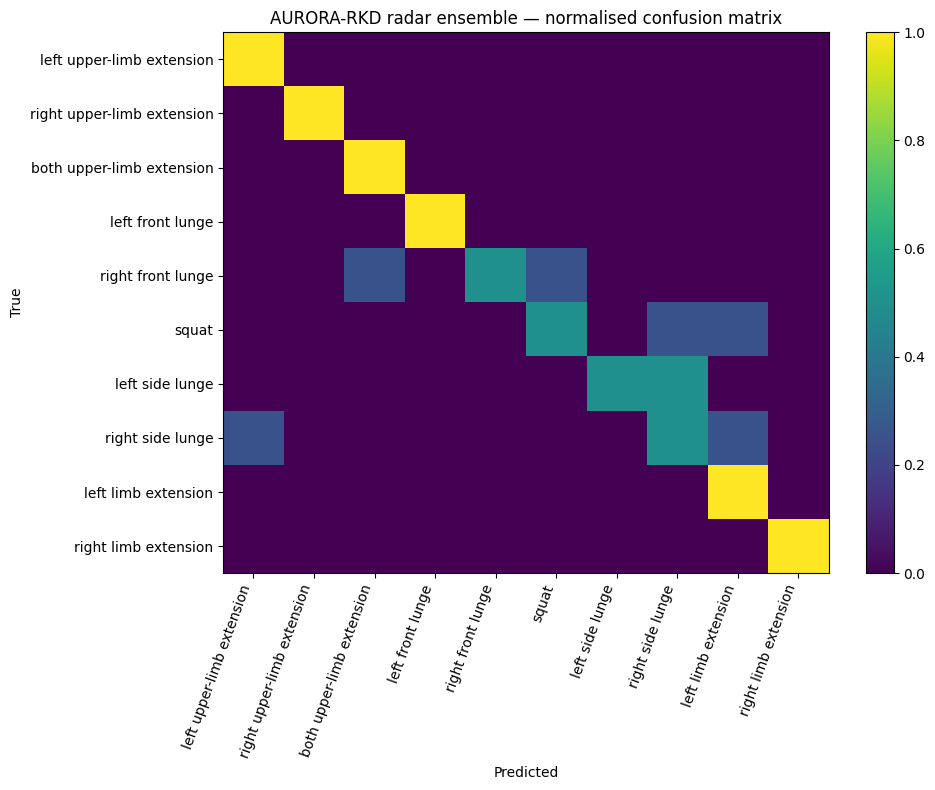

In [41]:
print(
    classification_report(
        ensemble_test_labels,
        ensemble_test_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

confusion = confusion_matrix(
    ensemble_test_labels,
    ensemble_test_predictions,
    labels=list(range(NUM_CLASSES)),
    normalize="true",
)

figure, axis = plt.subplots(figsize=(10, 8))
image = axis.imshow(confusion, vmin=0.0, vmax=1.0, aspect="auto")
axis.set_title("AURORA-RKD radar ensemble — normalised confusion matrix")
axis.set_xlabel("Predicted")
axis.set_ylabel("True")
axis.set_xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=70,
    ha="right",
)
axis.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
figure.colorbar(image, ax=axis)
figure.tight_layout()
figure.savefig(
    Path(cfg.WORK_DIR) / "confusion_aurora_ensemble.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

prediction_frame = pd.DataFrame({
    "sample_id": ensemble_test_sample_ids,
    "subject": ensemble_test_subjects,
    "true_id": ensemble_test_labels,
    "pred_id": ensemble_test_predictions,
    "true_label": [CLASS_NAMES[index] for index in ensemble_test_labels],
    "pred_label": [CLASS_NAMES[index] for index in ensemble_test_predictions],
    "confidence": ensemble_test_probabilities.max(axis=1),
})

for class_id, class_name in enumerate(CLASS_NAMES):
    safe_class_name = re.sub(r"[^a-z0-9]+", "_", class_name.lower()).strip("_")
    prediction_frame[
        f"prob_{class_id:02d}_{safe_class_name}"
    ] = ensemble_test_probabilities[:, class_id]

prediction_frame.to_csv(
    Path(cfg.WORK_DIR) / "predictions_aurora_ensemble.csv",
    index=False,
)

# Novelty positioning

AURORA-RKD's exact integration may be new, but several components have prior art: cross-modal knowledge distillation, adaptive modality weighting, teacher calibration, dynamic KD weighting, corruption-based robustness training, deep ensembles and temperature scaling.

A manuscript should therefore claim novelty in the **joint quality-monotonic teacher, multi-resolution radar candidate library, and validation-optimised radar-only aggregation**, subject to a systematic literature review.

In [42]:
summary = {
    "method": (
        "AURORA-RKD: Adaptive Uncertainty-Calibrated "
        "Reliability-Oriented Robust Aggregated Knowledge Distillation"
    ),
    "configuration": asdict(cfg),
    "data_root": str(DATA_ROOT),
    "subjects": int(manifest["subject"].nunique()),
    "segments": int(len(manifest)),
    "train_subjects": sorted(train_subjects.tolist()),
    "validation_subjects": sorted(val_subjects.tolist()),
    "test_subjects": sorted(test_subjects.tolist()),
    "teacher_temperature": TEACHER_TEMPERATURE,
    "ensemble_temperature": ENSEMBLE_TEMPERATURE,
    "ensemble_selection_mode": SELECTION_MODE,
    "ranked_candidates": ranked_candidate_names,
    "ensemble_weights": ENSEMBLE_WEIGHTS.tolist(),
    "clean_test_results": (
        test_results_df.reset_index().to_dict("records")
    ),
    "gate_summary": gate_summary_df.to_dict("records"),
    "robustness_summary": (
        robustness_summary_df.to_dict("records")
        if not robustness_summary_df.empty
        else []
    ),
    "statistics": statistics_df.to_dict("records"),
    "final_checklist": (
        final_checklist_df
        .replace({np.nan: None})
        .to_dict("records")
    ),
    "journal_cv_run": cfg.RUN_JOURNAL_CV,
}

with open(
    Path(cfg.WORK_DIR) / "experiment_summary.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(summary, handle, indent=2)

archive_path = shutil.make_archive(
    str(Path("/kaggle/working") / "aurora_rkd_mri_outputs"),
    "zip",
    cfg.WORK_DIR,
)

print("Output directory:", cfg.WORK_DIR)
print("Archive:", archive_path)
display(test_results_df.style.format("{:.4f}"))

Output directory: /kaggle/working/aurora_rkd_mri
Archive: /kaggle/working/aurora_rkd_mri_outputs.zip


,accuracy,balanced_accuracy,macro_f1,weighted_f1,nll,brier,ece,temperature
model,,,,,,,,
hybrid_cosine__robust_group_kd__seed2027,0.8000,0.8000,0.8040,0.8040,0.7794,0.3394,0.1141,1.9145
AURORA-RKD radar ensemble,0.8000,0.8000,0.7927,0.7927,0.7131,0.3026,0.0889,2.2027
hybrid_linear__robust_kd__seed2028,0.8000,0.8000,0.7927,0.7927,0.7244,0.2848,0.0931,1.2635
hybrid_cosine__robust_kd__seed2027,0.8000,0.8000,0.7838,0.7838,0.7378,0.3127,0.0904,2.4286
hybrid_linear__robust_kd__seed2027,0.7750,0.7750,0.7729,0.7729,0.7916,0.3338,0.0876,1.3179
hybrid_cosine__robust_kd__seed2028,0.7750,0.7750,0.7571,0.7571,0.7432,0.3243,0.1740,2.5591
hybrid_cosine__robust_group_kd__seed2028,0.7500,0.7500,0.7405,0.7405,0.8776,0.3677,0.1365,1.8529
compact_linear__standard_kd__seed2026,0.7500,0.7500,0.7375,0.7375,0.8061,0.3505,0.1557,1.5595
compact_linear__robust_kd__seed2027,0.7500,0.7500,0.7357,0.7357,0.8689,0.3548,0.0953,1.1784


# Recommended execution

First verify the pipeline with:

```python
cfg.QUICK_RUN = True
cfg.RUN_JOURNAL_CV = False
```

Then run the complete primary experiment:

```python
cfg.QUICK_RUN = False
cfg.RUN_JOURNAL_CV = False
```

Finally, rerun with the publication benchmark enabled:

```python
cfg.QUICK_RUN = False
cfg.RUN_JOURNAL_CV = True
```

The repeated grouped-subject results should be the principal journal evidence. The fixed split should be reported as a direct comparison with the earlier notebooks.